
Cloud_prep script

In [3]:
import os
import pickle
from datetime import datetime
from sentence_transformers import SentenceTransformer

def main():
    print("*" * 50)
    print(" Cloud Layer Simulation - Artifact Generator")
    print("*" * 50)

    #Load semantic model
    model_name = 'all-MiniLM-L6-v2'
    model_path = '/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2'

    print(f"Loading Semantic Model: {model_name}")
    model = SentenceTransformer(model_path, local_files_only=True)
    print("Model loaded successfully")

    #Define job roles and requirements 
    role_id = "Video Conference Solution Engineer"
    CAPABILITY_CHUNKS = [
        "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
        "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
        "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
        "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
        "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
        "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications."
    ]
    
    print(f"Analyze JD and role skills: {role_id}")
    print(f"role:{role_id} ,with a total of {len(CAPABILITY_CHUNKS)} skill blocks")

    #Generate skill vectors
    print(" Generating dense skills vectors using Sentence-BERT")
    skills_vectors = model.encode(CAPABILITY_CHUNKS, show_progress_bar=True)
    print(f" Vector generation successful, dimensions: {skills_vectors.shape}")

    """
    Define decision-making strategies
    # A score >= 0.50 is aligned
    # 0.30 <= score < 0.50 is weakly aligned
    # A score < 0.30 is not matched
    """
    decision_policy = {
        "aligned_threshold": 0.50,        
        "weakly_aligned_threshold": 0.30, 
        "mismatched_label": "Mismatched"  
    }

    #Define metadata
    metadata = {
        "model_identifier": model_name,
        "artifact_version": "v1.0",
        "generation_timestamp": datetime.now().isoformat(),
        "description": "Cloud-generated semantic assets for edge inference (privacy design)"
    }

    #Packaging artifact
    artifact_package = {
        "role_id": role_id,
        "capability_chunks": CAPABILITY_CHUNKS,
        "capability_vectors": skills_vectors,
        "decision_policy": decision_policy,
        "metadata": metadata
    }

    #Serialization distribution.pkl
    artifact_filename = "distribution.pkl"
    print(f"Packaging artifact: '{artifact_filename}'")
    with open(artifact_filename, 'wb') as f:
        pickle.dump(artifact_package, f)

    print(f"\n{'*' * 50}")
    print(f"  Cloud and Artifact initialization complete.")
    print(f"     File path : {os.path.abspath(artifact_filename)}")
    print(f"     Vector Dimension : {skills_vectors.shape}")
    print(f"     Generation time: {metadata['generation_timestamp']}")    
    print(f"{'*' * 50}")


#Auxiliary functions for edge reasoning
def classify_score(score: float, policy: dict) -> str:
    """Similarity scores are divided into three levels based on decision-making strategies"""
    if score >= policy["aligned_threshold"]:
        return "Aligned"
    elif score >= policy["weakly_aligned_threshold"]:
        return "Weakly Aligned"
    else:
        return policy["mismatched_label"]


if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'sentence_transformers'

In [15]:
!python edge_inference_evaluation.py
import os
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix


#Calculate the row cosine similarity between each element in set a and each element in set b.
def calculate_cosine_similarity_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    
    return a_norm @ b_norm.T
 

#Three-level decision rule used
def classify_score(score: float, policy: dict) -> str:
    
    if score >= policy["aligned_threshold"]:
        return "Aligned"
    elif score >= policy["weakly_aligned_threshold"]:
        return "Weakly Aligned"
    else:
        return policy["mismatched_label"]
 
 
def main():
    print("*" * 50)
    print(" Edge Node Simulation - Local Semantic Matching")
    print("*" * 50)
 
    #Load file
    artifact_path = "/kaggle/working/distribution.pkl"
    dataset_path = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
 
    #Loading cloud-generated artifacts
    print(f"Loading cloud-generated artifacts: {artifact_path}")
    with open(artifact_path, "rb") as f:
        artifact = pickle.load(f)
 
    role_id = artifact["role_id"]
    capability_vectors = np.asarray(artifact["capability_vectors"])
    decision_policy = artifact["decision_policy"]
    model_id = artifact["metadata"]["model_identifier"]
    print(f"Artifact loaded. Role: {role_id}, capabilitys: {capability_vectors.shape[0]}")
 
    #Loading semantic models at the edge side
    print(f"Loading edge-side semantic model: {model_id}")
    model_path = '/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2'
    model = SentenceTransformer(model_path, local_files_only=True)
    print("Edge inference model loaded")
 
    #Load the labeled evaluation dataset
    print(f"Loading evaluation dataset: {dataset_path}")
    df = pd.read_csv(dataset_path)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} evaluation items.")
 
    #Code each evaluation item
    print("\n Encoding evaluation items locally on the edge ")
    item_vectors = model.encode(df["item_text"].tolist(), show_progress_bar=True)

    
    #Cosine similarity based on character ability vectors
    print("\n Computing cosine similarity against role capability vectors (max-similarity strategy)")
    sim_matrix = calculate_cosine_similarity_matrix(np.asarray(item_vectors), capability_vectors)
    max_scores = sim_matrix.max(axis=1)
    best_block_idx = sim_matrix.argmax(axis=1)
 
    df["similarity_score"] = max_scores
    df["best_capability_block"] = best_block_idx
    df["predicted_label"] = [classify_score(s, decision_policy) for s in max_scores]
 
    #The prediction results are compared with the manually labeled results.
    print("\n Compare the prediction results with the gold_label data")
    y_true = df["gold_label"]
    y_pred = df["predicted_label"]
 
    labels_order = ["Aligned", "Weakly Aligned", "Mismatched"]
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_order, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels_order)
 
    print(f"\n Overall Accuracy: {acc:.4f}\n")
    print("Per-class metrics:")
    for lbl, p, r, f, s in zip(labels_order, precision, recall, f1, support):
        print(f"  {lbl:15s}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  n={s}")
 
    print(f"\n Confusion Matrix (rows=true, cols=pred), label order : {labels_order}")
    print(cm)
 
    #Retain the execution results for each project for subsequent error analysis and ranking consistency checks
    out_path = "edge_inference_results.csv"
    df.to_csv(out_path, index=False)
    print(f"\n The results have been saved to:{os.path.abspath(out_path)}")
 
 
if __name__ == "__main__":
    main()
 

python3: can't open file '/kaggle/working/edge_inference_evaluation.py': [Errno 2] No such file or directory
  Edge Node Simulation - Local Semantic Matching

[*] Loading cloud-generated artifact: /kaggle/working/distribution.pkl
[✓] Artifact loaded. Role: Video Conference Solution Engineer, capability blocks: 6

[*] Loading edge-side semantic model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[✓] Edge inference model loaded.

[*] Loading evaluation dataset: /kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv
[✓] Loaded 200 evaluation items.

[*] Encoding evaluation items locally on the edge...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[*] Computing cosine similarity against role capability vectors (max-similarity strategy)...

[*] Comparing predictions against gold_label...

Overall Accuracy: 0.2050

Per-class metrics:
  Aligned          P=0.705  R=0.620  F1=0.660  n=50
  Weakly Aligned   P=0.047  R=0.100  F1=0.064  n=50
  Mismatched       P=0.100  R=0.050  F1=0.067  n=100

Confusion Matrix (rows=true, cols=pred), label order = ['Aligned', 'Weakly Aligned', 'Mismatched']
[[31 18  1]
 [ 1  5 44]
 [12 83  5]]

[✓] Full per-item results saved to: /kaggle/working/edge_inference_results.csv


In [16]:
import numpy as np
import pandas as pd
from itertools import product
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
 
LABELS_ORDER = ["Aligned", "Weakly Aligned", "Mismatched"]
 
 
def classify_score(score: float, aligned_th: float, weak_th: float) -> str:
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"
 
 
def main():
    
    #Load the results of each project that has already been generated.
    results_path = "/kaggle/working/edge_inference_results.csv"
 
    print("=" * 50)
    print("  Threshold Calibration - Empirical Analysis")
    print("=" * 50)
 
    df = pd.read_csv(results_path)
    y_true = df["gold_label"]
    scores = df["similarity_score"].values
 
    print("\n Distribution of similarity to gold_label:")
    stats = df.groupby("gold_label")["similarity_score"].describe()
    print(stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]])
 
    print("\n Perform a grid search on the threshold pairs (constraint: `weakly_aligned_threshold` < `aligned_threshold`) to maximize the macro-average F1 score")
    candidates = np.round(np.arange(0.05, 0.95, 0.01), 2)
 
    best = None
    
    for weak_th, aligned_th in product(candidates, candidates):
        if aligned_th <= weak_th:
            continue
        y_pred = [classify_score(s, aligned_th, weak_th) for s in scores]
        acc = accuracy_score(y_true, y_pred)
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=LABELS_ORDER, zero_division=0
        )
        
        macro_f1 = f1.mean()
        if best is None or macro_f1 > best[0]:
            best = (macro_f1, acc, weak_th, aligned_th)
 
    macro_f1, acc, weak_th, aligned_th = best
    print(f"\n Best thresholds found on this labelled set:")
    print(f"     weakly_aligned_threshold = {weak_th}")
    print(f"     aligned_threshold        = {aligned_th}")
    print(f"     -> macro-F1 = {macro_f1:.4f}, accuracy = {acc:.4f}")
    print("     (This is the upper limit of prediction for the current maximum similarity strategy,")
    print("      please consider it as a calibration target, not the final test result)")
 
    y_pred = [classify_score(s, aligned_th, weak_th) for s in scores]
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS_ORDER, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=LABELS_ORDER)
 
    print("\n Per-class metrics at best thresholds:")
    for lbl, p, r, f, s in zip(LABELS_ORDER, precision, recall, f1, support):
        print(f"  {lbl:15s}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  n={s}")
 
    print(f"\n Confusion Matrix (rows=true, cols=pred), label order = {LABELS_ORDER}")
    print(cm)
 
    # Output the accuracy/F1 value at the original placeholder threshold for comparison.
    y_pred_orig = [classify_score(s, 0.50, 0.30) for s in scores]
    acc_orig = accuracy_score(y_true, y_pred_orig)
    _, _, f1_orig, _ = precision_recall_fscore_support(
        y_true, y_pred_orig, labels=LABELS_ORDER, zero_division=0
    )
    print(f"\n [Reference] Original placeholder thresholds (0.30 / 0.50): "
          f"accuracy = {acc_orig:.4f}, macro-F1 = {f1_orig.mean():.4f}")
 
 
if __name__ == "__main__":
    main()

  Threshold Calibration - Empirical Analysis

[*] Similarity score distribution by gold_label:
                count      mean       std       min       25%       50%  \
gold_label                                                                
Aligned          50.0  0.530445  0.107233  0.294612  0.456026  0.545647   
Mismatched      100.0  0.414650  0.077464  0.162372  0.361258  0.412211   
Weakly Aligned   50.0  0.192814  0.094739  0.071688  0.128718  0.166160   

                     75%       max  
gold_label                          
Aligned         0.606996  0.719225  
Mismatched      0.472827  0.606126  
Weakly Aligned  0.224482  0.500318  

[*] Grid-searching threshold pairs (weakly_aligned_threshold < aligned_threshold) to maximise macro-F1...

[OK] Best thresholds found on this labelled set:
     weakly_aligned_threshold = 0.5
     aligned_threshold        = 0.52
     -> macro-F1 = 0.4732, accuracy = 0.5950
     (this is an oracle upper bound for the current max-similarity st

# The `cloud_layer_simulation_v2.py` 

file adds a seventh dimension to the existing six professional competency dimensions: **General Technical Fundamentals and Backend Engineering**, specifically adapted for general migration technology scenarios such as backend development. Based on this update, `distribution_v2.pkl` has been regenerated.

In [17]:
import os
import pickle
from datetime import datetime
from sentence_transformers import SentenceTransformer
def main():
    print("*" * 50)
    print(" Cloud Layer Simulation v2 - Artifact Generator(specialised profile + general technical foundations)")
    # print("  (specialised profile + general technical foundations)")
    print("*" * 50)
    
    # Loading semantic model
    model_name = 'all-MiniLM-L6-v2'
    model_path = '/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2'
    print(f"\n Loading Semantic Model: {model_name}")
    model = SentenceTransformer(model_path, local_files_only=True)
    print(" Model loaded successfully")
    # Define job roles and requirements
    role_id = "Video Conference Solution Engineer"
    CAPABILITY_CHUNKS = [
        "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
        "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
        "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
        "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
        "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
        "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
        "General Technical Foundation & Backend Engineering: Possesses a strong software engineering and distributed-systems foundation that underpins real-time communication platforms and other large-scale backend services. Demonstrates transferable expertise beyond protocol-specific audio/video technologies, enabling effective design, implementation, operation, and evolution of complex service-oriented systems. Proficient in backend application architecture, including service decomposition, modular design, API design principles, microservices and distributed-system patterns, asynchronous and event-driven processing, concurrency control, fault isolation, and resilience engineering.Familiar with core infrastructure and platform technologies commonly used across modern software systems, including Linux server environments, containerization and orchestration concepts, networking fundamentals, databases, caching layers, message queues, service discovery, observability, monitoring, logging, and performance analysis. Capable of designing scalable, secure, and maintainable production systems, with understanding of high availability, horizontal scalability, capacity planning, disaster recovery, deployment automation, CI/CD practices, and operational excellence. Able to identify and troubleshoot performance bottlenecks across application, network, storage, and infrastructure layers. Demonstrates sound engineering practices including software development lifecycle management, testing methodologies, code quality standards, version control, technical documentation, system integration, cross-functional collaboration, and structured problem solving.",
    ]
    
    #Generate skill vectors
    print(f"Analyze JD and role skills: {role_id}")
    print(f"role:{role_id} ,with a total of {len(CAPABILITY_CHUNKS)} skill blocks")
    
    #Generate capability vectors
    print("\n Generating dense capability vectors using Sentence-BERT")
    capability_vectors = model.encode(CAPABILITY_CHUNKS, show_progress_bar=True)
    print(f"Vector generation complete, dimensions: {capability_vectors.shape}")
    
    """
    Define decision-making strategies
    # A score >= 0.50 is aligned
    # 0.30 <= score < 0.50 is weakly aligned
    # A score < 0.30 is not matched
    """
    decision_policy = {
        "aligned_threshold": 0.50,
        "weakly_aligned_threshold": 0.30,
        "mismatched_label": "Mismatched" 
    }
    #Initialize metadata
    metadata = {
        "model_identifier": model_name,
        "artifact_version": "v2.0",
        "generation_timestamp": datetime.now().isoformat(),
        "description": "Cloud-generated semantic assets for Edge inference (Privacy-by-design). "
                        "v2 adds a general technical foundations capability dimension for comparison "
                        "against the v1 specialised-only profile."
    }
    #Packaging artifact
    artifact_package = {
        "role_id": role_id,
        "capability_chunks": CAPABILITY_CHUNKS,
        "capability_vectors": capability_vectors,
        "decision_policy": decision_policy,
        "metadata": metadata
    }
    #Serialization distribution_v2.pkl
    artifact_filename = "distribution_v2.pkl"
    print(f"\n Packaging artifact: '{artifact_filename}'")
    with open(artifact_filename, 'wb') as f:
        pickle.dump(artifact_package, f)
    print(f"\n{'*' * 50}")
    print(f"  Cloud and Artifact initialization complete.")
    print(f"     File path : {os.path.abspath(artifact_filename)}")
    print(f"     Vector Dimension : {capability_vectors.shape}")
    print(f"     Generation time : {metadata['generation_timestamp']}")
    print(f"{'*' * 50}")
    
#Auxiliary functions for edge reasoning
def classify_score(score: float, policy: dict) -> str:
    """Similarity scores are divided into three levels based on decision-making strategies"""
    if score >= policy["aligned_threshold"]:
        return "Aligned"
    elif score >= policy["weakly_aligned_threshold"]:
        return "Weakly Aligned"
    else:
        return policy["mismatched_label"]
if __name__ == "__main__":
    main()

  Cloud Layer Simulation v2 - Artifact Generator
  (specialised profile + general technical foundations)

[*] Loading Semantic Model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] The local model was loaded successfully.

[*] Parse the JD and perform requirement chunking, position: Video Conference Solution Engineer
    Totally 7 Capability Dimension Block.

[*] Generating dense capability vectors using Sentence-BERT...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[OK] Vector generation complete, dimensions: (7, 384)

[*] Packaging semantic assets is lightweight artifact: 'distribution_v2.pkl'...

  Cloud Ready! Artifact is ready.
     File path : /kaggle/working/distribution_v2.pkl
     Vector Dimension : (7, 384)
     Generation time : 2026-07-27T13:22:22.133211


edge_inference_evaluation_v2.py: Reads distribution_v2.pkl, processes the same set of 200 data records, and outputs edge_inference_results_v2.csv.

In [18]:
import os
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix


def cosine_similarity_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    
    #Calculate the row cosine similarity between each element in set a and each element in set b.
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    return a_norm @ b_norm.T


#Three-level decision rule used
def classify_score(score: float, policy: dict) -> str:
    
    if score >= policy["aligned_threshold"]:
        return "Aligned"
    elif score >= policy["weakly_aligned_threshold"]:
        return "Weakly Aligned"
    else:
        return policy["mismatched_label"]


def main():
    print("*" * 50)
    print("  Edge Node Simulation v2 - Local Semantic Matching")
    print("  (using distribution_v2.pkl: specialised + general foundations)")
    print("*" * 50)

    #Load file
    artifact_path = "/kaggle/working/distribution_v2.pkl"
    dataset_path = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"

    #Loading cloud-generated artifacts
    print(f"\n Loading cloud-generated artifacts: {artifact_path}")
    with open(artifact_path, "rb") as f:
        artifact = pickle.load(f)

    role_id = artifact["role_id"]
    capability_vectors = np.asarray(artifact["capability_vectors"])
    decision_policy = artifact["decision_policy"]
    model_id = artifact["metadata"]["model_identifier"]
    print(f" Artifact loaded. Role: {role_id}, capabilitys: {capability_vectors.shape[0]}")

    #Loading semantic models at the edge side(must match the cloud model)
    print(f"\n Loading edge-side semantic model: {model_id}")
    model_path = '/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2'
    model = SentenceTransformer(model_path, local_files_only=True)
    print("Edge inference model loaded")

    #Load the annotated evaluation dataset
    print(f"\n Loading evaluation dataset: {dataset_path}")
    df = pd.read_csv(dataset_path)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} evaluation items")

    #Encode every evaluation item locally at the edge
    print("\n Encoding evaluation items locally on the edge")
    item_vectors = model.encode(df["item_text"].tolist(), show_progress_bar=True)

    #Cosine similarity based on character ability vectors
    print("\n Computing cosine similarity against role capability vectors (max-similarity strategy)")
    sim_matrix = cosine_similarity_matrix(np.asarray(item_vectors), capability_vectors)
    max_scores = sim_matrix.max(axis=1)
    best_block_idx = sim_matrix.argmax(axis=1)

    df["similarity_score"] = max_scores
    df["best_capability_block"] = best_block_idx
    df["predicted_label"] = [classify_score(s, decision_policy) for s in max_scores]

    #The prediction results are compared with the manually labeled results.
    print("\n Compare the prediction results with the gold_label data")
    y_true = df["gold_label"]
    y_pred = df["predicted_label"]

    labels_order = ["Aligned", "Weakly Aligned", "Mismatched"]
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_order, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels_order)

    print(f"\n Overall Accuracy:{acc:.4f}\n")
    print("Per-class metrics:")
    for lbl, p, r, f, s in zip(labels_order, precision, recall, f1, support):
        print(f"  {lbl:15s}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  n={s}")

    print(f"\n Confusion Matrix (rows=true, cols=pred), label order = {labels_order}")
    print(cm)

    #Retain the execution results for each project for subsequent error analysis and ranking consistency checks
    out_path = "edge_inference_results_v2.csv"
    df.to_csv(out_path, index=False)
    print(f"\n Full per-item results saved to: {os.path.abspath(out_path)}")


if __name__ == "__main__":
    main()

  Edge Node Simulation v2 - Local Semantic Matching
  (using distribution_v2.pkl: specialised + general foundations)

[*] Loading cloud-generated artifact: /kaggle/working/distribution_v2.pkl
[OK] Artifact loaded. Role: Video Conference Solution Engineer, capability blocks: 7

[*] Loading edge-side semantic model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Edge inference model loaded.

[*] Loading evaluation dataset: /kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv
[OK] Loaded 200 evaluation items.

[*] Encoding evaluation items locally on the edge...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[*] Computing cosine similarity against role capability vectors (max-similarity strategy)...

[*] Comparing predictions against gold_label...

Overall Accuracy: 0.2350

Per-class metrics:
  Aligned          P=0.705  R=0.620  F1=0.660  n=50
  Weakly Aligned   P=0.098  R=0.220  F1=0.136  n=50
  Mismatched       P=0.114  R=0.050  F1=0.069  n=100

Confusion Matrix (rows=true, cols=pred), label order = ['Aligned', 'Weakly Aligned', 'Mismatched']
[[31 18  1]
 [ 1 11 38]
 [12 83  5]]

[OK] Full per-item results saved to: /kaggle/working/edge_inference_results_v2.csv


In [19]:
# threshold_calibration_v2.py: Conducts the same threshold calibration analysis on the v2 results.

import numpy as np
import pandas as pd
from itertools import product
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

LABELS_ORDER = ["Aligned", "Weakly Aligned", "Mismatched"]


def classify_score(score: float, aligned_th: float, weak_th: float) -> str:
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"


def main():
    
    #Load file
    results_path = "/kaggle/working/edge_inference_results_v2.csv"

    print("*" * 50)
    print("  Threshold Calibration v2 - Empirical Analysis")
    print("  (specialised + general technical foundations profile)")
    print("*" * 50)

    df = pd.read_csv(results_path)
    y_true = df["gold_label"]
    scores = df["similarity_score"].values

    print("\n Distribution of similarity to gold_label:")
    stats = df.groupby("gold_label")["similarity_score"].describe()
    print(stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]])

    print("\n Perform a grid search on the threshold pairs (constraint: `weakly_aligned_threshold` < `aligned_threshold`) to maximize the macro-average F1 score")
    candidates = np.round(np.arange(0.05, 0.95, 0.01), 2)

    best = None
    for weak_th, aligned_th in product(candidates, candidates):
        if aligned_th <= weak_th:
            continue
        y_pred = [classify_score(s, aligned_th, weak_th) for s in scores]
        acc = accuracy_score(y_true, y_pred)
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=LABELS_ORDER, zero_division=0
        )
        macro_f1 = f1.mean()
        if best is None or macro_f1 > best[0]:
            best = (macro_f1, acc, weak_th, aligned_th)

    macro_f1, acc, weak_th, aligned_th = best
    print(f"\n Best thresholds found on this labelled set:")
    print(f"     weakly_aligned_threshold = {weak_th}")
    print(f"     aligned_threshold        = {aligned_th}")
    print(f"     -> macro-F1 = {macro_f1:.4f}, accuracy = {acc:.4f}")
    print("     (this is an oracle upper bound for the current max-similarity strategy.")
    print("      please consider it as a calibration target, not the final test result)")
    
    y_pred = [classify_score(s, aligned_th, weak_th) for s in scores]
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS_ORDER, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=LABELS_ORDER)

    print("\n Per-class metrics at best thresholds:")
    for lbl, p, r, f, s in zip(LABELS_ORDER, precision, recall, f1, support):
        print(f"  {lbl:15s}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  n={s}")

    print(f"\n Confusion Matrix (rows=true, cols=pred), label order = {LABELS_ORDER}")
    print(cm)

    y_pred_orig = [classify_score(s, 0.50, 0.30) for s in scores]
    acc_orig = accuracy_score(y_true, y_pred_orig)
    _, _, f1_orig, _ = precision_recall_fscore_support(
        y_true, y_pred_orig, labels=LABELS_ORDER, zero_division=0
    )
    print(f"\n [Reference] Original placeholder thresholds (0.30 / 0.50): "
          f"accuracy = {acc_orig:.4f}, macro-F1 = {f1_orig.mean():.4f}")


if __name__ == "__main__":
    main()

  Threshold Calibration v2 - Empirical Analysis
  (specialised + general technical foundations profile)

[*] Similarity score distribution by gold_label:
                count      mean       std       min       25%       50%  \
gold_label                                                                
Aligned          50.0  0.530445  0.107233  0.294612  0.456026  0.545647   
Mismatched      100.0  0.415249  0.076427  0.180162  0.361258  0.412211   
Weakly Aligned   50.0  0.268109  0.097301  0.072772  0.212052  0.254423   

                     75%       max  
gold_label                          
Aligned         0.606996  0.719225  
Mismatched      0.472827  0.606126  
Weakly Aligned  0.299061  0.518281  

[*] Grid-searching threshold pairs (weakly_aligned_threshold < aligned_threshold) to maximise macro-F1...

[OK] Best thresholds found on this labelled set:
     weakly_aligned_threshold = 0.49
     aligned_threshold        = 0.52
     -> macro-F1 = 0.4821, accuracy = 0.5900
     (thi

## Hybrid Semantic + Keyword Fusion

**Motivation**: Independent semantic (SBERT cosine, taking the maximum similarity of capability blocks) and keyword (TF-IDF cosine, the same maximum similarity strategy) pipeline performances are similar, with keyword baseline slightly better; neither can distinguish weak alignment/mismatch categories. Dense and sparse retrieval capture some non-overlapping relevant signals, and the fusion score has the potential to outperform the single model, referencing ranking fusion methods in the IR field (CombSUM/CombMNZ).

**Implementation**: Calculate semantic and keyword scores for each sample, normalizing to `[0,1]` using min-max; weighted fusion: `hybrid = alpha * semantic_norm + (1-alpha) * keyword_norm`. Grid search `alpha` and double threshold maximization of macro-F1; simultaneously output `alpha=1` pure semantic results and `alpha=0` pure keyword results for easy horizontal comparison.

**Performance Description:** Threshold grid search is implemented using NumPy (`np.bincount` calculates the confusion matrix), avoiding the overhead of sklearn loop calls (20,000+ parameter combinations), completing calculations in seconds, and the results are perfectly aligned with sklearn; sklearn metric functions are only called in the final output report stage.

In [20]:
import os
import pickle
import time
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_similarity
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

LABELS_ORDER = ["Aligned", "Weakly Aligned", "Mismatched"]
LABEL_TO_CODE = {lbl: i for i, lbl in enumerate(LABELS_ORDER)}

def cosine_similarity_matrix(a, b):
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    return a_norm @ b_norm.T

def min_max_normalise(x):
    lo, hi = x.min(), x.max()
    if hi - lo < 1e-12:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)

def macro_f1_and_acc(pred_code, true_code):
    idx = true_code * 3 + pred_code
    cm = np.bincount(idx, minlength=9).reshape(3, 3)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    pred_totals = cm.sum(axis=0)
    precision = np.where(pred_totals > 0, tp / np.maximum(pred_totals, 1), 0.0)
    recall = np.where(support > 0, tp / np.maximum(support, 1), 0.0)
    denom = precision + recall
    f1 = np.where(denom > 0, 2 * precision * recall / np.maximum(denom, 1e-12), 0.0)
    acc = tp.sum() / true_code.shape[0]
    return f1.mean(), acc

def best_thresholds_for(scores, true_code, th_candidates):
    best = None
    for weak_th in th_candidates:
        below_weak = scores < weak_th
        for aligned_th in th_candidates:
            if aligned_th <= weak_th:
                continue
            above_aligned = scores >= aligned_th
            pred_code = np.where(above_aligned, 0, np.where(~below_weak, 1, 2))
            macro_f1, acc = macro_f1_and_acc(pred_code, true_code)
            if best is None or macro_f1 > best[0]:
                best = (macro_f1, acc, weak_th, aligned_th)
    return best

def classify_score(score, aligned_th, weak_th):
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"

def report(name, scores, y_true, true_code, th_candidates):
    macro_f1, acc, weak_th, aligned_th = best_thresholds_for(scores, true_code, th_candidates)
    y_pred = [classify_score(s, aligned_th, weak_th) for s in scores]
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS_ORDER, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=LABELS_ORDER)
    print(f"\n--- {name} ---")
    print(f"  best thresholds: weakly_aligned={weak_th:.3f}, aligned={aligned_th:.3f}")
    print(f"  macro-F1={macro_f1:.4f}, accuracy={acc:.4f}")
    for lbl, p, r, f, s in zip(LABELS_ORDER, precision, recall, f1, support):
        print(f"    {lbl:15s}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  n={s}")
    print(f"  confusion matrix (rows=true, cols=pred), order={LABELS_ORDER}")
    print(" ", str(cm).replace("\n", "\n  "))
    return macro_f1, acc, weak_th, aligned_th

print("The function has been successfully defined")

[OK] Step 1 done: helper functions defined.


In [21]:
artifact_path = "/kaggle/working/distribution.pkl"
model_path = '/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2'

print(f"Load artifact: {artifact_path}")
with open(artifact_path, "rb") as f:
    artifact = pickle.load(f)
capability_vectors = np.asarray(artifact["capability_vectors"])
capability_chunks = artifact["capability_chunks"]
print(f"Artifact loaded. Capability blocks: {capability_vectors.shape[0]}")

print(f"Loading semantic model: {artifact['metadata']['model_identifier']}")
model = SentenceTransformer(model_path, local_files_only=True)
print("Model loaded")

[*] Loading artifact: /kaggle/working/distribution.pkl
[OK] Artifact loaded. Capability blocks: 6
[*] Loading semantic model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Model loaded.


In [22]:
dataset_path = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
df = pd.read_csv(dataset_path)
df.columns = [c.strip() for c in df.columns]
print(f"Loaded {len(df)} evaluation items")
df.head()

[OK] Loaded 200 evaluation items.


,item_id,target_role,item_text,gold_label
0,Q_001,Product Manager,When defining the PRD for a new Video Conferen...,Mismatched
1,Q_002,Product Manager,A large enterprise customer requests multiple ...,Mismatched
2,Q_003,Product Manager,How would you design the User experience for a...,Mismatched
3,Q_004,Product Manager,What product metrics would you use to measure ...,Mismatched
4,Q_005,Product Manager,If customer feedback suggests that Users perce...,Mismatched


In [23]:
print("The evaluation items are coded and the maximum semantic similarity is calculated")

item_vectors = np.asarray(model.encode(df["item_text"].tolist(), show_progress_bar=True))
sem_sim = cosine_similarity_matrix(item_vectors, capability_vectors)
semantic_score = sem_sim.max(axis=1)
df["semantic_score"] = semantic_score
print("semantic_score computed. sample:", semantic_score[:5])

[*] Encoding evaluation items and computing semantic max-similarity...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[OK] semantic_score computed. sample: [0.43375477 0.40714186 0.56962204 0.42611358 0.35391372]


In [24]:
print("Calculate the maximum similarity of keywords using TF-IDF")

vectorizer = TfidfVectorizer(stop_words="english")
corpus = list(capability_chunks) + df["item_text"].tolist()

X = vectorizer.fit_transform(corpus)
chunk_tfidf = X[: len(capability_chunks)]
item_tfidf = X[len(capability_chunks):]

kw_sim = sk_cosine_similarity(item_tfidf, chunk_tfidf)
keyword_score = kw_sim.max(axis=1)
df["keyword_score"] = keyword_score

print("keyword_score computed. sample:", keyword_score[:5])

[*] Computing TF-IDF keyword max-similarity...
[OK] keyword_score computed. sample: [0.03754913 0.06716214 0.10592216 0.04107017 0.02840913]


In [25]:
semantic_norm = min_max_normalise(semantic_score)
keyword_norm = min_max_normalise(keyword_score)

y_true = df["gold_label"]
true_code = y_true.map(LABEL_TO_CODE).to_numpy()
th_candidates = np.round(np.arange(0.0, 1.01, 0.02), 3)

report("Semantic only", semantic_norm, y_true, true_code, th_candidates)
report("Keyword only ", keyword_norm, y_true, true_code, th_candidates)


--- Semantic only (normalised) ---
  best thresholds: weakly_aligned=0.660, aligned=0.700
  macro-F1=0.4713, accuracy=0.5900
    Aligned          P=0.833  R=0.600  F1=0.698  n=50
    Weakly Aligned   P=0.111  R=0.020  F1=0.034  n=50
    Mismatched       P=0.561  R=0.870  F1=0.682  n=100
  confusion matrix (rows=true, cols=pred), order=['Aligned', 'Weakly Aligned', 'Mismatched']
  [[30  1 19]
   [ 0  1 49]
   [ 6  7 87]]

--- Keyword only (normalised) ---
  best thresholds: weakly_aligned=0.260, aligned=0.280
  macro-F1=0.5130, accuracy=0.6400
    Aligned          P=0.810  R=0.680  F1=0.739  n=50
    Weakly Aligned   P=0.400  R=0.040  F1=0.073  n=50
    Mismatched       P=0.601  R=0.920  F1=0.727  n=100
  confusion matrix (rows=true, cols=pred), order=['Aligned', 'Weakly Aligned', 'Mismatched']
  [[34  2 14]
   [ 1  2 47]
   [ 7  1 92]]


(np.float64(0.5130434782608696),
 np.float64(0.64),
 np.float64(0.26),
 np.float64(0.28))

In [26]:
print("Grid search fusion weight alpha")
t0 = time.time()
alphas = np.round(np.arange(0.0, 1.01, 0.05), 2)
best_overall = None
for alpha in alphas:
    hybrid_score = alpha * semantic_norm + (1 - alpha) * keyword_norm
    macro_f1, acc, weak_th, aligned_th = best_thresholds_for(hybrid_score, true_code, th_candidates)
    print(f"    alpha={alpha:.2f}  macro-F1={macro_f1:.4f}  accuracy={acc:.4f}")
    if best_overall is None or macro_f1 > best_overall[0]:
        best_overall = (macro_f1, acc, weak_th, aligned_th, alpha)
print(f" Grid search finished in {time.time() - t0:.1f}s")
print("best overall:", best_overall)

[*] Grid-searching fusion weight alpha...
    alpha=0.00  macro-F1=0.5130  accuracy=0.6400
    alpha=0.05  macro-F1=0.5083  accuracy=0.6300
    alpha=0.10  macro-F1=0.5184  accuracy=0.6450
    alpha=0.15  macro-F1=0.5096  accuracy=0.6350
    alpha=0.20  macro-F1=0.5232  accuracy=0.6450
    alpha=0.25  macro-F1=0.5160  accuracy=0.6100
    alpha=0.30  macro-F1=0.5216  accuracy=0.6300
    alpha=0.35  macro-F1=0.5190  accuracy=0.6150
    alpha=0.40  macro-F1=0.5213  accuracy=0.6200
    alpha=0.45  macro-F1=0.5003  accuracy=0.6250
    alpha=0.50  macro-F1=0.5027  accuracy=0.6250
    alpha=0.55  macro-F1=0.4924  accuracy=0.6200
    alpha=0.60  macro-F1=0.4842  accuracy=0.6000
    alpha=0.65  macro-F1=0.4862  accuracy=0.6150
    alpha=0.70  macro-F1=0.4850  accuracy=0.6100
    alpha=0.75  macro-F1=0.4855  accuracy=0.6100
    alpha=0.80  macro-F1=0.4836  accuracy=0.6050
    alpha=0.85  macro-F1=0.4739  accuracy=0.6000
    alpha=0.90  macro-F1=0.4717  accuracy=0.6000
    alpha=0.95  macro-F1=0.

In [27]:
macro_f1, acc, weak_th, aligned_th, alpha = best_overall
hybrid_score = alpha * semantic_norm + (1 - alpha) * keyword_norm
df["hybrid_score"] = hybrid_score
df["predicted_label"] = [classify_score(s, aligned_th, weak_th) for s in hybrid_score]

print(f" Best hybrid configuration: alpha={alpha}")
print(f"     thresholds: weakly_aligned={weak_th:.3f}, aligned={aligned_th:.3f}")
print(f"     macro-F1={macro_f1:.4f}, accuracy={acc:.4f}")

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, df["predicted_label"], labels=LABELS_ORDER, zero_division=0
)
cm = confusion_matrix(y_true, df["predicted_label"], labels=LABELS_ORDER)

print("\n Indicators for each category under optimal hybrid configuration:")
for lbl, p, r, f, s in zip(LABELS_ORDER, precision, recall, f1, support):
    print(f"  {lbl:15s}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  n={s}")
print(f"\n Confusion Matrix (rows=true, cols=pred), label order = {LABELS_ORDER}")
print(cm)

out_path = "hybrid_matching_results.csv"
df.to_csv(out_path, index=False)
print(f" Save to: {os.path.abspath(out_path)}")

[OK] Best hybrid configuration: alpha=0.2
     thresholds: weakly_aligned=0.300, aligned=0.320
     macro-F1=0.5232, accuracy=0.6450

Per-class metrics at best hybrid configuration:
  Aligned          P=0.780  R=0.780  F1=0.780  n=50
  Weakly Aligned   P=0.500  R=0.040  F1=0.074  n=50
  Mismatched       P=0.603  R=0.880  F1=0.715  n=100

Confusion Matrix (rows=true, cols=pred), label order = ['Aligned', 'Weakly Aligned', 'Mismatched']
[[39  0 11]
 [ 1  2 47]
 [10  2 88]]
[OK] Saved: /kaggle/working/hybrid_matching_results.csv


Curve showing the relationship between CPU allocation and latency sensitivity at the sandbox edge.
Aggregated average, minimum, and maximum end-to-end latency for each path, grouped by CPU level.

   cpu_cores          mean         min         max   n
0       0.10  41457.013880  37697.0707  54396.2640  20
1       0.25   6829.789775   3098.9904  12099.2354  20
2       0.50   1126.871445    403.8653   2954.6953  20
3       0.75   2094.330795    898.6677   3302.6738  20
4       1.00    349.989700    103.8091    598.4905  20
5       1.50    148.462265     79.3817    299.0370  20
6       2.00    108.259055     83.5721    197.7257  20
7       3.00     71.114650     14.7105    179.3972  20
8       4.00     61.963810     15.2366    176.4864  20
9       6.00     59.690480     14.8780    118.7625  20

[OK] Saved:
     cpu_sensitivity_curve.png  (600dpi raster -- use in Word/PowerPoint)
     cpu_sensitivity_curve.pdf  (vector -- use in LaTeX with \includegraphics)
     cpu_sensitivity_curve.svg  (vector, editable)


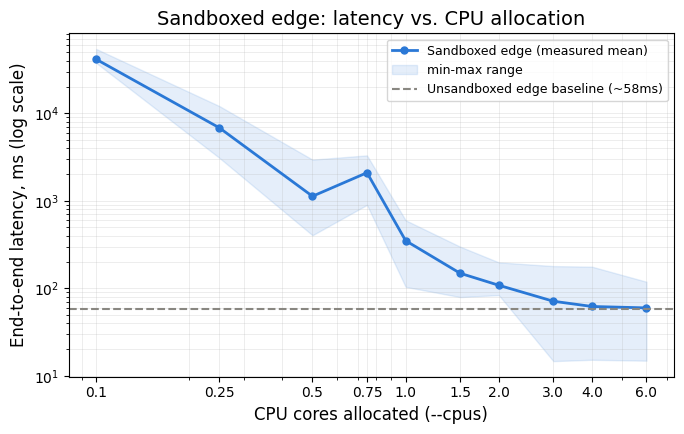

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "/kaggle/input/datasets/kehuang5/cpu-sensitivity-results/cpu_sensitivity_results.csv"


# The unsandboxed-edge baseline mean latency (ms)
UNSANDBOXED_BASELINE_MS = 58

# Output file base name, save as .png, .pdf, and .svg formats.
OUTPUT_BASENAME = "cpu_sensitivity_curve"  

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "svg.fonttype": "none",   
    "pdf.fonttype": 42,
})


def main():
    df = pd.read_csv(CSV_PATH)
    df.columns = [c.strip() for c in df.columns]

    # Delete all temporary test runs and force the remaining labels to numerical CPU core values
    df = df[df["cpu_label"].apply(lambda x: str(x).replace(".", "", 1).isdigit())].copy()
    df["cpu_cores"] = df["cpu_label"].astype(float)

    summary = (
        df.groupby("cpu_cores")["end_to_end_ms"]
        .agg(mean="mean", min="min", max="max", n="count")
        .reset_index()
        .sort_values("cpu_cores")
    )
    
    print(summary)

    fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.plot(
        summary["cpu_cores"], summary["mean"],
        marker="o", markersize=5, linewidth=2,
        color="#2a78d6", label="Sandboxed edge (measured mean)",
    )
    ax.fill_between(
        summary["cpu_cores"], summary["min"], summary["max"],
        color="#2a78d6", alpha=0.12, label="min-max range",
    )
    
    ax.axhline(
        UNSANDBOXED_BASELINE_MS, color="#898781", linestyle="--", linewidth=1.5,
        label=f"Unsandboxed edge baseline (~{UNSANDBOXED_BASELINE_MS}ms)",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("CPU cores allocated (--cpus)")
    ax.set_ylabel("End-to-end latency, ms (log scale)")
    ax.set_title("Sandboxed edge: latency vs. CPU allocation")
    ax.set_xticks(summary["cpu_cores"])
    ax.set_xticklabels([str(c) for c in summary["cpu_cores"]])
    ax.grid(True, which="both", linestyle="-", linewidth=0.4, alpha=0.4)
    ax.legend(fontsize=9, loc="upper right")

    fig.tight_layout()

    png_path = f"{OUTPUT_BASENAME}.png"
    pdf_path = f"{OUTPUT_BASENAME}.pdf"
    svg_path = f"{OUTPUT_BASENAME}.svg"

    fig.savefig(png_path, dpi=600, bbox_inches="tight")    
    fig.savefig(pdf_path, bbox_inches="tight")             
    fig.savefig(svg_path, bbox_inches="tight")             

    print(f"\n Saved:")
    print(f"     {png_path}  (600dpi raster -- use in Word/PowerPoint)")
    print(f"     {pdf_path}  (vector -- use in LaTeX with \\includegraphics)")
    print(f"     {svg_path}  (vector, editable)")


if __name__ == "__main__":
    main()

In [29]:
import os
for dirname, _, filenames in os.walk('/kaggle/working'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/working/cpu_sensitivity_curve.png
/kaggle/working/edge_inference_results_v2.csv
/kaggle/working/distribution.pkl
/kaggle/working/distribution_v2.pkl
/kaggle/working/cpu_sensitivity_curve.pdf
/kaggle/working/cpu_sensitivity_curve.svg
/kaggle/working/edge_inference_results.csv
/kaggle/working/hybrid_matching_results.csv
/kaggle/working/.virtual_documents/__notebook_source__.ipynb


## Ranking Consistency Analysis

Threshold-based metrics (accuracy, F1 score, confusion matrix) only reflect the classification results after threshold segmentation. This script investigates the complementarity problem: disregarding the threshold, does the continuous similarity score output by the model maintain consistency with the relative ranking of manually labeled data? The expected order is: `Aligned > Weakly Aligned > Mismatched`.

**Method**: Map the true labels to ordered relevance levels: `Aligned=3`, `Weakly Aligned=2`, `Mismatched=1`; calculate the Spearman rank correlation coefficient between each model's original score and the label at that level, using Kendall's tau as a robustness check. Models with excellent ranking consistency will still exhibit a high positive correlation even with less-than-ideal threshold selection.

**Execution Instructions:** Based on `hybrid_matching_results.csv` (generated by `hybrid_matching.py`), the file already contains `semantic_score`, `keyword_score`, `hybrid_score`, and `gold_label`. A single script run can complete the evaluation of all three methods. Execute on Kaggle.

In [30]:
import pandas as pd
from scipy.stats import spearmanr, kendalltau

#Load Kaggle file
RESULTS_PATH = "/kaggle/working/hybrid_matching_results.csv"

GOLD_RANK = {"Aligned": 3, "Weakly Aligned": 2, "Mismatched": 1}

SCORE_COLUMNS = {
    "Semantic (SBERT)": "semantic_score",
    "Keyword (TF-IDF)": "keyword_score",
    "Hybrid (alpha=0.2)": "hybrid_score",
}


def analyse(df: pd.DataFrame, score_columns: dict):
    df = df.copy()
    df["gold_rank"] = df["gold_label"].map(GOLD_RANK)
    if df["gold_rank"].isna().any():
        bad = df.loc[df["gold_rank"].isna(), "gold_label"].unique()
        raise ValueError(f"Unrecognised gold_label values found: {bad}")

    print(f"{'Method':<22} {'Spearman rho':>13} {'p-value':>10} {'Kendall tau':>13} {'p-value':>10}")
    print("-" * 70)
    results = []
    for name, col in score_columns.items():
        if col not in df.columns:
            print(f"{name:<22}  (column '{col}' not found in this file -- skipped)")
            continue
        rho, p_rho = spearmanr(df[col], df["gold_rank"])
        tau, p_tau = kendalltau(df[col], df["gold_rank"])
        print(f"{name:<22} {rho:>13.4f} {p_rho:>10.2e} {tau:>13.4f} {p_tau:>10.2e}")
        results.append({"method": name, "spearman_rho": rho, "spearman_p": p_rho,
                         "kendall_tau": tau, "kendall_p": p_tau})

    return pd.DataFrame(results)


def main():
    print("*" * 70)
    print(" Ranking-Consistency Analysis")
    print("*" * 70)
    print(f"\n Loading {RESULTS_PATH}")
    df = pd.read_csv(RESULTS_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items\n")

    results = analyse(df, SCORE_COLUMNS)

    out_path = "ranking_consistency_results.csv"
    results.to_csv(out_path, index=False)
    print(f"\n Saved summary table to {out_path}")


if __name__ == "__main__":
    main()

  Ranking-Consistency Analysis (Spearman / Kendall vs. gold ranking)

[*] Loading /kaggle/working/hybrid_matching_results.csv ...
[OK] Loaded 200 items.

Method                  Spearman rho    p-value   Kendall tau    p-value
------------------------------------------------------------------------
Semantic (SBERT)              0.1371   5.30e-02        0.0645   2.41e-01
Keyword (TF-IDF)              0.3638   1.18e-07        0.2490   6.16e-06
Hybrid (alpha=0.2)            0.3019   1.40e-05        0.1873   6.70e-04

[OK] Saved summary table to ranking_consistency_results.csv

Interpretation guide:
  rho/tau close to +1  -> score order strongly agrees with Aligned > Weakly Aligned > Mismatched
  rho/tau close to  0  -> score order is essentially unrelated to the gold relevance ranking
  rho/tau close to -1  -> score order is INVERTED relative to the gold ranking
  p-value < 0.05       -> correlation is unlikely to be due to chance at this sample size


In [31]:
df = pd.read_csv("/kaggle/working/edge_inference_results.csv")
df.columns = [c.strip() for c in df.columns]
analyse(df, {"Semantic v1": "similarity_score"})

Method                  Spearman rho    p-value   Kendall tau    p-value
------------------------------------------------------------------------
Semantic v1                   0.1371   5.30e-02        0.0645   2.41e-01


,method,spearman_rho,spearman_p,kendall_tau,kendall_p
0,Semantic v1,0.137051,0.052968,0.064546,0.241103


In [32]:
df2 = pd.read_csv("/kaggle/working/edge_inference_results_v2.csv")
df2.columns = [c.strip() for c in df2.columns]
analyse(df2, {"Semantic v2": "similarity_score"})

Method                  Spearman rho    p-value   Kendall tau    p-value
------------------------------------------------------------------------
Semantic v2                   0.1732   1.42e-02        0.0999   6.96e-02


,method,spearman_rho,spearman_p,kendall_tau,kendall_p
0,Semantic v2,0.173181,0.014192,0.099925,0.069559


In [33]:

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]


def classify(score, weak_th, aligned_th):
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"


def grid_search_best(df, score_col):
    best = None
    for weak_th in np.arange(0.05, 0.96, 0.02):
        for aligned_th in np.arange(weak_th, 0.96, 0.02):
            preds = df[score_col].apply(lambda s: classify(s, weak_th, aligned_th))
            f1 = f1_score(df["gold_label"], preds, labels=LABELS, average="macro", zero_division=0)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th, preds)
    return best


print("*" * 70)
print("Semantic v1")
print("*" * 70)
df1 = pd.read_csv("/kaggle/working/edge_inference_results.csv")
df1.columns = [c.strip() for c in df1.columns]
f1_1, w1, a1, pred1 = grid_search_best(df1, "similarity_score")
cm1 = confusion_matrix(df1["gold_label"], pred1, labels=LABELS)
acc1 = np.trace(cm1) / len(df1)
print(f"best thresholds: weak={w1:.2f}, aligned={a1:.2f}  macro-F1={f1_1:.4f}  accuracy={acc1:.4f}")
print("labels order:", LABELS)
print(cm1)

print()
print("*" * 70)
print("Semantic v2")
print("*" * 70)

df2 = pd.read_csv("/kaggle/working/edge_inference_results_v2.csv")
df2.columns = [c.strip() for c in df2.columns]
f1_2, w2, a2, pred2 = grid_search_best(df2, "similarity_score")
cm2 = confusion_matrix(df2["gold_label"], pred2, labels=LABELS)
acc2 = np.trace(cm2) / len(df2)
print(f"best thresholds: weak={w2:.2f}, aligned={a2:.2f}  macro-F1={f1_2:.4f}  accuracy={acc2:.4f}")
print("labels order:", LABELS)
print(cm2)

print()
print("*" * 70)
print("Hybrid (alpha=0.2, already-calibrated predicted_label column)")
print("*" * 70)

dfh = pd.read_csv("/kaggle/working/hybrid_matching_results.csv")
dfh.columns = [c.strip() for c in dfh.columns]
cmh = confusion_matrix(dfh["gold_label"], dfh["predicted_label"], labels=LABELS)
acch = np.trace(cmh) / len(dfh)
print(f"accuracy={acch:.4f}")
print("labels order:", LABELS)
print(cmh)

for name, cm in [("semantic_v1", cm1), ("semantic_v2", cm2), ("hybrid", cmh)]:
    pd.DataFrame(cm, index=LABELS, columns=LABELS).to_csv(f"confusion_matrix_{name}.csv")
print()
print("Saved 3 CSVs")

Semantic v1
best thresholds: weak=0.53, aligned=0.53  macro-F1=0.4726  accuracy=0.6250
labels order: ['Aligned', 'Weakly Aligned', 'Mismatched']
[[29  0 21]
 [ 0  0 50]
 [ 4  0 96]]

Semantic v2
best thresholds: weak=0.49, aligned=0.53  macro-F1=0.4816  accuracy=0.5850
labels order: ['Aligned', 'Weakly Aligned', 'Mismatched']
[[29  4 17]
 [ 0  2 48]
 [ 4 10 86]]

Hybrid (alpha=0.2, already-calibrated predicted_label column)
accuracy=0.6450
labels order: ['Aligned', 'Weakly Aligned', 'Mismatched']
[[39  0 11]
 [ 1  2 47]
 [10  2 88]]

Saved 3 CSVs. Paste the full printed output above back into the chat.


# Diagnostic A: Model Quality Testing

The dataset and v1 (6-block) capability configuration remain completely unchanged. Only the embedding model is replaced, from `all-MiniLM-L6-v2` to the stronger contemporary open-source retrieval embedding model `BAAI/bge-large-en-v1.5`.

- If weak alignment performance improves significantly: This indicates that model quality is the main influencing factor.

- If performance remains almost unchanged: The bottleneck is not the model; it is most likely a vocabulary coverage issue related to the capability configuration (verified by Diagnostic B).

In [34]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_PATH =  "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5"  


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]


CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def classify(score, weak_th, aligned_th):
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"


def grid_search_best(scores, gold):
    best = None
    for weak_th in np.arange(0.05, 0.96, 0.02):
        for aligned_th in np.arange(weak_th, 0.96, 0.02):
            preds = [classify(s, weak_th, aligned_th) for s in scores]
            f1 = f1_score(gold, preds, labels=LABELS, average="macro", zero_division=0)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th, preds)
    return best


def main():
    print("*" * 70)
    print("  Diagnostic A: Model-quality test (BGE-large-en-v1.5, v1 profile)")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items.")

    print(f"\nLoading {MODEL_PATH} ...")
    model = SentenceTransformer(MODEL_PATH)

    print("Encoding capability chunks and dataset items")
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)

    sims = item_vectors @ cap_vectors.T  # cosine sim, since normalised
    scores = sims.max(axis=1)

    #Set the raw performance at the original default threshold for comparison with v1's raw performance of 20.5%.
    raw_preds = [classify(s, 0.30, 0.50) for s in scores]
    raw_acc = accuracy_score(df["gold_label"], raw_preds)
    print(f"\n [Raw, default thresholds 0.50/0.30] accuracy={raw_acc:.4f}")

    best_f1, weak_th, aligned_th, preds = grid_search_best(scores, df["gold_label"])
    acc = accuracy_score(df["gold_label"], preds)
    cm = confusion_matrix(df["gold_label"], preds, labels=LABELS)
    per_class_f1 = f1_score(df["gold_label"], preds, labels=LABELS, average=None, zero_division=0)

    print(f"\n [Calibrated] best thresholds: weak={weak_th:.2f}, aligned={aligned_th:.2f}")
    print(f"accuracy={acc:.4f}  macro-F1={best_f1:.4f}")
    print(f"per-class F1 ({LABELS}): {per_class_f1}")
    print(f"\n Confusion matrix (rows=gold, cols=pred, labels={LABELS}):")
    print(cm)

    out = df[["item_id", "target_role", "gold_label"]].copy()
    out["bge_score"] = scores
    out["predicted_label"] = preds
    out.to_csv("diagnostic_A_bge_v1profile_results.csv", index=False)
    print("\n Saved diagnostic_A_bge_v1profile_results.csv")


if __name__ == "__main__":
    main()

  Diagnostic A: Model-quality test (BGE-large-en-v1.5, v1 profile)
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5 ...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks and dataset items ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[Raw, default thresholds 0.50/0.30] accuracy=0.3250

[Calibrated] best thresholds: weak=0.05, aligned=0.57
accuracy=0.4500  macro-F1=0.4494
per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.47572816 0.87234043 0.        ]

Confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[49  1  0]
 [ 9 41  0]
 [98  2  0]]

[OK] Saved diagnostic_A_bge_v1profile_results.csv


# Diagnostic B: Model-Configuration Interaction Test

Using the high-performance model `BAAI/bge-large-en-v1.5` from Diagnostic A, the capability configuration was changed from v1 (6-block) to v2 (7-block), and a new "General Technical Foundations" module was added.

Interpreting the results compared to Diagnostic A:

- B significantly outperforms A (especially in weak alignment recall/F1): Besides model capabilities, configuration coverage also constrains performance, and both affect the results.

- B's performance is close to A's: With a strong model, configuration text is no longer the bottleneck; the problem is more likely to stem from the dataset/category definition (Diagnostic C validation).

- B shows a slight improvement compared to the MiniLM v2 baseline (macro-F1 0.4821): Neither the model nor the configuration can solve the problem, pointing to limitations in the dataset itself.

In [35]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_PATH = "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5"

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]


# Add general technology basic modules
CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
    "General Technical Foundations: Proficient in core network protocols, including TCP/UDP and RTP/RTCP, and in general Linux system administration, covering NAT traversal, firewall and port configuration, service deployment, and configuration management. Skilled in diagnosing production systems that intermittently return errors with no single obvious failure point, using log analysis, distributed tracing, and systematic root-cause investigation. Comfortable operating across the broader distributed-systems and backend-engineering stack that underpins real-time communication infrastructure, even in situations that do not directly involve the video-conferencing protocol stack.",
]


def classify(score, weak_th, aligned_th):
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"


def grid_search_best(scores, gold):
    best = None
    for weak_th in np.arange(0.05, 0.96, 0.02):
        for aligned_th in np.arange(weak_th, 0.96, 0.02):
            preds = [classify(s, weak_th, aligned_th) for s in scores]
            f1 = f1_score(gold, preds, labels=LABELS, average="macro", zero_division=0)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th, preds)
    return best


def main():
    print("*" * 50)
    print("  Diagnostic B: Model + profile interaction ")
    print("*" * 50)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items.")

    print(f"\n Loading {MODEL_PATH}")
    model = SentenceTransformer(MODEL_PATH, local_files_only=True)

    print(f"  Encoding {len(CAPABILITY_CHUNKS)} capability chunks and dataset items ")
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)

    sims = item_vectors @ cap_vectors.T
    scores = sims.max(axis=1)
    best_block = sims.argmax(axis=1)

    raw_preds = [classify(s, 0.30, 0.50) for s in scores]
    raw_acc = accuracy_score(df["gold_label"], raw_preds)
    print(f"\n[Raw, default thresholds 0.50/0.30] accuracy={raw_acc:.4f}")

    best_f1, weak_th, aligned_th, preds = grid_search_best(scores, df["gold_label"])
    acc = accuracy_score(df["gold_label"], preds)
    cm = confusion_matrix(df["gold_label"], preds, labels=LABELS)
    per_class_f1 = f1_score(df["gold_label"], preds, labels=LABELS, average=None, zero_division=0)

    print(f"\n [Calibrated] best thresholds: weak={weak_th:.2f}, aligned={aligned_th:.2f}")
    print(f" accuracy={acc:.4f}  macro-F1={best_f1:.4f}")
    print(f" per-class F1 ({LABELS}): {per_class_f1}")
    print(f"\n Confusion matrix (rows=gold, cols=pred, labels={LABELS}):")
    print(cm)

    out = df[["item_id", "target_role", "gold_label"]].copy()
    out["bge_score"] = scores
    out["best_capability_block"] = best_block
    out["predicted_label"] = preds
    out.to_csv("diagnostic_B_bge_v2profile_results.csv", index=False)
    print("\n Saved diagnostic_B_bge_v2profile_results.csv")


if __name__ == "__main__":
    main()

  Diagnostic B: Model + profile interaction (BGE-large-en-v1.5, v2 profile)
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5 ...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding 7 capability chunks and dataset items ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[Raw, default thresholds 0.50/0.30] accuracy=0.2750

[Calibrated] best thresholds: weak=0.05, aligned=0.59
accuracy=0.4450  macro-F1=0.4373
per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.47524752 0.83673469 0.        ]

Confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[48  2  0]
 [ 9 41  0]
 [95  5  0]]

[OK] Saved diagnostic_B_bge_v2profile_results.csv


# Diagnostic C: Dataset Consistency Test (Intra-class Embedding Cohesion)

Without introducing capability configuration, embeddings are directly performed on 200 samples to test whether samples of the same class cluster in the vector space.

Metrics: Calculate the **intra-class mean cosine similarity (intra-class cohesion)** for each class, and simultaneously calculate inter-class similarity; ideally, intra-class cohesion should be significantly higher than inter-class similarity.

Result Interpretation:

- Weak alignment cohesion is comparable to the other two classes and higher than inter-class similarity: The classes themselves are well-defined; the performance issue stems from capability configuration defects (diagnostic A/B).

- Weak alignment cohesion is low, or close to inter-class similarity: The classes are loosely heterogeneous; the problem lies in the dataset design, which cannot be fundamentally addressed by the model or configuration.

In [36]:

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]


def main():
    print("*" * 70)
    print("  Diagnostic C: Intra-class embedding cohesion (dataset-coherence test)")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items")

    print(f"\n Loading {MODEL_PATH}")
    model = SentenceTransformer(MODEL_PATH, local_files_only=True) if MODEL_PATH.startswith("/kaggle") else SentenceTransformer(MODEL_PATH)

    print(" Encoding all item texts")
    vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    df["_idx"] = range(len(df))

    sim_matrix = vectors @ vectors.T  # full pairwise cosine similarity, since normalised

    print(f"\n{'Class':<20}{'Intra-class cohesion':>24}{'n items':>12}")
    print("-" * 50)
    intra = {}
    for label in LABELS:
        idx = df.loc[df["gold_label"] == label, "_idx"].to_numpy()
        sub = sim_matrix[np.ix_(idx, idx)]
        n = len(idx)
        # exclude diagonal (self-similarity = 1.0)
        off_diag_sum = sub.sum() - np.trace(sub)
        mean_intra = off_diag_sum / (n * (n - 1))
        intra[label] = mean_intra
        print(f"{label:<20}{mean_intra:>24.4f}{n:>12}")

    print(f"\n{'Class pair':<32}{'Inter-class similarity':>24}")
    print("-" * 50)
    inter = {}
    for i, a in enumerate(LABELS):
        for b in LABELS[i + 1:]:
            idx_a = df.loc[df["gold_label"] == a, "_idx"].to_numpy()
            idx_b = df.loc[df["gold_label"] == b, "_idx"].to_numpy()
            sub = sim_matrix[np.ix_(idx_a, idx_b)]
            mean_inter = sub.mean()
            inter[(a, b)] = mean_inter
            print(f"{a} <-> {b:<20}{mean_inter:>24.4f}")

    summary = pd.DataFrame({
        "class": LABELS,
        "intra_class_cohesion": [intra[l] for l in LABELS],
    })
    summary.to_csv("diagnostic_C_intraclass_cohesion_results.csv", index=False)
    print("\n Saved diagnostic_C_intraclass_cohesion_results.csv")


if __name__ == "__main__":
    main()

  Diagnostic C: Intra-class embedding cohesion (dataset-coherence test)
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding all item texts ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Class                   Intra-class cohesion     n items
--------------------------------------------------------
Aligned                               0.3304          50
Weakly Aligned                        0.2389          50
Mismatched                            0.5106         100

Class pair                        Inter-class similarity
--------------------------------------------------------
Aligned <-> Weakly Aligned                        0.1214
Aligned <-> Mismatched                            0.2854
Weakly Aligned <-> Mismatched                            0.1897

Interpretation guide:
  intra-class cohesion clearly > inter-class similarity to both other classes
    -> that class is coherent (a real, learnable category)
  intra-class cohesion close to (or below) its inter-class similarity
    -> that class is scattered / not well-defined as a single category

[OK] Saved diagnostic_C_intraclass_cohesion_results.csv


## Diagnostic D: BGE Search Command Prefix Test 
Diagnoses A and B found that the mismatch category recall of `BAAI/bge-large-en-v1.5` returned to zero, with a large number of samples misclassified as aligned. This experiment verifies whether this phenomenon is a model score calibration issue: only the officially recommended search command is added to the recruitment text on the query side, while the capability configuration block remains unchanged. All other configurations are exactly the same as in Diagnosis A, only the query prefix is ​​modified to pinpoint the source of the fault.

Result Interpretation:

- Adding the prefix significantly improved mismatch recall, while weak alignment recall was retained: the original failure was due to a model configuration issue, not a model identifying word traps.

- Mismatch recall remained zero: this indicates that BGE captured trap samples with a true shallow semantic overlap with the capability configuration.

In [37]:

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_PATH = "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5"

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]

#Instruction prefixes for the query end of an asymmetric retrieval task
QUERY_INSTRUCTION = "Represent this sentence for searching relevant passages: "

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def classify(score, weak_th, aligned_th):
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"


def grid_search_best(scores, gold):
    best = None
    for weak_th in np.arange(0.05, 0.96, 0.02):
        for aligned_th in np.arange(weak_th, 0.96, 0.02):
            preds = [classify(s, weak_th, aligned_th) for s in scores]
            f1 = f1_score(gold, preds, labels=LABELS, average="macro", zero_division=0)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th, preds)
    return best


def main():
    print("*" * 70)
    print("  Diagnostic D: BGE-large-en-v1.5 WITH query instruction prefix (v1 profile)")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items")

    print(f"\nLoading {MODEL_PATH}")
    model = SentenceTransformer(MODEL_PATH, local_files_only=True)

    prefixed_items = [QUERY_INSTRUCTION + t for t in df["item_text"].tolist()]

    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    print("Encoding dataset items WITH instruction prefix")
    item_vectors = model.encode(prefixed_items, normalize_embeddings=True, show_progress_bar=True)

    sims = item_vectors @ cap_vectors.T
    scores = sims.max(axis=1)

    raw_preds = [classify(s, 0.30, 0.50) for s in scores]
    raw_acc = accuracy_score(df["gold_label"], raw_preds)
    print(f"\n[Raw, default thresholds 0.50/0.30] accuracy={raw_acc:.4f}")

    best_f1, weak_th, aligned_th, preds = grid_search_best(scores, df["gold_label"])
    acc = accuracy_score(df["gold_label"], preds)
    cm = confusion_matrix(df["gold_label"], preds, labels=LABELS)
    per_class_f1 = f1_score(df["gold_label"], preds, labels=LABELS, average=None, zero_division=0)

    print(f"\n [Calibrated] best thresholds: weak={weak_th:.2f}, aligned={aligned_th:.2f}")
    print(f" accuracy={acc:.4f}  macro-F1={best_f1:.4f}")
    print(f" per-class F1 ({LABELS}): {per_class_f1}")
    print(f"\n Confusion matrix (rows=gold, cols=pred, labels={LABELS}):")
    print(cm)

    out = df[["item_id", "target_role", "gold_label"]].copy()
    out["bge_prefixed_score"] = scores
    out["predicted_label"] = preds
    out.to_csv("diagnostic_D_bge_prefixed_results.csv", index=False)
    print("\n Saved diagnostic_D_bge_prefixed_results.csv")
    print("\n Compare this confusion matrix against Diagnostic A's directly")
    print("same model, same profile, same grid search; only the query prefix differs")



if __name__ == "__main__":
    main()

  Diagnostic D: BGE-large-en-v1.5 WITH query instruction prefix (v1 profile)
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5 ...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks (no prefix, unchanged) ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[*] Encoding dataset items WITH instruction prefix ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[Raw, default thresholds 0.50/0.30] accuracy=0.3250

[Calibrated] best thresholds: weak=0.05, aligned=0.57
accuracy=0.4550  macro-F1=0.4532
per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.4729064  0.88659794 0.        ]

Confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[48  2  0]
 [ 7 43  0]
 [98  2  0]]

[OK] Saved diagnostic_D_bge_prefixed_results.csv

Compare this confusion matrix against Diagnostic A's directly --
same model, same profile, same grid search; only the query prefix differs.


## Diagnostic E: Dataset Self-Check

Diagnoses A-D use a fixed dataset, and changing the model, configuration, and prefixes fails to improve the performance of the mismatch category. Diagnosis C shows high intra-class cohesion (0.5106), indicating a high degree of convergence in the wording of trap samples between the two classes. This script checks the dataset to determine whether the samples deceiving the model have excessive overlap in vocabulary and capability configuration, whether they are carefully designed traps, or boundary/mislabeled samples.

Three checks:
1. Word length distribution of each type of sample: Check for false length clues between categories that can be used by the model.

2. TF-IDF vocabulary overlap between mismatched and aligned samples: Without relying on the embedding model, statistically analyze the degree of overlap between the surface vocabulary of trap samples and positive examples.

3. Manual verification and export: Extract the text of the misclassified mismatch sample with the highest BGE confidence in diagnosis D, and manually determine whether it belongs to a fake trap, mislabeled, or ambiguous case.

In [38]:

import os
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
DIAGNOSTIC_D_RESULTS = "diagnostic_D_bge_prefixed_results.csv" 


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]


def main():
    print("*" * 70)
    print("  Diagnostic E: Dataset self-audit")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items")

    #Examine the distribution of word counts for each category
    df["_word_count"] = df["item_text"].apply(lambda t: len(str(t).split()))
    print(f"\n{'Class':<20}{'mean words':>12}{'median':>10}{'min':>8}{'max':>8}{'n':>8}")
    print("-" * 70)
    for label in LABELS:
        sub = df.loc[df["gold_label"] == label, "_word_count"]
        print(f"{label:<20}{sub.mean():>12.1f}{sub.median():>10.1f}{sub.min():>8}{sub.max():>8}{len(sub):>8}")
    print("\n If one class is systematically much longer/shorter than the others,")
    print("that is a spurious length cue models may be (mis)using")

    
    print("\n" + "*" * 70)
    print("  TF-IDF top terms per class + Aligned Mismatched vocabulary overlap")
    print("*" * 70)
    
    vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=2000)
    tfidf = vec.fit_transform(df["item_text"].astype(str).tolist())
    terms = np.array(vec.get_feature_names_out())

    top_term_sets = {}
    for label in LABELS:
        idx = df.index[df["gold_label"] == label].tolist()
        
        #set mean tf-idf weight per term within this class
        mean_weights = np.asarray(tfidf[idx].mean(axis=0)).ravel()
        top_idx = mean_weights.argsort()[::-1][:20]
        top_terms = terms[top_idx].tolist()
        top_term_sets[label] = set(top_terms)
        print(f"\n{label} top-20 TF-IDF terms:")
        print(", ".join(top_terms))

    for a, b in [("Aligned", "Mismatched"), ("Weakly Aligned", "Mismatched"), ("Aligned", "Weakly Aligned")]:
        overlap = top_term_sets[a] & top_term_sets[b]
        jaccard = len(overlap) / len(top_term_sets[a] | top_term_sets[b])
        print(f"\n{a} <-> {b} top-20 term overlap: {len(overlap)} shared terms, Jaccard={jaccard:.3f}")
        if overlap:
            print(f"  shared terms: {sorted(overlap)}")

    #Export the most messy mismatches for manual inspection.
    print("\n" + "*" * 70)
    print("  Manual-read export: highest-scoring Mismatched items (from Diagnostic D)")
    print("*" * 70)
    
    if os.path.exists(DIAGNOSTIC_D_RESULTS):
        res = pd.read_csv(DIAGNOSTIC_D_RESULTS)
        merged = res.merge(df[["item_id", "item_text"]], on="item_id", how="left")
        mism = merged[merged["gold_label"] == "Mismatched"].sort_values("bge_prefixed_score", ascending=False)
        print(f"\n Top 10 Mismatched items BGE was MOST confident were Aligned "
              f"(highest bge_prefixed_score, predicted='{mism['predicted_label'].mode().iloc[0] if len(mism) else 'n/a'}'):")
        for _, row in mism.head(10).iterrows():
            print(f"\n  item_id={row['item_id']}  score={row['bge_prefixed_score']:.4f}  predicted={row['predicted_label']}")
            print(f"  target_role={row.get('target_role', 'n/a')}")
            print(f"  text: {row['item_text']}")
        mism.head(20).to_csv("diagnostic_E_worst_mismatched_items.csv", index=False)
        print("\n Saved top-20 worst-confused Mismatched items to diagnostic_E_worst_mismatched_items.csv")
        print("Read these yourself: are they genuinely well-disguised lexical traps,")
        print("or do any look borderline / arguably mislabeled?")
    else:
        print(f"\n {DIAGNOSTIC_D_RESULTS} not found in working directory -- "
              f"run diagnostic_D_bge_with_instruction.py first if you want this export")



if __name__ == "__main__":
    main()

  Diagnostic E: Dataset self-audit
[OK] Loaded 200 items.

Class                 mean words    median     min     max       n
------------------------------------------------------------------
Aligned                     38.2      33.0      20      79      50
Weakly Aligned              45.1      45.0      27      63      50
Mismatched                  34.0      34.0      21      48     100

If one class is systematically much longer/shorter than the others,
that is a spurious length cue models may be (mis)using.

  TF-IDF top terms per class + Aligned<->Mismatched vocabulary overlap

Aligned top-20 TF-IDF terms:
conferencing, meeting, media, audio, sip, explain, video, room, does, bandwidth, conference, video conferencing, rtp, meeting room, participants, codec, provide, question, network, participant

Weakly Aligned top-20 TF-IDF terms:
design, explain, team, backend, code, database, discuss, service, optimize, long, session, management, performance, term, long term, query, technical

In [39]:
!pip install InstructorEmbedding

ERROR: Could not find a version that satisfies the requirement InstructorEmbedding (from versions: none)
ERROR: No matching distribution found for InstructorEmbedding


In [40]:
import os
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    for f in filenames:
        print(os.path.join(dirpath, f))

/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2/rust_model.ot
/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2/config.json
/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2/README.md
/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2/tokenizer.json
/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2/tf_model.h5
/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2/data_config.json
/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2/train_script.py
/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2/tokenizer_config.json
/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2/sentence_bert_config.json
/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6

## Experiment: Lightweight Classifier Experiment with Complete Similarity Vectors

**Motivation**: Diagnostic analysis of A-F revealed that the maximum similarity + global threshold scheme resulted in mismatched recall and zero regression across various model configurations. Using only the maximum similarity scalar discards similarity information from other capability blocks, making it difficult to distinguish trap samples with distracting words. This experiment retains the cloud-edge architecture, replacing threshold judgment with a small classifier; it inputs a complete similarity vector and adds three statistical features: mean, standard deviation, and max-mean.

**Fair Evaluation**: The original threshold metric represents optimistic in-sample results. The script outputs three sets of comparison metrics:

1. Threshold baseline (in-sample, same as A-F process)

2. Classifier in-sample results (full-set training prediction)

3. Classifier 10-fold hierarchical CV (out-of-sample generalization true performance)

- CV results significantly better than the baseline: The classifier improvement has true gain, eliminating overfitting;

- CV results close to the baseline: The added features have no effective signal.

Simultaneously run the MiniLM baseline and the BGE strong model to verify whether the classifier gain is independent of the embedding model.

In [41]:

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_CONFIGS = {
    "MiniLM (thesis baseline)": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5 (strongest tested)": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]


CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def classify_threshold(score, weak_th, aligned_th):
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"


def grid_search_best_threshold(scores, gold):
    best = None
    for weak_th in np.arange(0.05, 0.96, 0.02):
        for aligned_th in np.arange(weak_th, 0.96, 0.02):
            preds = [classify_threshold(s, weak_th, aligned_th) for s in scores]
            f1 = f1_score(gold, preds, labels=LABELS, average="macro", zero_division=0)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th, preds)
    return best


"""
    sims: (n_items, n_blocks) raw cosine-similarity matrix.
    Returns (n_items, n_blocks + 3) feature matrix: raw sims + mean + std + margin/peakiness
"""
def build_features(sims):
   
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def report_confusion(name, gold, preds, labels=LABELS):
    acc = accuracy_score(gold, preds)
    f1 = f1_score(gold, preds, labels=labels, average="macro", zero_division=0)
    per_class = f1_score(gold, preds, labels=labels, average=None, zero_division=0)
    cm = confusion_matrix(gold, preds, labels=labels)
    print(f"\n [{name}] accuracy={acc:.4f}  macro-F1={f1:.4f}")
    print(f"  per-class F1 ({labels}): {per_class}")
    print(f"  confusion matrix (rows=gold, cols=pred, labels={labels}):")
    print(cm)
    return f1, acc, cm


def run_for_model(model_name, model_path, df):
    from sentence_transformers import SentenceTransformer

    print("\n" + "*" * 70)
    print(f"  MODEL: {model_name}")
    print("*" * 70)

    print(f" Loading {model_path}")
    model = SentenceTransformer(model_path, local_files_only=True)

    print("Encoding capability chunks and dataset items")
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)

    sims = item_vectors @ cap_vectors.T  # (n_items, 6)
    gold = df["gold_label"].tolist()

    #Basic: Maximum similarity + grid search threshold (within the sample, same as for diagnosing A-F)
    max_scores = sims.max(axis=1)
    best_f1, weak_th, aligned_th, thresh_preds = grid_search_best_threshold(max_scores, gold)
    print(f"\n[1/3] Threshold baseline (in-sample grid search, weak={weak_th:.2f}, aligned={aligned_th:.2f})")
    report_confusion("Threshold baseline (in-sample)", gold, thresh_preds)

    #Classifier features 
    X = build_features(sims)

    ##In-sample classifier fit (fit and score on all 200 ，directly comparable to #1)
    clf_logreg = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000, multi_class="multinomial"),
    )
    clf_logreg.fit(X, gold)
    insample_preds = clf_logreg.predict(X)
    print(f"\n[2/3] Logistic regression, IN-SAMPLE (fit+predict on same 200 items -- optimistic, for fair comparison to #1)")
    report_confusion("LogReg in-sample", gold, insample_preds)

    #Calculating the ability of honest generalization: 10-fold hierarchical cross-validation
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_preds_logreg = cross_val_predict(clf_logreg, X, gold, cv=skf)
    print(f"\n[3/3] Logistic regression, 10-FOLD CROSS-VALIDATED (out-of-sample -- the honest number)")
    report_confusion("LogReg 10-fold CV", gold, cv_preds_logreg)

    # Linear SVM as a second classifier for robustness
    clf_svm = make_pipeline(
        StandardScaler(),
        LinearSVC(class_weight="balanced", max_iter=5000),
    )
    cv_preds_svm = cross_val_predict(clf_svm, X, gold, cv=skf)
    print(f"\n[bonus] Linear SVM, 10-FOLD CROSS-VALIDATED (second classifier, for robustness)")
    report_confusion("LinearSVC 10-fold CV", gold, cv_preds_svm)

    out = df[["item_id", "target_role", "gold_label"]].copy()
    for i in range(sims.shape[1]):
        out[f"sim_block_{i+1}"] = sims[:, i]
    out["threshold_pred"] = thresh_preds
    out["logreg_insample_pred"] = insample_preds
    out["logreg_cv_pred"] = cv_preds_logreg
    out["svm_cv_pred"] = cv_preds_svm
    safe_name = model_name.split(" ")[0].replace("-", "_")
    fname = f"experiment_classifier_{safe_name}_results.csv"
    out.to_csv(fname, index=False)
    print(f"\n[OK] Saved {fname}")


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items")

    for model_name, model_path in MODEL_CONFIGS.items():
        run_for_model(model_name, model_path, df)

    print("\n" + "*" * 70)
    print("Compare (10-fold CV) macro-F1 against (threshold baseline) for each model.")
    print("Also check the Mismatched row specifically in each confusion matrix.")
    print("that is the class every prior diagnostic (A-F) could not move at all.")
  


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

######################################################################
  MODEL: MiniLM (thesis baseline)
######################################################################
[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks and dataset items ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[1/3] Threshold baseline (in-sample grid search, weak=0.05, aligned=0.57)

[Threshold baseline (in-sample)] accuracy=0.4500  macro-F1=0.4494
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.47572816 0.87234043 0.        ]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[49  1  0]
 [ 9 41  0]
 [98  2  0]]

[2/3] Logistic regression, IN-SAMPLE (fit+predict on same 200 items -- optimistic, for fair comparison to #1)

[LogReg in-sample] accuracy=0.9150  macro-F1=0.9114
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.86868687 0.94       0.92537313]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[43  1  6]
 [ 1 47  2]
 [ 5  2 93]]

[3/3] Logistic regression, 10-FOLD CROSS-VALIDATED (out-of-sample -- the honest number)

[LogReg 10-fold CV] accuracy=0.8950  macro-F1=0.8886
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.84313725 0.90721649 0.915422

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[bonus] Linear SVM, 10-FOLD CROSS-VALIDATED (second classifier, for robustness)

[LinearSVC 10-fold CV] accuracy=0.9100  macro-F1=0.9044
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.86868687 0.91836735 0.92610837]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[43  1  6]
 [ 2 45  3]
 [ 4  2 94]]

[OK] Saved experiment_classifier_BGE_large_v1.5_results.csv

Compare [3/3] (10-fold CV) macro-F1 against [1/3] (threshold baseline) for each model.
Also check the Mismatched row specifically in each confusion matrix --
that is the class every prior diagnostic (A-F) could not move at all.


## Classifier Decision Logic: Coefficient and Feature Importance Extraction

Objective: To analyze which features logistic regression actually relies on. To verify whether the peak feature `max_sim - mean_sim` and the 6-block similarity standard deviation `std_sim` are core contributing factors (corresponding to the anisotropy hypothesis in diagnosing C/E/F), or whether performance improvement comes from the similarity of some original capability blocks.

Features are standardized using `StandardScaler`. The coefficients obtained during training can be directly compared in magnitude; the absolute value of the coefficient represents the importance of the feature.

Two coefficient output methods avoid random noise from single-fitting:

1. Fit the entire dataset across all 200 samples and output reference coefficients.

2. Use 10-fold cross-validation and output the mean ± standard deviation of the independent fitted coefficients for each fold; features with stable signs and amplitudes across folds represent the true effective signals.

In [42]:

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

#Load file
DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_CONFIGS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}
# ------------------------------------

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
BLOCK_NAMES = [
    "block1_EnterpriseVC_Signaling",
    "block2_ConfMgmt_BusinessControl",
    "block3_MCU_MediaEngine",
    "block4_Endpoints_RoomSystems",
    "block5_4K_Codecs_MediaProcessing",
    "block6_CPaaS_ConversationalAI",
]
FEATURE_NAMES = BLOCK_NAMES + ["mean_sim", "std_sim", "margin_max_minus_mean"]

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def print_coef_table(title, classes, coefs):
    
    print(f"\n{title}")
    header = f"{'feature':<32}" + "".join(f"{c:>18}" for c in classes)
    print(header)
    print("-" * len(header))
    for j, fname in enumerate(FEATURE_NAMES):
        row = f"{fname:<32}" + "".join(f"{coefs[i, j]:>18.3f}" for i in range(len(classes)))
        print(row)


def print_ranked_importance(title, classes, coefs):
    print(f"\n{title} (ranked by |coefficient|, per class)")
    for i, cls in enumerate(classes):
        order = np.argsort(-np.abs(coefs[i]))
        print(f"\n  class = {cls}:")
        for rank, j in enumerate(order, start=1):
            print(f"    {rank}. {FEATURE_NAMES[j]:<32} coef={coefs[i, j]:+.3f}")


def run_for_model(model_name, model_path, df):
    from sentence_transformers import SentenceTransformer

    print("\n" + "*" * 50)
    print(f"  MODEL: {model_name}")
    print("*" * 50)

    print(f"Loading {model_path}")
    model = SentenceTransformer(model_path, local_files_only=True)

    print("Encoding capability chunks and dataset items")
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)

    sims = item_vectors @ cap_vectors.T
    gold = df["gold_label"].tolist()
    X = build_features(sims)

    # --- Reference fit: single logistic regression on all 200 items ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf = LogisticRegression(class_weight="balanced", max_iter=2000)
    clf.fit(X_scaled, gold)
    classes = list(clf.classes_)
    print_coef_table(f"[{model_name}] Reference fit (all 200 items) -- standardized coefficients", classes, clf.coef_)
    print_ranked_importance(f"[{model_name}] Reference fit", classes, clf.coef_)

    # --- Stability check: refit independently on each of 10 CV folds ---
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    fold_coefs = []  # list of (n_classes, n_features) arrays, one per fold
    gold_arr = np.array(gold)
    for train_idx, _ in skf.split(X, gold_arr):
        X_train = X[train_idx]
        y_train = gold_arr[train_idx]
        sc = StandardScaler().fit(X_train)
        X_train_scaled = sc.transform(X_train)
        c = LogisticRegression(class_weight="balanced", max_iter=2000)
        c.fit(X_train_scaled, y_train)
        # align class order to the reference fit's class order
        aligned = np.zeros_like(c.coef_)
        for i, cls in enumerate(classes):
            fold_class_idx = list(c.classes_).index(cls)
            aligned[i] = c.coef_[fold_class_idx]
        fold_coefs.append(aligned)
    fold_coefs = np.stack(fold_coefs, axis=0)  # (10, n_classes, n_features)
    mean_coefs = fold_coefs.mean(axis=0)
    std_coefs = fold_coefs.std(axis=0)

    print(f"\n[{model_name}] Stability check: mean coefficient across 10 CV-fold refits")
    print_coef_table(f"[{model_name}] Mean across 10 folds", classes, mean_coefs)
    print(f"\n[{model_name}] Stability check: std of coefficient across 10 CV-fold refits")
    print_coef_table(f"[{model_name}] Std across 10 folds", classes, std_coefs)

    #Save a neatly formatted CSV file for plotting and reporting.
    rows = []
    for i, cls in enumerate(classes):
        for j, fname in enumerate(FEATURE_NAMES):
            rows.append({
                "model": model_name,
                "class": cls,
                "feature": fname,
                "coef_full_fit": clf.coef_[i, j],
                "coef_cv_mean": mean_coefs[i, j],
                "coef_cv_std": std_coefs[i, j],
            })
    out = pd.DataFrame(rows)
    fname_out = f"experiment_coefficients_{model_name.replace(' ', '_').replace('-', '_')}.csv"
    out.to_csv(fname_out, index=False)
    print(f"\n OK, Saved {fname_out}")


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" OK,Loaded {len(df)} items")

    for model_name, model_path in MODEL_CONFIGS.items():
        run_for_model(model_name, model_path, df)

    print("\n" + "*" * 70)
    print("Look specifically at where 'margin_max_minus_mean' and 'std_sim' rank")
    print("for the Mismatched class (BGE) and Weakly Aligned class (MiniLM) ,")
    print("that's the direct test of the anisotropy/peakiness hypothesis.")
    print("Also check the CV-mean vs full-fit coefficients agree in sign ,")
    print("if a coefficient flips sign across folds, don't trust that feature's story")


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

######################################################################
  MODEL: MiniLM
######################################################################
[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks and dataset items ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks and dataset items ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[BGE-large-v1.5] Reference fit (all 200 items) -- standardized coefficients
feature                                    Aligned        Mismatched    Weakly Aligned
--------------------------------------------------------------------------------------
block1_EnterpriseVC_Signaling                0.154            -0.372             0.218
block2_ConfMgmt_BusinessControl             -1.149             2.033            -0.883
block3_MCU_MediaEngine                       0.030            -0.713             0.683
block4_Endpoints_RoomSystems                -0.402             0.623            -0.220
block5_4K_Codecs_MediaProcessing             1.341             0.568            -1.909
block6_CPaaS_ConversationalAI               -0.002            -0.680             0.683
mean_sim                                     0.004             0.335            -0.338
std_sim                                      1.462            -0.921            -0.541
margin_max_minus_mean                        0.834   

# Full Method Comparison Experiment: Threshold Decision vs. Classifier Decision

All existing matching methods used single-value similarity + threshold grid search. Previous experiments showed that training logistic regression with complete multi-dimensional similarity features nearly doubled the F1 score. This experiment retests all methods to see if this improvement is universally applicable.

A total of 4 signal sources were used, each running two sets of logic: threshold and classifier:

- TF-IDF keyword matching

- SBERT-MiniLM semantic matching (baseline)

- SBERT-BGE-large-en-v1.5 semantic matching

- Keyword + semantic hybrid matching

- Threshold mode: Alpha-weighted fusion after normalization, grid parameter tuning

- Classifier mode: Concatenating features from both sides to obtain an 18-dimensional vector, automatically learning fusion weights, no manual alpha tuning required

Evaluation settings: The classifier used 10-fold hierarchical cross-validation (out-of-sample generalization results); the threshold baseline retained full-set grid search, consistent with historical experiments.

In [43]:

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
SEMANTIC_MODELS = {
    "MiniLM (thesis baseline)": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]

SUMMARY_ROWS = []  


def classify_threshold(score, weak_th, aligned_th):
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"


def grid_search_best_threshold(scores, gold, th_candidates=None):
    if th_candidates is None:
        th_candidates = np.arange(0.05, 0.96, 0.02)
    best = None
    for weak_th in th_candidates:
        for aligned_th in th_candidates:
            if aligned_th <= weak_th:
                continue
            preds = [classify_threshold(s, weak_th, aligned_th) for s in scores]
            f1 = f1_score(gold, preds, labels=LABELS, average="macro", zero_division=0)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th, preds)
    return best


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def min_max_normalise(x):
    lo, hi = x.min(), x.max()
    if hi - lo < 1e-12:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)


def report_confusion(name, gold, preds):
    acc = accuracy_score(gold, preds)
    f1 = f1_score(gold, preds, labels=LABELS, average="macro", zero_division=0)
    per_class = f1_score(gold, preds, labels=LABELS, average=None, zero_division=0)
    cm = confusion_matrix(gold, preds, labels=LABELS)
    print(f"\n[{name}] accuracy={acc:.4f}  macro-F1={f1:.4f}")
    print(f"  per-class F1 ({LABELS}): {per_class}")
    print(f"  confusion matrix (rows=gold, cols=pred, labels={LABELS}):")
    print(cm)
    return f1, acc


def cv_classifier(X, gold, name):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000))
    preds = cross_val_predict(clf, X, gold, cv=skf)
    f1, acc = report_confusion(f"{name} -- classifier, 10-fold CV", gold, preds)
    return f1, acc


def compute_tfidf_sims(df):
    vectorizer = TfidfVectorizer(stop_words="english")
    corpus = CAPABILITY_CHUNKS + df["item_text"].tolist()
    X = vectorizer.fit_transform(corpus)
    chunk_vectors = X[: len(CAPABILITY_CHUNKS)]
    item_vectors = X[len(CAPABILITY_CHUNKS):]
    return sk_cosine_similarity(item_vectors, chunk_vectors)


def compute_semantic_sims(df, model_path):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_path, local_files_only=True)
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    return item_vectors @ cap_vectors.T


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items.")
    gold = df["gold_label"].tolist()

    # Keyword (TF-IDF)
    print("\n" + "*" * 70)
    print("  A. KEYWORD (TF-IDF)")
    print("*" * 70)
    kw_sims = compute_tfidf_sims(df)
    kw_max = kw_sims.max(axis=1)
    kw_f1_thresh, _, _, kw_preds_thresh = grid_search_best_threshold(kw_max, gold)
    report_confusion("Keyword -- threshold baseline (in-sample)", gold, kw_preds_thresh)
    SUMMARY_ROWS.append(("Keyword (TF-IDF)", "threshold (in-sample)", kw_f1_thresh, accuracy_score(gold, kw_preds_thresh)))

    kw_X = build_features(kw_sims)
    kw_f1_cv, kw_acc_cv = cv_classifier(kw_X, gold, "Keyword")
    SUMMARY_ROWS.append(("Keyword (TF-IDF)", "classifier (10-fold CV)", kw_f1_cv, kw_acc_cv))

    # Semantic (per model)
    semantic_sims_by_model = {}
    for model_name, model_path in SEMANTIC_MODELS.items():
        print("\n" + "*" * 70)
        print(f"  SEMANTIC: {model_name}")
        print("*" * 70)
        print(f"[*] Loading {model_path} ...")
        sem_sims = compute_semantic_sims(df, model_path)
        semantic_sims_by_model[model_name] = sem_sims

        sem_max = sem_sims.max(axis=1)
        sem_f1_thresh, _, _, sem_preds_thresh = grid_search_best_threshold(sem_max, gold)
        report_confusion(f"Semantic ({model_name}) -- threshold baseline (in-sample)", gold, sem_preds_thresh)
        SUMMARY_ROWS.append((f"Semantic ({model_name})", "threshold (in-sample)", sem_f1_thresh, accuracy_score(gold, sem_preds_thresh)))

        sem_X = build_features(sem_sims)
        sem_f1_cv, sem_acc_cv = cv_classifier(sem_X, gold, f"Semantic ({model_name})")
        SUMMARY_ROWS.append((f"Semantic ({model_name})", "classifier (10-fold CV)", sem_f1_cv, sem_acc_cv))

    #Hybrid (using the thesis-baseline MiniLM semantic signal + keyword)
    print("\n" + "*" * 70)
    print("  D. HYBRID (Keyword + Semantic/MiniLM)")
    print("*" * 70)
    minilm_name = "MiniLM (thesis baseline)"
    sem_sims = semantic_sims_by_model[minilm_name]
    sem_max = sem_sims.max(axis=1)

    #threshold decision logic: reproduce hybrid_matching.py's alpha fusion
    sem_norm = min_max_normalise(sem_max)
    kw_norm = min_max_normalise(kw_max)
    alphas = np.round(np.arange(0.0, 1.01, 0.05), 2)
    th_candidates = np.round(np.arange(0.0, 1.01, 0.02), 3)
    best_hybrid = None
    for alpha in alphas:
        hybrid_score = alpha * sem_norm + (1 - alpha) * kw_norm
        f1, weak_th, aligned_th, preds = grid_search_best_threshold(hybrid_score, gold, th_candidates)
        if best_hybrid is None or f1 > best_hybrid[0]:
            best_hybrid = (f1, alpha, weak_th, aligned_th, preds)
    hyb_f1_thresh, best_alpha, _, _, hyb_preds_thresh = best_hybrid
    print(f"\n Best hybrid alpha (semantic weight) = {best_alpha}")
    report_confusion("Hybrid -- threshold baseline (in-sample, alpha-fusion)", gold, hyb_preds_thresh)
    SUMMARY_ROWS.append(("Hybrid (alpha-fusion)", "threshold (in-sample)", hyb_f1_thresh, accuracy_score(gold, hyb_preds_thresh)))

    #concatenate both feature sets, let classifier learn the fusion
    sem_X = build_features(sem_sims)
    kw_X_local = build_features(kw_sims)
    hybrid_X = np.hstack([sem_X, kw_X_local]) 
    hyb_f1_cv, hyb_acc_cv = cv_classifier(hybrid_X, gold, "Hybrid (concat features)")
    SUMMARY_ROWS.append(("Hybrid (concat features)", "classifier (10-fold CV)", hyb_f1_cv, hyb_acc_cv))

    #Final summary table
    print("\n" + "*" * 70)
    print("  SUMMARY: all methods x both decision logics")
    print("*" * 70)
    print(f"{'Method':<32}{'Decision logic':<26}{'macro-F1':>10}{'accuracy':>10}")
    print("-" * 78)
    for method, logic, f1, acc in SUMMARY_ROWS:
        print(f"{method:<32}{logic:<26}{f1:>10.4f}{acc:>10.4f}")

    summary_df = pd.DataFrame(SUMMARY_ROWS, columns=["method", "decision_logic", "macro_f1", "accuracy"])
    summary_df.to_csv("experiment_full_method_comparison_summary.csv", index=False)
    print("\n Saved experiment_full_method_comparison_summary.csv")


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

######################################################################
  A. KEYWORD (TF-IDF)
######################################################################

[Keyword -- threshold baseline (in-sample)] accuracy=0.5550  macro-F1=0.5024
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.73913043 0.11363636 0.65454545]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[34 12  4]
 [ 1  5 44]
 [ 7 21 72]]

[Keyword -- classifier, 10-fold CV] accuracy=0.7550  macro-F1=0.7564
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.83168317 0.67241379 0.76502732]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[42  3  5]
 [ 3 39  8]
 [ 6 24 70]]

######################################################################
  SEMANTIC: MiniLM (thesis baseline)
######################################################################
[*] Loading /kaggle/input/

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[Semantic (BGE-large-v1.5) -- threshold baseline (in-sample)] accuracy=0.4500  macro-F1=0.4494
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.47572816 0.87234043 0.        ]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[49  1  0]
 [ 9 41  0]
 [98  2  0]]

[Semantic (BGE-large-v1.5) -- classifier, 10-fold CV] accuracy=0.8950  macro-F1=0.8886
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.84313725 0.90721649 0.91542289]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[43  1  6]
 [ 3 44  3]
 [ 6  2 92]]

######################################################################
  D. HYBRID (Keyword + Semantic/MiniLM)
######################################################################

[*] Best hybrid alpha (semantic weight) = 0.2

[Hybrid -- threshold baseline (in-sample, alpha-fusion)] accuracy=0.6450  macro-F1=0.5232
  per-class F1 (['Aligned', 'Weakly A

# Rigorous Symmetrical Control Experiment: Standardizing the Threshold/Classifier Comparison for 10-Fold Cross-Validation

Previous experiments suffered from evaluation asymmetry: the threshold baseline was **optimized within the entire sample set** (leaning towards optimism), while the classifier was **optimized out-of-sample through 10-fold cross-validation**, resulting in insufficient rigor and a risk of peer review disputes.

This experiment completely standardizes the evaluation paradigm: **the threshold and classifier use the exact same 10-fold data partitioning**. Each fold uses only 90% of the training set grid search for the optimal threshold (with additional alpha coefficient search on a fold-by-fold basis in the Hybrid approach), and then validates it on the 10% test set, perfectly aligning with the classifier evaluation process and achieving a fair comparison.

All four methods underwent dual-logistic comparison evaluation:

- TF-IDF Keyword Matching: Threshold / Classifier

- MiniLM Semantic Matching: Threshold / Classifier

- BGE Semantic Matching: Threshold / Classifier

- Keyword + MiniLM Hybrid Matching: Fold-by-Fold Parameter Tuning Threshold Fusion / 18-Dimensional Feature Concatenation Classifier Fusion

The results table also retains the **optimal threshold results within the old sample**, allowing for a direct comparison of the classifier's performance advantage and actual retention rate after fair evaluation

In [44]:

import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
SEMANTIC_MODELS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
LABEL_TO_CODE = {lbl: i for i, lbl in enumerate(LABELS)}
CODE_TO_LABEL = {i: lbl for lbl, i in LABEL_TO_CODE.items()}

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]

SUMMARY_ROWS = []



def fast_macro_f1_acc(pred_code, true_code):
    idx = true_code * 3 + pred_code
    cm = np.bincount(idx, minlength=9).reshape(3, 3)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    pred_totals = cm.sum(axis=0)
    precision = np.where(pred_totals > 0, tp / np.maximum(pred_totals, 1), 0.0)
    recall = np.where(support > 0, tp / np.maximum(support, 1), 0.0)
    denom = precision + recall
    f1 = np.where(denom > 0, 2 * precision * recall / np.maximum(denom, 1e-12), 0.0)
    return f1.mean(), tp.sum() / true_code.shape[0]


"""
Vectorised: returns integer codes 
0:Aligned,1:Weakly Aligned,2:Mismatched
"""
def code_classify(scores, weak_th, aligned_th):
    return np.where(scores >= aligned_th, 0, np.where(scores >= weak_th, 1, 2))


def best_thresholds_on(scores, true_code, th_candidates):
    best = None
    for weak_th in th_candidates:
        for aligned_th in th_candidates:
            if aligned_th <= weak_th:
                continue
            pred_code = code_classify(scores, weak_th, aligned_th)
            f1, acc = fast_macro_f1_acc(pred_code, true_code)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th)
    return best


def min_max_normalise(x):
    lo, hi = x.min(), x.max()
    if hi - lo < 1e-12:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def report_confusion(name, gold_labels, pred_labels):
    acc = accuracy_score(gold_labels, pred_labels)
    f1 = f1_score(gold_labels, pred_labels, labels=LABELS, average="macro", zero_division=0)
    per_class = f1_score(gold_labels, pred_labels, labels=LABELS, average=None, zero_division=0)
    cm = confusion_matrix(gold_labels, pred_labels, labels=LABELS)
    print(f"\n[{name}] accuracy={acc:.4f}  macro-F1={f1:.4f}")
    print(f"  per-class F1 ({LABELS}): {per_class}")
    print(f"  confusion matrix (rows=gold, cols=pred, labels={LABELS}):")
    print(cm)
    return f1, acc



"""
    Per-fold: grid-search thresholds on train fold only, predict on test fold.
    Returns out-of-sample predicted codes aligned to original item order
    """
def cv_threshold_method(scores, true_code, skf, th_candidates):
    n = len(true_code)
    oof_pred = np.full(n, -1, dtype=int)
    for train_idx, test_idx in skf.split(scores.reshape(-1, 1), true_code):
        best = best_thresholds_on(scores[train_idx], true_code[train_idx], th_candidates)
        _, weak_th, aligned_th = best
        oof_pred[test_idx] = code_classify(scores[test_idx], weak_th, aligned_th)
    assert (oof_pred >= 0).all()
    return oof_pred


"""
    Per-fold: grid-search (alpha, thresholds) on train fold only, predict on test fold
"""
def cv_hybrid_threshold_method(sem_scores, kw_scores, true_code, skf, alphas, th_candidates):
    
        n = len(true_code)
    oof_pred = np.full(n, -1, dtype=int)

    for train_idx, test_idx in skf.split(sem_scores.reshape(-1, 1), true_code):
        sem_tr, kw_tr = sem_scores[train_idx], kw_scores[train_idx]
        sem_lo, sem_hi = sem_tr.min(), sem_tr.max()
        kw_lo, kw_hi = kw_tr.min(), kw_tr.max()
        sem_norm_tr = (sem_tr - sem_lo) / max(sem_hi - sem_lo, 1e-12)
        kw_norm_tr = (kw_tr - kw_lo) / max(kw_hi - kw_lo, 1e-12)

        best_overall = None
        
        for alpha in alphas:
            hybrid_tr = alpha * sem_norm_tr + (1 - alpha) * kw_norm_tr
            f1, weak_th, aligned_th = best_thresholds_on(hybrid_tr, true_code[train_idx], th_candidates)
            if best_overall is None or f1 > best_overall[0]:
                best_overall = (f1, alpha, weak_th, aligned_th)
        _, alpha, weak_th, aligned_th = best_overall

        sem_te = (sem_scores[test_idx] - sem_lo) / max(sem_hi - sem_lo, 1e-12)
        kw_te = (kw_scores[test_idx] - kw_lo) / max(kw_hi - kw_lo, 1e-12)
        hybrid_te = alpha * sem_te + (1 - alpha) * kw_te
        oof_pred[test_idx] = code_classify(hybrid_te, weak_th, aligned_th)
        
    assert (oof_pred >= 0).all()

    return oof_pred


def cv_classifier_method(X, gold_labels, skf):
    
    clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000))
    return cross_val_predict(clf, X, gold_labels, cv=skf)



def compute_tfidf_sims(df):
    
    vectorizer = TfidfVectorizer(stop_words="english")
    corpus = CAPABILITY_CHUNKS + df["item_text"].tolist()
    
    X = vectorizer.fit_transform(corpus)
    chunk_vectors = X[: len(CAPABILITY_CHUNKS)]
    item_vectors = X[len(CAPABILITY_CHUNKS):]
    
    return sk_cosine_similarity(item_vectors, chunk_vectors)


def compute_semantic_sims(df, model_path):
    
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_path, local_files_only=True)
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    
    return item_vectors @ cap_vectors.T


def main():
    
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"[OK] Loaded {len(df)} items.")
    gold_labels = df["gold_label"].tolist()
    true_code = np.array([LABEL_TO_CODE[l] for l in gold_labels])

    #SAME fold assignment reused for every method,the tightest possible fair comparison
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    #slightly coarser than 0.02 to keep nested search fast
    th_candidates = np.arange(0.05, 0.96, 0.03)  
    #set a coarser alpha grid, nested inside 10 folds
    alphas = np.round(np.arange(0.0, 1.01, 0.1), 2)  

    t0 = time.time()

    #A.Keyword
    print("\n" + "*" * 70 + "\n  A. KEYWORD (TF-IDF)\n" + "*" * 70)
    kw_sims = compute_tfidf_sims(df)
    kw_max = kw_sims.max(axis=1)

    kw_th_oof = cv_threshold_method(kw_max, true_code, skf, th_candidates)
    kw_th_labels = [CODE_TO_LABEL[c] for c in kw_th_oof]
    f1, acc = report_confusion("Keyword -- threshold, 10-fold CV (fair)", gold_labels, kw_th_labels)
    SUMMARY_ROWS.append(("Keyword (TF-IDF)", "threshold, CV (fair)", f1, acc))

    kw_X = build_features(kw_sims)
    kw_clf_oof = cv_classifier_method(kw_X, gold_labels, skf)
    f1, acc = report_confusion("Keyword -- classifier, 10-fold CV", gold_labels, kw_clf_oof)
    SUMMARY_ROWS.append(("Keyword (TF-IDF)", "classifier, CV", f1, acc))

    #B/C.Semantic
    semantic_sims = {}
    for model_name, model_path in SEMANTIC_MODELS.items():
        
        print("\n" + "*" * 70 + f"\n  SEMANTIC: {model_name}\n" + "*" * 70)
        print(f"Loading {model_path}")
        sem_sims = compute_semantic_sims(df, model_path)
        semantic_sims[model_name] = sem_sims
        sem_max = sem_sims.max(axis=1)

        sem_th_oof = cv_threshold_method(sem_max, true_code, skf, th_candidates)
        sem_th_labels = [CODE_TO_LABEL[c] for c in sem_th_oof]
        f1, acc = report_confusion(f"Semantic ({model_name}) -- threshold, 10-fold CV (fair)", gold_labels, sem_th_labels)
        SUMMARY_ROWS.append((f"Semantic ({model_name})", "threshold, CV (fair)", f1, acc))

        sem_X = build_features(sem_sims)
        sem_clf_oof = cv_classifier_method(sem_X, gold_labels, skf)
        f1, acc = report_confusion(f"Semantic ({model_name}) -- classifier, 10-fold CV", gold_labels, sem_clf_oof)
        SUMMARY_ROWS.append((f"Semantic ({model_name})", "classifier, CV", f1, acc))

    #Hybrid (MiniLM + Keyword)
    print("\n" + "*" * 70 + "\n  D. HYBRID (Keyword + Semantic/MiniLM)\n" + "*" * 70)
    sem_sims_minilm = semantic_sims["MiniLM"]
    sem_max_minilm = sem_sims_minilm.max(axis=1)

    hyb_th_oof = cv_hybrid_threshold_method(sem_max_minilm, kw_max, true_code, skf, alphas, th_candidates)
    hyb_th_labels = [CODE_TO_LABEL[c] for c in hyb_th_oof]
    f1, acc = report_confusion("Hybrid -- threshold (alpha-fusion), 10-fold CV (fair)", gold_labels, hyb_th_labels)
    SUMMARY_ROWS.append(("Hybrid (alpha-fusion)", "threshold, CV (fair)", f1, acc))

    sem_X_minilm = build_features(sem_sims_minilm)
    kw_X_local = build_features(kw_sims)
    hybrid_X = np.hstack([sem_X_minilm, kw_X_local])
    hyb_clf_oof = cv_classifier_method(hybrid_X, gold_labels, skf)
    f1, acc = report_confusion("Hybrid (concat features) -- classifier, 10-fold CV", gold_labels, hyb_clf_oof)
    SUMMARY_ROWS.append(("Hybrid (concat features)", "classifier, CV", f1, acc))

    print(f"\n[*] Total runtime: {time.time() - t0:.1f}s")

    #Final summary
    print("\n" + "*" * 70)
    print("  FINAL SUMMARY: fully symmetric 10-fold CV comparison, all methods")
    print("*" * 70)
    print(f"{'Method':<28}{'Decision logic':<24}{'macro-F1':>10}{'accuracy':>10}")
    print("-" * 70)
    for method, logic, f1, acc in SUMMARY_ROWS:
        print(f"{method:<28}{logic:<24}{f1:>10.4f}{acc:>10.4f}")

    out = pd.DataFrame(SUMMARY_ROWS, columns=["method", "decision_logic", "macro_f1", "accuracy"])
    out.to_csv("experiment_rigorous_cv_comparison_summary.csv", index=False)
    print("\n Saved experiment_rigorous_cv_comparison_summary.csv")
    print("\n This table has NO in-sample numbers left on either side,every cell is")
    print("out-of-sample, same 10 folds, same items, for both decision logics.")


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

######################################################################
  A. KEYWORD (TF-IDF)
######################################################################

[Keyword -- threshold, 10-fold CV (fair)] accuracy=0.6050  macro-F1=0.5108
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.73913043 0.08450704 0.70886076]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[34  9  7]
 [ 1  3 46]
 [ 7  9 84]]

[Keyword -- classifier, 10-fold CV] accuracy=0.7550  macro-F1=0.7564
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.83168317 0.67241379 0.76502732]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[42  3  5]
 [ 3 39  8]
 [ 6 24 70]]

######################################################################
  SEMANTIC: MiniLM
######################################################################
[*] Loading /kaggle/input/models/srg9000/all-m

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[Semantic (BGE-large-v1.5) -- threshold, 10-fold CV (fair)] accuracy=0.4500  macro-F1=0.4517
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.47342995 0.88172043 0.        ]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[49  1  0]
 [ 9 41  0]
 [99  1  0]]

[Semantic (BGE-large-v1.5) -- classifier, 10-fold CV] accuracy=0.8950  macro-F1=0.8886
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.84313725 0.90721649 0.91542289]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[43  1  6]
 [ 3 44  3]
 [ 6  2 92]]

######################################################################
  D. HYBRID (Keyword + Semantic/MiniLM)
######################################################################

[Hybrid -- threshold (alpha-fusion), 10-fold CV (fair)] accuracy=0.6300  macro-F1=0.5171
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.78       0.06896552 0.

# Micro-Benchmarking: Classifier Decision Logic Latency Overhead

This experiment is used to measure the additional inference latency introduced by the new classifier's decision-making process.

Existing experiments have already measured the CPU time and cold start overhead of MiniLM encoding. This study only replaced the decision logic, without modifying the encoding model. To ensure the reliability of the performance conclusions, it is necessary to separately verify the time increment of the new decision-making process.

The entire test is forced to use the CPU, fitting the edge device deployment scenario. Three time segments are statistically analyzed:

1. MiniLM encoding time for a single text (main body time, baseline unchanged)

2. New process time: 6-dimensional similarity calculation, feature statistics, standardization, logistic regression inference

3. Old process time: maximum value selection + threshold judgment

All steps are timed repeatedly, and warm-up errors are removed. The ratio of encoding time to decision-making time is compared to visually verify whether the added overhead of the classifier is negligible.

In [45]:

import time
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"

N_TRIALS = 200
N_WARMUP = 20

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def old_threshold_decision(sim_vec, weak_th=0.30, aligned_th=0.50):
    score = sim_vec.max()
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    return "Mismatched"


def timeit(fn, n_trials, n_warmup):
    for _ in range(n_warmup):
        fn()
    times = []
    for _ in range(n_trials):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    times = np.array(times) * 1000.0  # ms
    return times.mean(), times.std(), np.median(times)


def main():
    torch.set_num_threads(1)  # force single-thread CPU, matching a resource-constrained edge scenario
    device = "cpu"
    print("*" * 70)
    print("  Microbenchmark: SBERT encoding vs decision-logic overhead (CPU only)")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    sample_text = df["item_text"].iloc[0]
    print(f" Using a representative item_text (len={len(sample_text)} chars) for timing.")

    print(f"\n Loading MiniLM on CPU")
    model = SentenceTransformer(MODEL_PATH, local_files_only=True, device=device)

    print("Precomputing capability vectors (this happens once, cloud-side, offline")
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True)

    # Fit a small reference classifier on random data, used only for calculating inference time
    #The inference cost of any fitted LogisticRegression is the same, regardless of
    #It is trained on any data, requiring only a reasonable weight matrix dimension)
    rng = np.random.RandomState(0)
    dummy_X = rng.randn(60, 9)
    dummy_y = rng.choice(["Aligned", "Weakly Aligned", "Mismatched"], size=60)
    scaler = StandardScaler().fit(dummy_X)
    clf = LogisticRegression(max_iter=200).fit(scaler.transform(dummy_X), dummy_y)

    #Encoding step
    def encode_step():
        model.encode([sample_text], normalize_embeddings=True, show_progress_bar=False)

    enc_mean, enc_std, enc_med = timeit(encode_step, N_TRIALS, N_WARMUP)
    print(f"\n SBERT encoding (1 item, CPU, single-thread): "
          f"mean={enc_mean:.3f}ms  median={enc_med:.3f}ms  std={enc_std:.3f}ms")

    # Precompute one embedding to feed the decision-logic steps below (isolating them from encoding cost)
    item_vec = model.encode([sample_text], normalize_embeddings=True, show_progress_bar=False)[0]
    sim_vec = item_vec @ cap_vectors.T  # shape (6,)

    #OLD decision logic: max + 2 threshold comparisons
    def old_decision_step():
        old_threshold_decision(sim_vec)

    old_mean, old_std, old_med = timeit(old_decision_step, N_TRIALS, N_WARMUP)
    print(f"\n OLD decision logic (max-similarity + threshold): "
          f"mean={old_mean:.5f}ms  median={old_med:.5f}ms  std={old_std:.5f}ms")

    #NEW decision logic: features + classifier
    def new_decision_step():
        feats = build_features(sim_vec.reshape(1, -1))
        feats_scaled = scaler.transform(feats)
        clf.predict(feats_scaled)

    new_mean, new_std, new_med = timeit(new_decision_step, N_TRIALS, N_WARMUP)
    print(f"\n NEW decision logic (features + logistic regression classifier): "
          f"mean={new_mean:.5f}ms  median={new_med:.5f}ms  std={new_std:.5f}ms")
    print("\n" + "*" * 70)
    print("  SUMMARY")
    print("*" * 70)
    print(f"  SBERT encoding time:        {enc_mean:.3f} ms")
    print(f"  Old threshold decision:     {old_mean:.5f} ms  ({enc_mean / max(old_mean, 1e-9):,.0f}x cheaper than encoding)")
    print(f"  New classifier decision:    {new_mean:.5f} ms  ({enc_mean / max(new_mean, 1e-9):,.0f}x cheaper than encoding)")
    print(f"  Classifier vs threshold overhead: +{new_mean - old_mean:.5f} ms "
          f"({(new_mean - old_mean) / enc_mean * 100:.4f}% of one encoding call)")
    print("\nConclusion: the decision-logic upgrade adds an amount of latency that is")
    print("negligible relative to the SBERT encoding step already characterised in the")
    print("cold-start / CPU-sensitivity experiments -- those results remain valid")
    print("\nPaste this ENTIRE printed output back into the chat")


if __name__ == "__main__":
    main()

  Microbenchmark: SBERT encoding vs decision-logic overhead (CPU only)
[OK] Using a representative item_text (len=231 chars) for timing.

[*] Loading MiniLM on CPU ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Precomputing capability vectors (this happens once, cloud-side, offline -- not timed) ...

[1] SBERT encoding (1 item, CPU, single-thread): mean=28.541ms  median=28.218ms  std=1.547ms

[2] OLD decision logic (max-similarity + threshold): mean=0.00246ms  median=0.00234ms  std=0.00135ms

[3] NEW decision logic (features + logistic regression classifier): mean=0.32755ms  median=0.32312ms  std=0.02572ms

  SUMMARY
  SBERT encoding time:        28.541 ms
  Old threshold decision:     0.00246 ms  (11,611x cheaper than encoding)
  New classifier decision:    0.32755 ms  (87x cheaper than encoding)
  Classifier vs threshold overhead: +0.32509 ms (1.1390% of one encoding call)

Conclusion: the decision-logic upgrade adds an amount of latency that is
negligible relative to the SBERT encoding step already characterised in the
cold-start / CPU-sensitivity experiments -- those results remain valid.

Paste this ENTIRE printed output back into the chat.


## Diagnostic H: Word Length Shortcut Bias Detection
Diagnostic data analysis revealed significant differences in the average word lengths of the three sample classes: weak alignment 45.1 words, alignment 38.2 words, and mismatch 34.0 words. However, it's unclear whether this difference is due to inherent dataset bias or random noise.

This experiment uses **single sample word length** as the sole feature to train a simple classifier and verify whether word length can be used as a speculative shortcut feature:

- If the model trained solely on word length has a significantly higher macro F1 score than the majority class baseline: this indicates a text length bias in the dataset, and the model may be relying on this shortcut for scoring rather than genuinely learning semantic matching ability.

- If the model performance is on par with or slightly exceeds the baseline: the word length difference is random noise, and there is no data bias issue.

The experiment uses a unified 10-fold hierarchical cross-validation and logistic regression framework. The results can be directly compared with the scores of the 9-dimensional feature classifier discussed earlier, accurately determining the degree of influence of word length bias.

In [46]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
RANDOM_STATE = 42
N_SPLITS = 10


def main():
    print("*" * 70)
    print("  Diagnostic H: Word-count shortcut detection")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items.")

    df["_word_count"] = df["item_text"].apply(lambda t: len(str(t).split()))
    print(f"\n{'Class':<20}{'mean words':>12}{'std':>10}{'n':>8}")
    print("-" * 50)
    for label in LABELS:
        sub = df.loc[df["gold_label"] == label, "_word_count"]
        print(f"{label:<20}{sub.mean():>12.1f}{sub.std():>10.1f}{len(sub):>8}")

    X = df[["_word_count"]].to_numpy(dtype=float)
    y = df["gold_label"].to_numpy()

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # majority-class baseline, evaluated the same way
    dummy = DummyClassifier(strategy="most_frequent")
    dummy_pred = cross_val_predict(dummy, X, y, cv=skf)
    dummy_f1 = f1_score(y, dummy_pred, average="macro", zero_division=0)
    dummy_acc = accuracy_score(y, dummy_pred)

    # word-count-only classifier
    clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE))
    pred = cross_val_predict(clf, X, y, cv=skf)
    f1 = f1_score(y, pred, average="macro", zero_division=0)
    acc = accuracy_score(y, pred)

    print("\n" + "*" * 70)
    print("  10-fold CV results (out-of-sample)")
    print("*" * 70)
    print(f"{'Method':<38}{'Macro-F1':>12}{'Accuracy':>12}")
    print("-" * 70)
    print(f"{'Majority-class baseline':<38}{dummy_f1:>12.4f}{dummy_acc:>12.4f}")
    print(f"{'Word-count-ONLY classifier':<38}{f1:>12.4f}{acc:>12.4f}")
    print(f"{'(reference) 9-feature real classifier':<38}{'0.75~0.89':>12}{'--':>12}")

    print("\n Per-class report (word-count-only classifier):")
    print(classification_report(y, pred, labels=LABELS, zero_division=0))

    print("Confusion matrix (rows=true, cols=predicted), label order:", LABELS)
    print(confusion_matrix(y, pred, labels=LABELS))

    out = pd.DataFrame({
        "method": ["majority_baseline", "wordcount_only_classifier"],
        "macro_f1": [dummy_f1, f1],
        "accuracy": [dummy_acc, acc],
    })
    out.to_csv("diagnostic_H_wordcount_shortcut_results.csv", index=False)
    print("\n Saved diagnostic_H_wordcount_shortcut_results.csv")


if __name__ == "__main__":
    main()

  Diagnostic H: Word-count shortcut detection
[OK] Loaded 200 items.

Class                 mean words       std       n
--------------------------------------------------
Aligned                     38.2      13.9      50
Weakly Aligned              45.1       8.4      50
Mismatched                  34.0       6.6     100

  10-fold CV results (out-of-sample)
Method                                    Macro-F1    Accuracy
--------------------------------------------------------------
Majority-class baseline                     0.2222      0.5000
Word-count-ONLY classifier                  0.4268      0.4850
(reference) 9-feature real classifier    0.75~0.89          --

Per-class report (word-count-only classifier):
                precision    recall  f1-score   support

       Aligned       0.10      0.08      0.09        50
Weakly Aligned       0.51      0.66      0.57        50
    Mismatched       0.64      0.60      0.62       100

      accuracy                           0.48   

## Diagnostic E2: Full Sample Manual Review

Diagnostic E only sampled 10 **most confusing** mismatched samples, verifying the effectiveness of the labels for high-difficulty trap samples. However, it could not cover the remaining 90 mismatched samples and did not check aligned or weakly aligned samples, resulting in sample bias.

This experiment exports all 200 samples for **full manual review**, without further sampling. It is used to verify whether the trap design and overall annotation quality of the entire dataset are consistent throughout, rather than only a small portion of samples being compliant.

The exported data is sorted by category and sample ID, and labeled with the 10 samples checked by Diagnostic E, ensuring full coverage, no omissions, and no data removal.

In [47]:

import pandas as pd


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]

# item_ids already manually read in Diagnostic E (the 10 worst-confused Mismatched items) ，flagged for reference only, not excluded.
ALREADY_REVIEWED = {
    "Q_062", "Q_037", "Q_050", "Q_057", "Q_027",
    "Q_061", "Q_046", "Q_003", "Q_007", "Q_049",
}


def main():
    print("*" * 70)
    print("  Diagnostic E2: Full-coverage manual review (all items)")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items. Reviewing all {len(df)} -- no sampling.")

    df["_already_reviewed_in_E"] = df["item_id"].isin(ALREADY_REVIEWED)
    df["_label_order"] = df["gold_label"].apply(lambda l: LABELS.index(l) if l in LABELS else len(LABELS))
    df = df.sort_values(["_label_order", "item_id"]).reset_index(drop=True)

    cols = [c for c in ["item_id", "gold_label", "target_role", "item_text", "_already_reviewed_in_E"] if c in df.columns]
    df[cols].to_csv("diagnostic_E2_full_review.csv", index=False)

    for label in LABELS:
        n = (df["gold_label"] == label).sum()
        print(f"  {label}: {n} items")

    print("\n" + "*" * 70)
    print(f"  All {len(df)} items (grouped by class)")
    print("*" * 70)
    for label in LABELS:
        print(f"\n--- {label} ---")
        for _, row in df[df["gold_label"] == label].iterrows():
            flag = "  [already read in Diagnostic E]" if row["_already_reviewed_in_E"] else ""
            print(f"\n  item_id={row['item_id']}  target_role={row.get('target_role', 'n/a')}{flag}")
            print(f"  text: {row['item_text']}")

            print("\n" + "*" * 70)
            print("  Manual review checklist for each sample")
            print("*" * 70)
            print("  1. Does content match gold_label? Ignore model predictions.")
            print("  2. Mismatched samples: follow Diagnostic E trap pattern (business context + hidden technical terms)?")
            print("     Plain unrelated entries are acceptable; not all need to be hard traps.")
            print("  3. Mark ambiguous / borderline cases, record item_id for discussion or relabeling.")
            
            print("\n Output: diagnostic_E2_full_review.csv — full dataset for manual inspection")
            print("\n For blind cross‑check: share CSV with gold_label column removed, compare annotator guesses vs true labels.")


if __name__ == "__main__":
    main()

  Diagnostic E2: Full-coverage manual review (all items)
[OK] Loaded 200 items. Reviewing all 200 -- no sampling.
  Aligned: 50 items
  Weakly Aligned: 50 items
  Mismatched: 100 items

  All 200 items (grouped by class)

--- Aligned ---

  item_id=Q_151  target_role=Video Conferencing Solution
  text: Your enterprise customer has legacy H.323 room systems and is migrating to a SIP-based conferencing platform. A user on an H.323 endpoint cannot successfully join a SIP-hosted virtual meeting room.
Question: Walk through the complete end-to-end call setup process and identify the role of:
•Q.931
•H.225
•H.245
•H.235
•SIP
•SDP
At which stages would protocol translation be required, and how would you troubleshoot a failure where call signaling succeeds but media never establishes?

  item_id=Q_152  target_role=Video Conferencing Solution
  text: You need to integrate browser-based WebRTC clients with a traditional SIP trunk connected to the PSTN.
Question: Design the signaling and media pa

## Diagnostic C2: Deep Cohesion Check for Weakly Aligned Categories

Diagnostic C only outputs the **average intra-cluster cohesion** for each category. However, with the same mean, the internal structure of a category can be completely different: either it's uniformly homogeneous overall, or it consists of two highly different sub-clusters with only a good-looking average.

Weakly aligned categories require the most in-depth checking for the following reasons:

1. This category is defined as a **partial match**, with the most ambiguous boundaries, unlike aligned and mismatched categories which have clear definitions.

2. Classifier feature analysis shows that the peak feature (max-mean) of weakly aligned categories is extremely unstable, with a standard deviation greater than the mean, indicating **poor internal consistency** within the category.

This experiment refines the statistical analysis for all categories (with a focus on weak alignment):

- Outputs the mean, standard deviation, maximum and minimum values, and median of intra-class similarity to supplement and diagnose the limitations of C's single mean.

- Performs **KMeans binarization** on the embedding vectors of each class, calculating sub-cluster size, intra-cluster similarity, and inter-cluster similarity.

If a weak alignment can be split into two internally close but highly distinct sub-clusters, it indicates that the category **inherently contains two completely different semantic patterns**, a problem inherent to the dataset design that cannot be fixed through model or configuration optimization.

In [48]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
RANDOM_STATE = 42


def pairwise_stats(sim_matrix, idx):
    sub = sim_matrix[np.ix_(idx, idx)]
    n = len(idx)
    mask = ~np.eye(n, dtype=bool)
    vals = sub[mask]
    return {
        "mean": vals.mean(),
        "std": vals.std(),
        "min": vals.min(),
        "max": vals.max(),
        "median": np.median(vals),
    }


def main():
    print("*" * 70)
    print(" Diagnostic C2: Weakly Aligned deep-dive cohesion audit")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items.")

    print(f"\n Loading {MODEL_PATH}")
    model = SentenceTransformer(MODEL_PATH, local_files_only=True) if MODEL_PATH.startswith("/kaggle") else SentenceTransformer(MODEL_PATH)

    print("Encoding all item texts")
    vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    df["_idx"] = range(len(df))
    sim_matrix = vectors @ vectors.T

    print(f"\n{'Class':<20}{'mean':>8}{'std':>8}{'min':>8}{'max':>8}{'median':>8}{'n':>6}")
    print("-" * 66)
    
    for label in LABELS:
        
        idx = df.loc[df["gold_label"] == label, "_idx"].to_numpy()
        stats = pairwise_stats(sim_matrix, idx)
        flag = "  <-- full distribution, not just the mean" if label == "Weakly Aligned" else ""
        print(f"{label:<20}{stats['mean']:>8.4f}{stats['std']:>8.4f}{stats['min']:>8.4f}"
              f"{stats['max']:>8.4f}{stats['median']:>8.4f}{len(idx):>6}{flag}")

    print("\n" + "*" * 70)
    print("  Sub-clustering check: does Weakly Aligned split into 2 tight,")
    print("  mutually dissimilar sub-groups?")
    print("*" * 70)
    
    for label in LABELS:
        idx = df.loc[df["gold_label"] == label, "_idx"].to_numpy()
        sub_vectors = vectors[idx]
        km = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(sub_vectors)
        c0 = idx[km.labels_ == 0]
        c1 = idx[km.labels_ == 1]
        within0 = pairwise_stats(sim_matrix, c0)["mean"] if len(c0) > 1 else float("nan")
        within1 = pairwise_stats(sim_matrix, c1)["mean"] if len(c1) > 1 else float("nan")
        between = sim_matrix[np.ix_(c0, c1)].mean() if len(c0) and len(c1) else float("nan")
        print(f"\n{label}: cluster sizes = {len(c0)} / {len(c1)}")
        print(f"  within-cluster-0 similarity = {within0:.4f}")
        print(f"  within-cluster-1 similarity = {within1:.4f}")
        print(f"  between-cluster similarity  = {between:.4f}")
        gap = min(within0, within1) - between
        if label == "Weakly Aligned":
            if gap > 0.10:
                print("  Both sub-clusters are noticeably tighter internally than they are")
                print("  to each other -- Weakly Aligned likely spans two distinguishable")
                print("  sub-patterns rather than being one uniform category. Worth reviewing")
                print("  which items fall in each sub-cluster.")
            else:
                print("  No strong sub-cluster split detected -- Weakly Aligned behaves as")
                print("  one reasonably uniform category, consistent with a well-defined label.")



if __name__ == "__main__":
    main()

  Diagnostic C2: Weakly Aligned deep-dive cohesion audit
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding all item texts ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Class                   mean     std     min     max  median     n
------------------------------------------------------------------
Aligned               0.3304  0.1257  0.0027  0.7515  0.3273    50
Weakly Aligned        0.2389  0.1320 -0.0604  0.6606  0.2257    50  <-- full distribution, not just the mean
Mismatched            0.5106  0.1077  0.0550  0.8605  0.5204   100

  Sub-clustering check: does Weakly Aligned split into 2 tight,
  mutually dissimilar sub-groups?

Aligned: cluster sizes = 24 / 26
  within-cluster-0 similarity = 0.3560
  within-cluster-1 similarity = 0.3886
  between-cluster similarity  = 0.2888

Weakly Aligned: cluster sizes = 22 / 28
  within-cluster-0 similarity = 0.3777
  within-cluster-1 similarity = 0.2550
  between-cluster similarity  = 0.1770
  [OK] No strong sub-cluster split detected -- Weakly Aligned behaves as
  one reasonably uniform category, consistent with a well-defined label.

Mismatched: cluster sizes = 52 / 48
  within-cluster-0 similarity =

"""
Diagnostic I: Near-duplicate item detection.

Checks whether the 200-item dataset accidentally contains near-duplicate
items -- pairs of questions that are essentially the same item reworded only
slightly. Near-duplicates are a real risk in a hand-constructed dataset
written across many items/sessions (easy to unconsciously reuse a phrasing
template). If present, they can inflate similarity-based metrics (like
Diagnostic C's intra-class cohesion) and bias cross-validation, since a
near-duplicate pair can end up split across train/test folds, leaking
information.

Uses TWO independent signals together, since either one alone is unreliable:
  - Embedding cosine similarity (semantic closeness) -- catches paraphrases,
    but two items can be semantically close just because they're about the
    same general topic (e.g. two different genuinely-Aligned questions about
    cloud APIs), which is expected and fine, not a duplicate.
  - Literal text similarity (difflib SequenceMatcher ratio on the raw string)
    -- catches near-identical wording, which is what actually indicates an
    accidental duplicate rather than "two different items on a similar
    topic."

A pair is flagged only when BOTH signals are high, which is a much stronger
and more specific signal than either alone.

Run as a single Kaggle/Colab cell.
"""

In [49]:

import difflib
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"


COSINE_THRESHOLD = 0.93
TEXT_THRESHOLD = 0.75

def main():
    print("*" * 70)
    print("  Diagnostic I: Near-duplicate item detection")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items")

    print(f"\n Loading {MODEL_PATH}")
    model = SentenceTransformer(MODEL_PATH, local_files_only=True) if MODEL_PATH.startswith("/kaggle") else SentenceTransformer(MODEL_PATH)

    print("Encoding all item texts")
    vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    sim_matrix = vectors @ vectors.T

    texts = df["item_text"].astype(str).tolist()
    ids = df["item_id"].tolist()
    labels = df["gold_label"].tolist()

    n = len(df)
    candidates = []
    print(f"\n Screening {n * (n - 1) // 2} item pairs for cosine similarity >= {COSINE_THRESHOLD}")
    for i in range(n):
        for j in range(i + 1, n):
            cos = sim_matrix[i, j]
            if cos >= COSINE_THRESHOLD:
                candidates.append((i, j, cos))
    print(f" {len(candidates)} candidate pairs passed the embedding-similarity screen")

    print(f"\n Checking literal text similarity (difflib) for candidate pairs, threshold >= {TEXT_THRESHOLD}")
    flagged = []
    for i, j, cos in candidates:
        ratio = difflib.SequenceMatcher(None, texts[i], texts[j]).ratio()
        if ratio >= TEXT_THRESHOLD:
            flagged.append({
                "item_id_a": ids[i], "item_id_b": ids[j],
                "label_a": labels[i], "label_b": labels[j],
                "cosine_similarity": round(float(cos), 4),
                "text_similarity": round(float(ratio), 4),
                "text_a": texts[i], "text_b": texts[j],
            })

    print("\n" + "*" * 70)
    print(f"  {len(flagged)} pairs flagged as likely near-duplicates (both signals high)")
    print("*" * 70)
    if not flagged:
        print("  No near-duplicate pairs detected. The dataset does not contain")
        print("  accidental repeat items above the similarity thresholds used")
    else:
        flagged_sorted = sorted(flagged, key=lambda r: r["text_similarity"], reverse=True)
        for r in flagged_sorted:
            same_label = "SAME class" if r["label_a"] == r["label_b"] else "DIFFERENT classes"
            print(f"\n  {r['item_id_a']} ({r['label_a']})  <->  {r['item_id_b']} ({r['label_b']})  [{same_label}]")
            print(f"  cosine={r['cosine_similarity']}  text_similarity={r['text_similarity']}")
            print(f"  A: {r['text_a']}")
            print(f"  B: {r['text_b']}")
        print(f"\n  [FLAG] Review these {len(flagged)} pairs -- if genuinely near-duplicate,")
        print("  consider whether they inflate intra-class cohesion metrics or risk")
        print("  train/test leakage across CV folds, and whether one item in each pair")
        print("  should be revised or removed.")

    out = pd.DataFrame(flagged)
    out.to_csv("diagnostic_I_near_duplicates_results.csv", index=False)
    print("\n Saved diagnostic_I_near_duplicates_results.csv")


if __name__ == "__main__":
    main()

  Diagnostic I: Near-duplicate item detection
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding all item texts ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[*] Screening 19900 item pairs for cosine similarity >= 0.93 ...
[OK] 0 candidate pairs passed the embedding-similarity screen.

[*] Checking literal text similarity (difflib) for candidate pairs, threshold >= 0.75 ...

  0 pairs flagged as likely near-duplicates (both signals high)
  [OK] No near-duplicate pairs detected. The dataset does not contain
  accidental repeat items above the similarity thresholds used.

[OK] Saved diagnostic_I_near_duplicates_results.csv


# Diagnostic H2: Verifying Whether Word Length Bias Contaminates the 9-Dimensional Feature Classifier Results

Diagnostic H2 confirms that word length alone can distinguish weakly aligned and mismatched samples, demonstrating some predictive ability. However, the classifier **does not directly read word length**, only using 9-dimensional similarity features. Therefore, it cannot be determined whether the model performance improvement comes from the true semantic features or from a **latent correlation between features and word length**, indirectly utilizing length bias.

This experiment investigates this confounding issue through two verifications:

1. **Correlation Analysis**: Calculate the Pearson correlation coefficient between word length and 9-dimensional features to determine if the features carry length interference signals.

2. **Residual Validation (Core Experiment)**: Remove the word length-interpretable portion of all 9-dimensional features, retaining only the residual features, and re-perform 10-fold cross-validation classification.

Result Judgment:

- The F1 score of the residual features is basically the same as the original result, indicating that the model relies on **true semantic signals**, and word length bias is an independent phenomenon that does not contaminate the experimental conclusions.

- The residual characteristic F1 decreased significantly, indicating that the original performance gain **partially depends on word length deviation**. The final conclusion needs further explanation or the correction index after controlling word length should be adopted.

In [50]:

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, accuracy_score

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
RANDOM_STATE = 42

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]

FEATURE_NAMES = [f"sim_block_{i+1}" for i in range(6)] + ["mean", "std", "margin"]


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def cv_macro_f1(X, gold, tag):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000, multi_class="multinomial"),
    )
    preds = cross_val_predict(clf, X, gold, cv=skf)
    f1 = f1_score(gold, preds, labels=LABELS, average="macro", zero_division=0)
    acc = accuracy_score(gold, preds)
    print(f"  [{tag}] macro-F1={f1:.4f}  accuracy={acc:.4f}")
    return f1, acc


def main():
    print("*" * 70)
    print("  Diagnostic H2: Word-count confound check on the real 9-feature classifier")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items.")

    word_count = df["item_text"].apply(lambda t: len(str(t).split())).to_numpy(dtype=float).reshape(-1, 1)
    gold = df["gold_label"].tolist()

    print(f"\n Loading {MODEL_PATH} ...")
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(MODEL_PATH, local_files_only=True) if MODEL_PATH.startswith("/kaggle") else SentenceTransformer(MODEL_PATH)

    print(" Encoding capability chunks and dataset items")
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    sims = item_vectors @ cap_vectors.T
    X = build_features(sims)  
    
    #Examine the correlation between word frequency and each of the 9 features.   
    print("\n" + "*" * 70)
    print("  Check 1: Pearson correlation(word_count, feature)")
    print("*" * 70)
    wc_flat = word_count.ravel()
    print(f"{'feature':<14}{'pearson r':>12}")
    print("-" * 50)
    corrs = {}
    for i, name in enumerate(FEATURE_NAMES):
        r = np.corrcoef(wc_flat, X[:, i])[0, 1]
        corrs[name] = r
        flag = "  <-- |r|>=0.3" if abs(r) >= 0.3 else ""
        print(f"{name:<14}{r:>12.4f}{flag}")

    #residualization test 
    print("\n" + "*" * 70)
    print("  Check 2: residualization test (the decisive one)")
    print("*" * 70)

    print("\n a.Classifier on ORIGINAL 9 features (should reproduce the known ~0.85 for MiniLM):")
    f1_orig, acc_orig = cv_macro_f1(X, gold, "original 9 features")

    X_resid = np.zeros_like(X)
    for i, name in enumerate(FEATURE_NAMES):
        reg = LinearRegression().fit(word_count, X[:, i])
        pred = reg.predict(word_count)
        X_resid[:, i] = X[:, i] - pred  # residual = part NOT explained by word_count

    print("\n b.Classifier on RESIDUALIZED 9 features (word_count's linear effect removed from each):")
    f1_resid, acc_resid = cv_macro_f1(X_resid, gold, "residualized 9 features")

    
    out = pd.DataFrame({"feature": FEATURE_NAMES, "pearson_r_with_wordcount": [corrs[n] for n in FEATURE_NAMES]})
    out.loc[len(out)] = ["__cv_macro_f1_original__", f1_orig]
    out.loc[len(out)] = ["__cv_macro_f1_residualized__", f1_resid]
    out.to_csv("diagnostic_H2_wordcount_confound_results.csv", index=False)
    print("\n Saved diagnostic_H2_wordcount_confound_results.csv")


if __name__ == "__main__":
    main()

  Diagnostic H2: Word-count confound check on the real 9-feature classifier
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks and dataset items ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


  Check 1: Pearson correlation(word_count, feature)
feature          pearson r
--------------------------
sim_block_1        -0.0498
sim_block_2        -0.2141
sim_block_3        -0.0695
sim_block_4        -0.2897
sim_block_5        -0.1127
sim_block_6        -0.0521
mean               -0.1557
std                -0.0565
margin             -0.0514

  Check 2: residualization test (the decisive one)

[a] Classifier on ORIGINAL 9 features (should reproduce the known ~0.85 for MiniLM):
  [original 9 features] macro-F1=0.8517  accuracy=0.8600

[b] Classifier on RESIDUALIZED 9 features (word_count's linear effect removed from each):


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

  [residualized 9 features] macro-F1=0.8508  accuracy=0.8600

  Interpretation guide
  macro-F1 original=0.8517  residualized=0.8508  drop=+0.0009
  [OK] Removing the length-correlated component barely changes performance.
  The classifier's reported gain does NOT meaningfully depend on word count --
  it is genuine semantic signal. The length confound found in Diagnostic H is a
  real but SEPARATE phenomenon and does not contaminate the headline numbers.

[OK] Saved diagnostic_H2_wordcount_confound_results.csv


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

## Diagnostic C3: Content Source Analysis of Weakly Aligned Bi-Clusters

The diagnostic results of C2 indicate that the weakly aligned category has the lowest overall intra-cluster cohesion, and the intra-cluster/inter-cluster similarity differences after binary clustering are relatively larger, indicating significant internal heterogeneity.

This experiment further analyzes the composition of the two sub-clusters to verify the core hypothesis: Does the category splitting of weak alignment correspond to different capability module preferences (one cluster biased towards cloud/API capabilities, and the other towards hardware/terminal capabilities)? If so, this category heterogeneity is normal and is caused by some matching scenarios covering multiple capability modules.

The experiment fully reuses the KMeans clustering parameters and sample vectors from C2 to ensure complete reproduction of the clustering results.

The script outputs the cluster affiliation, optimal matching capability module, and corresponding similarity score for each sample, and calculates the cross-distribution of clusters and capability modules to intuitively determine whether the two sub-clusters each correspond to different capability modules.

In [51]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"


RANDOM_STATE = 42

BLOCK_NAMES = [
    "Block1: Video Conferencing & Signaling",
    "Block2: Conference Mgmt & Business Control",
    "Block3: MCU & Media Engine",
    "Block4: Video Endpoints & Room Systems",
    "Block5: 4K UHD / Codecs / Multi-party Media",
    "Block6: CPaaS & Conversational AI",
]


CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def main():
    print("*" * 70)
    print("  Diagnostic C3: Weakly Aligned sub-cluster inspection")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items")

    print(f"\n Loading {MODEL_PATH}")
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(MODEL_PATH, local_files_only=True) if MODEL_PATH.startswith("/kaggle") else SentenceTransformer(MODEL_PATH)

    print(" Encoding capability chunks and all item texts ")
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    sims_to_blocks = item_vectors @ cap_vectors.T  # (n_items, 6)

    df["_best_block_idx"] = sims_to_blocks.argmax(axis=1)
    df["_best_block_score"] = sims_to_blocks.max(axis=1)

    wa_mask = df["gold_label"] == "Weakly Aligned"
    wa_df = df[wa_mask].copy()
    wa_vectors = item_vectors[wa_mask.to_numpy()]

    print(f"\n Re-running KMeans(k=2) on the {len(wa_df)} Weakly Aligned items "
          f"(identical settings to Diagnostic C2 -- should reproduce the 22/28 split)")
    km = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(wa_vectors)
    wa_df["_cluster"] = km.labels_
    print(f" Cluster sizes: cluster 0 = {(wa_df['_cluster'] == 0).sum()}, "
          f"cluster 1 = {(wa_df['_cluster'] == 1).sum()}")

    print("\n" + "*" * 70)
    print("  Cross-tab: cluster x best-matching capability block")
    print("*" * 70)
    wa_df["_best_block_name"] = wa_df["_best_block_idx"].apply(lambda i: BLOCK_NAMES[i])
    crosstab = pd.crosstab(wa_df["_cluster"], wa_df["_best_block_name"])
    print(crosstab.to_string())
    print("\n If cluster 0 and cluster 1 concentrate on clearly different blocks, the split")
    print("reflects benign 'partial relevance to different profile blocks' heterogeneity.")
    print("If both clusters spread across the same blocks similarly, the split is not")
    print("block-driven and may reflect something else (e.g. writing-style drift).")

    cols = ["item_id", "_cluster", "_best_block_name", "_best_block_score", "target_role", "item_text"]
    cols = [c for c in cols if c in wa_df.columns]
    wa_df_sorted = wa_df.sort_values(["_cluster", "_best_block_idx"])
    wa_df_sorted[cols].to_csv("diagnostic_C3_weakly_aligned_clusters.csv", index=False)

    for cl in [0, 1]:
        sub = wa_df_sorted[wa_df_sorted["_cluster"] == cl]
        print("\n" + "*" * 70)
        print(f"  Cluster {cl} ({len(sub)} items)")
        print("*" * 70)
        for _, row in sub.iterrows():
            print(f"\n  item_id={row['item_id']}  best_block={row['_best_block_name']}"
                  f"  score={row['_best_block_score']:.4f}  target_role={row.get('target_role', 'n/a')}")
            print(f"  text: {row['item_text']}")

    print("\n Saved diagnostic_C3_weakly_aligned_clusters.csv")

if __name__ == "__main__":
    main()

  Diagnostic C3: Weakly Aligned sub-cluster inspection
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks and all item texts ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[*] Re-running KMeans(k=2) on the 50 Weakly Aligned items (identical settings to Diagnostic C2 -- should reproduce the 22/28 split) ...
[OK] Cluster sizes: cluster 0 = 22, cluster 1 = 28

  Cross-tab: cluster x best-matching capability block
_best_block_name  Block1: Video Conferencing & Signaling  Block2: Conference Mgmt & Business Control  Block3: MCU & Media Engine  Block4: Video Endpoints & Room Systems  Block6: CPaaS & Conversational AI
_cluster                                                                                                                                                                                                   
0                                                      2                                          18                           1                                       1                                  0
1                                                     12                                          11                           3                 

In [3]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/kehuang5/cpu-sensitivity-results/cpu_sensitivity_results.csv
/kaggle/input/datasets/kehuang5/dataset-items/dataset_items.csv
/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv
/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5/config.json
/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5/README.md
/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5/tokenizer.json
/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5/tokenizer_config.json
/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5/sentence_bert_config.json
/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5/pytorch_model.bin
/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5/config_sentence_transformers.

In [4]:
import pandas as pd
new = pd.read_csv("/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv")
print(len(new))
print(new.columns.tolist())
print(new["gold_label"].value_counts())
print(new[new["item_id"]=="Q_126"]["item_text"].values[0])

200
['item_id', 'target_role', 'item_text', 'gold_label', 'metadata', 'jd_text']
gold_label
Mismatched        100
Weakly Aligned     50
Aligned            50
Name: count, dtype: int64
A new meeting feature should be released gradually to selected tenants. All participants in the same meeting must observe consistent behaviour even when they use different client versions or connect through different backend instances. Design a feature-flag approach covering tenant targeting, meeting-level consistency, configuration propagation, backward compatibility, audit history, rollback, and safe defaults.


# Diagnostic I: Approximate Duplicate Sample Detection

When manually constructing datasets, it's easy to unintentionally reuse sentence templates, generating approximately duplicate samples. These samples artificially inflate metrics such as intra-class cohesion; if duplicate samples are assigned to different training and testing layers, they can also cause data leakage and interfere with cross-validation results.

This experiment employs a dual-judgment method, as a single metric is insufficient to determine duplicates:

1. Embedding Cosine Similarity: Identifies semantic rewriting, but normal samples on the same topic may also score higher, so it cannot be used as the sole criterion for duplicates.

2. Text Literal Similarity: Calculates the similarity of the original text based on `difflib`, capturing cases where the wording is highly similar.

Only when **both metrics are simultaneously high** are samples marked as suspected approximately duplicates, improving the reliability of the judgment.

In [6]:
import difflib
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"


COSINE_THRESHOLD = 0.93
TEXT_THRESHOLD = 0.75


def main():
    print("*" * 70)
    print("  Diagnostic I: Near-duplicate item detection")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items")

    print(f"\n Loading {MODEL_PATH}")
    model = SentenceTransformer(MODEL_PATH, local_files_only=True) if MODEL_PATH.startswith("/kaggle") else SentenceTransformer(MODEL_PATH)

    print(" Encoding all item texts")
    vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    sim_matrix = vectors @ vectors.T

    texts = df["item_text"].astype(str).tolist()
    ids = df["item_id"].tolist()
    labels = df["gold_label"].tolist()

    n = len(df)
    candidates = []
    print(f"\n[*] Screening {n * (n - 1) // 2} item pairs for cosine similarity >= {COSINE_THRESHOLD}")
    for i in range(n):
        for j in range(i + 1, n):
            cos = sim_matrix[i, j]
            if cos >= COSINE_THRESHOLD:
                candidates.append((i, j, cos))
    print(f" {len(candidates)} candidate pairs passed the embedding-similarity screen.")

    print(f"\n Checking literal text similarity for candidate pairs, threshold >= {TEXT_THRESHOLD}")
    flagged = []
    for i, j, cos in candidates:
        
        ratio = difflib.SequenceMatcher(None, texts[i], texts[j]).ratio()
        if ratio >= TEXT_THRESHOLD:
            
            flagged.append({
                "item_id_a": ids[i], "item_id_b": ids[j],
                "label_a": labels[i], "label_b": labels[j],
                "cosine_similarity": round(float(cos), 4),
                "text_similarity": round(float(ratio), 4),
                "text_a": texts[i], "text_b": texts[j],
            })

    print("\n" + "*" * 70)
    print(f"  {len(flagged)} pairs flagged as likely near-duplicates (both signals high)")
    print("*" * 70)
    if not flagged:
        print("  No near-duplicate pairs detected. The dataset does not contain")
        print("  accidental repeat items above the similarity thresholds used")
    else:
        flagged_sorted = sorted(flagged, key=lambda r: r["text_similarity"], reverse=True)
        for r in flagged_sorted:
            same_label = "SAME class" if r["label_a"] == r["label_b"] else "DIFFERENT classes"
            print(f"\n  {r['item_id_a']} ({r['label_a']})  <->  {r['item_id_b']} ({r['label_b']})  [{same_label}]")
            print(f"  cosine={r['cosine_similarity']}  text_similarity={r['text_similarity']}")
            print(f"  A: {r['text_a']}")
            print(f"  B: {r['text_b']}")
        print(f"\n Review these {len(flagged)} pairs -- if genuinely near-duplicate,")
        print("  consider whether they inflate intra-class cohesion metrics or risk")
        print("  train/test leakage across CV folds, and whether one item in each pair")
        print("  should be revised or removed")

    out = pd.DataFrame(flagged)
    out.to_csv("diagnostic_I_near_duplicates_results.csv", index=False)
    print("\n Saved diagnostic_I_near_duplicates_results.csv")


if __name__ == "__main__":
    main()

  Diagnostic I: Near-duplicate item detection
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding all item texts ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[*] Screening 19900 item pairs for cosine similarity >= 0.93 ...
[OK] 0 candidate pairs passed the embedding-similarity screen.

[*] Checking literal text similarity (difflib) for candidate pairs, threshold >= 0.75 ...

  0 pairs flagged as likely near-duplicates (both signals high)
  [OK] No near-duplicate pairs detected. The dataset does not contain
  accidental repeat items above the similarity thresholds used.

[OK] Saved diagnostic_I_near_duplicates_results.csv


# Diagnostic C: Dataset Consistency Test (Intra-class Embedding Cohesion)

This experiment does not rely on capability configuration text; it only embeds 200 samples from the dataset to simply verify the internal quality of the dataset.

Core objective: To test whether **samples with the same label are tightly clustered in the vector space**. If samples of the same class are scattered, it indicates that the categories themselves are highly heterogeneous, which cannot be solved by model or configuration optimization.

The experiment uses two types of metrics: **intra-class mean cosine similarity** and **inter-class mean cosine similarity**.

The standard for data quality is: intra-class cohesion is significantly higher than inter-class similarity, representing clear category division and high semantic consistency.

In [7]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]


def main():
    print("*" * 70)
    print("  Diagnostic C: Intra-class embedding cohesion (dataset-coherence test)")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"[OK] Loaded {len(df)} items")

    print(f"\n[*] Loading {MODEL_PATH}")
    model = SentenceTransformer(MODEL_PATH, local_files_only=True) if MODEL_PATH.startswith("/kaggle") else SentenceTransformer(MODEL_PATH)

    print("Encoding all item texts")
    vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    df["_idx"] = range(len(df))

    sim_matrix = vectors @ vectors.T  # full pairwise cosine similarity, since normalised

    print(f"\n{'Class':<20}{'Intra-class cohesion':>24}{'n items':>12}")
    print("-" * 56)
    intra = {}
    
    for label in LABELS:
        
        idx = df.loc[df["gold_label"] == label, "_idx"].to_numpy()
        sub = sim_matrix[np.ix_(idx, idx)]
        n = len(idx)
        
        # exclude diagonal (self-similarity = 1.0)
        off_diag_sum = sub.sum() - np.trace(sub)
        mean_intra = off_diag_sum / (n * (n - 1))
        intra[label] = mean_intra
        print(f"{label:<20}{mean_intra:>24.4f}{n:>12}")

    print(f"\n {'Class pair':<32}{'Inter-class similarity':>24}")
    print("-" * 56)
    inter = {}
    
    for i, a in enumerate(LABELS):
        
        for b in LABELS[i + 1:]:
            
            idx_a = df.loc[df["gold_label"] == a, "_idx"].to_numpy()
            idx_b = df.loc[df["gold_label"] == b, "_idx"].to_numpy()
            sub = sim_matrix[np.ix_(idx_a, idx_b)]
            mean_inter = sub.mean()
            inter[(a, b)] = mean_inter
            
            print(f"{a} <-> {b:<20}{mean_inter:>24.4f}")

    summary = pd.DataFrame({
        "class": LABELS,
        "intra_class_cohesion": [intra[l] for l in LABELS],
    })
    summary.to_csv("diagnostic_C_intraclass_cohesion_results.csv", index=False)
    print("\n Saved diagnostic_C_intraclass_cohesion_results.csv")



if __name__ == "__main__":
    main()

  Diagnostic C: Intra-class embedding cohesion (dataset-coherence test)
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding all item texts ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Class                   Intra-class cohesion     n items
--------------------------------------------------------
Aligned                               0.3257          50
Weakly Aligned                        0.2918          50
Mismatched                            0.5106         100

Class pair                        Inter-class similarity
--------------------------------------------------------
Aligned <-> Weakly Aligned                        0.1637
Aligned <-> Mismatched                            0.2777
Weakly Aligned <-> Mismatched                            0.1953

Interpretation guide:
  intra-class cohesion clearly > inter-class similarity to both other classes
    -> that class is coherent (a real, learnable category)
  intra-class cohesion close to (or below) its inter-class similarity
    -> that class is scattered / not well-defined as a single category

[OK] Saved diagnostic_C_intraclass_cohesion_results.csv


## Diagnostic C2: Deep Verification of Weakly Aligned Category Cohesion

This section refines the statistics for each category and focuses on analyzing the internal consistency of weakly aligned samples.

Statistical Content:

- Output the mean, standard deviation, extreme values, and median of intra-class similarity for each category.

- Perform **binary KMeans sub-clustering** on each class vector, and count the number of sub-clusters, intra-cluster similarity, and inter-cluster similarity.

If a weakly aligned category can be split into two closely related but highly different sub-clusters, it indicates that the category itself contains **two different semantic patterns**, exhibiting an inherent heterogeneity problem.

In [8]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
RANDOM_STATE = 42


def pairwise_stats(sim_matrix, idx):
    sub = sim_matrix[np.ix_(idx, idx)]
    n = len(idx)
    mask = ~np.eye(n, dtype=bool)
    vals = sub[mask]
    return {
        "mean": vals.mean(),
        "std": vals.std(),
        "min": vals.min(),
        "max": vals.max(),
        "median": np.median(vals),
    }


def main():
    print("*" * 70)
    print("  Diagnostic C2: Weakly Aligned deep-dive cohesion audit")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items.")

    print(f"\n Loading {MODEL_PATH}")
    model = SentenceTransformer(MODEL_PATH, local_files_only=True) if MODEL_PATH.startswith("/kaggle") else SentenceTransformer(MODEL_PATH)

    print(" Encoding all item texts")
    vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    df["_idx"] = range(len(df))
    sim_matrix = vectors @ vectors.T

    print(f"\n{'Class':<20}{'mean':>8}{'std':>8}{'min':>8}{'max':>8}{'median':>8}{'n':>6}")
    print("-" * 66)
    for label in LABELS:
        idx = df.loc[df["gold_label"] == label, "_idx"].to_numpy()
        stats = pairwise_stats(sim_matrix, idx)
        flag = "  <-- full distribution, not just the mean" if label == "Weakly Aligned" else ""
        print(f"{label:<20}{stats['mean']:>8.4f}{stats['std']:>8.4f}{stats['min']:>8.4f}"
              f"{stats['max']:>8.4f}{stats['median']:>8.4f}{len(idx):>6}{flag}")

    print("\n" + "*" * 70)
    print("  Sub-clustering check: does Weakly Aligned split into 2 tight,")
    print("  mutually dissimilar sub-groups?")
    print("*" * 70)
    for label in LABELS:
        idx = df.loc[df["gold_label"] == label, "_idx"].to_numpy()
        sub_vectors = vectors[idx]
        km = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(sub_vectors)
        c0 = idx[km.labels_ == 0]
        c1 = idx[km.labels_ == 1]
        within0 = pairwise_stats(sim_matrix, c0)["mean"] if len(c0) > 1 else float("nan")
        within1 = pairwise_stats(sim_matrix, c1)["mean"] if len(c1) > 1 else float("nan")
        between = sim_matrix[np.ix_(c0, c1)].mean() if len(c0) and len(c1) else float("nan")
        print(f"\n{label}: cluster sizes = {len(c0)} / {len(c1)}")
        print(f"  within-cluster-0 similarity = {within0:.4f}")
        print(f"  within-cluster-1 similarity = {within1:.4f}")
        print(f"  between-cluster similarity  = {between:.4f}")
        gap = min(within0, within1) - between
        if label == "Weakly Aligned":
            if gap > 0.10:
                print("  Both sub-clusters are noticeably tighter internally than they are")
                print("  to each other, Weakly Aligned likely spans two distinguishable")
                print("  sub-patterns rather than being one uniform category. Worth reviewing")
                print("  which items fall in each sub-cluster.")
            else:
                print("  No strong sub-cluster split detected, Weakly Aligned behaves as")
                print("  one reasonably uniform category, consistent with a well-defined label.")



if __name__ == "__main__":
    main()

  Diagnostic C2: Weakly Aligned deep-dive cohesion audit
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding all item texts ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Class                   mean     std     min     max  median     n
------------------------------------------------------------------
Aligned               0.3257  0.1246  0.0061  0.7220  0.3219    50
Weakly Aligned        0.2918  0.1344 -0.0817  0.7648  0.2831    50  <-- full distribution, not just the mean
Mismatched            0.5106  0.1077  0.0550  0.8605  0.5204   100

  Sub-clustering check: does Weakly Aligned split into 2 tight,
  mutually dissimilar sub-groups?

Aligned: cluster sizes = 23 / 27
  within-cluster-0 similarity = 0.3939
  within-cluster-1 similarity = 0.3437
  between-cluster similarity  = 0.2877

Weakly Aligned: cluster sizes = 25 / 25
  within-cluster-0 similarity = 0.4214
  within-cluster-1 similarity = 0.2508
  between-cluster similarity  = 0.2492
  [OK] No strong sub-cluster split detected -- Weakly Aligned behaves as
  one reasonably uniform category, consistent with a well-defined label.

Mismatched: cluster sizes = 52 / 48
  within-cluster-0 similarity =

# Diagnostic C3: Analysis of the Causes of Weakly Aligned Subclusters

For the two weakly aligned subclusters detected by C2, the composition of samples within each cluster is further analyzed.

The core purpose is to verify the cause of cluster splitting: determining whether the grouping conforms to the **WA-D (Conference Scenario) / WA-F (General Support Scenario)** binary structure designed in the original dataset, or is caused by other factors such as the matching capability module or text style shift.

In [10]:

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MODEL_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"


RANDOM_STATE = 42

BLOCK_NAMES = [
    "Block1: Video Conferencing & Signaling",
    "Block2: Conference Mgmt & Business Control",
    "Block3: MCU & Media Engine",
    "Block4: Video Endpoints & Room Systems",
    "Block5: 4K UHD / Codecs / Multi-party Media",
    "Block6: CPaaS & Conversational AI",
]

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def main():
    print("*" * 70)
    print("  Diagnostic C3: Weakly Aligned sub-cluster inspection")
    print("*" * 70)

    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items")

    print(f"\n Loading {MODEL_PATH}")
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(MODEL_PATH, local_files_only=True) if MODEL_PATH.startswith("/kaggle") else SentenceTransformer(MODEL_PATH)

    print("Encoding capability chunks and all item texts")
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    sims_to_blocks = item_vectors @ cap_vectors.T 
    
    df["_best_block_idx"] = sims_to_blocks.argmax(axis=1)
    df["_best_block_score"] = sims_to_blocks.max(axis=1)

    wa_mask = df["gold_label"] == "Weakly Aligned"
    wa_df = df[wa_mask].copy()
    wa_vectors = item_vectors[wa_mask.to_numpy()]

    print(f"\n Re-running KMeans(k=2) on the {len(wa_df)} Weakly Aligned items ...")
    km = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(wa_vectors)
    wa_df["_cluster"] = km.labels_
    print(f" Cluster sizes: cluster 0 = {(wa_df['_cluster'] == 0).sum()}, "
          f"cluster 1 = {(wa_df['_cluster'] == 1).sum()}")

    print("\n" + "*" * 70)
    print("  Cross-tab: cluster x best-matching capability block")
    print("*" * 70)

    wa_df["_best_block_name"] = wa_df["_best_block_idx"].apply(lambda i: BLOCK_NAMES[i])
    crosstab = pd.crosstab(wa_df["_cluster"], wa_df["_best_block_name"])
    print(crosstab.to_string())

    cols = ["item_id", "_cluster", "_best_block_name", "_best_block_score", "target_role", "item_text"]
    cols = [c for c in cols if c in wa_df.columns]
    wa_df_sorted = wa_df.sort_values(["_cluster", "_best_block_idx"])
    wa_df_sorted[cols].to_csv("diagnostic_C3_weakly_aligned_clusters.csv", index=False)

    for cl in [0, 1]:
        
        sub = wa_df_sorted[wa_df_sorted["_cluster"] == cl]
        print("\n" + "*" * 70)
        print(f"  Cluster {cl} ({len(sub)} items)")
        print("*" * 70)
        
        for _, row in sub.iterrows():
            print(f"\n  item_id={row['item_id']}  best_block={row['_best_block_name']}"
                  f"  score={row['_best_block_score']:.4f}  target_role={row.get('target_role', 'n/a')}")
            print(f"  text: {row['item_text']}")

    print("\n Saved diagnostic_C3_weakly_aligned_clusters.csv")


if __name__ == "__main__":
    main()

  Diagnostic C3: Weakly Aligned sub-cluster inspection
[OK] Loaded 200 items.

[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks and all item texts ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[*] Re-running KMeans(k=2) on the 50 Weakly Aligned items ...
[OK] Cluster sizes: cluster 0 = 25, cluster 1 = 25

  Cross-tab: cluster x best-matching capability block
_best_block_name  Block1: Video Conferencing & Signaling  Block2: Conference Mgmt & Business Control  Block3: MCU & Media Engine  Block6: CPaaS & Conversational AI
_cluster                                                                                                                                                           
0                                                      6                                          15                           2                                  2
1                                                      7                                           7                           4                                  7

  Cluster 0 (25 items)

  item_id=Q_125  best_block=Block1: Video Conferencing & Signaling  score=0.3780  target_role=General backend development
  text: Meeting-creation and

# Full Method Retest: Threshold Decision vs. Classifier Decision

All original matching algorithms were retested to compare the performance of traditional threshold decision versus the new classifier decision. The entire process was recalculated to ensure consistent and comparable results.

This comparison covers four matching schemes, with two sets of decision logic running simultaneously for each:

- A. Keyword Matching: TF-IDF and Cosine Similarity of Six Capability Blocks

- B. Semantic Matching: SBERT-MiniLM

- C. Semantic Matching: SBERT-BGE-large-v1.5

- D. Fusion Matching: Keyword + Semantic Joint Features

In [11]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score


DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
SEMANTIC_MODELS = {
    "MiniLM (thesis baseline)": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}


LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]

SUMMARY_ROWS = []


def classify_threshold(score, weak_th, aligned_th):
    if score >= aligned_th:
        return "Aligned"
    elif score >= weak_th:
        return "Weakly Aligned"
    else:
        return "Mismatched"


def grid_search_best_threshold(scores, gold, th_candidates=None):
    if th_candidates is None:
        th_candidates = np.arange(0.05, 0.96, 0.02)
    best = None
    for weak_th in th_candidates:
        for aligned_th in th_candidates:
            if aligned_th <= weak_th:
                continue
            preds = [classify_threshold(s, weak_th, aligned_th) for s in scores]
            f1 = f1_score(gold, preds, labels=LABELS, average="macro", zero_division=0)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th, preds)
    return best


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def min_max_normalise(x):
    lo, hi = x.min(), x.max()
    if hi - lo < 1e-12:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)


def report_confusion(name, gold, preds):
    acc = accuracy_score(gold, preds)
    f1 = f1_score(gold, preds, labels=LABELS, average="macro", zero_division=0)
    per_class = f1_score(gold, preds, labels=LABELS, average=None, zero_division=0)
    cm = confusion_matrix(gold, preds, labels=LABELS)
    print(f"\n[{name}] accuracy={acc:.4f}  macro-F1={f1:.4f}")
    print(f"  per-class F1 ({LABELS}): {per_class}")
    print(f"  confusion matrix (rows=gold, cols=pred, labels={LABELS}):")
    print(cm)
    return f1, acc


def cv_classifier(X, gold, name):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000))
    preds = cross_val_predict(clf, X, gold, cv=skf)
    f1, acc = report_confusion(f"{name} -- classifier, 10-fold CV", gold, preds)
    return f1, acc


def compute_tfidf_sims(df):
    vectorizer = TfidfVectorizer(stop_words="english")
    corpus = CAPABILITY_CHUNKS + df["item_text"].tolist()
    X = vectorizer.fit_transform(corpus)
    chunk_vectors = X[: len(CAPABILITY_CHUNKS)]
    item_vectors = X[len(CAPABILITY_CHUNKS):]
    return sk_cosine_similarity(item_vectors, chunk_vectors)


def compute_semantic_sims(df, model_path):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_path, local_files_only=True)
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    return item_vectors @ cap_vectors.T


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items.")
    gold = df["gold_label"].tolist()

    print("\n" + "*" * 70)
    print("  A. KEYWORD (TF-IDF)")
    print("*" * 70)
    kw_sims = compute_tfidf_sims(df)
    kw_max = kw_sims.max(axis=1)
    kw_f1_thresh, _, _, kw_preds_thresh = grid_search_best_threshold(kw_max, gold)
    report_confusion("Keyword -- threshold baseline (in-sample)", gold, kw_preds_thresh)
    SUMMARY_ROWS.append(("Keyword (TF-IDF)", "threshold (in-sample)", kw_f1_thresh, accuracy_score(gold, kw_preds_thresh)))

    kw_X = build_features(kw_sims)
    kw_f1_cv, kw_acc_cv = cv_classifier(kw_X, gold, "Keyword")
    SUMMARY_ROWS.append(("Keyword (TF-IDF)", "classifier (10-fold CV)", kw_f1_cv, kw_acc_cv))

    semantic_sims_by_model = {}
    for model_name, model_path in SEMANTIC_MODELS.items():
        print("\n" + "*" * 70)
        print(f"  SEMANTIC: {model_name}")
        print("*" * 70)
        print(f"[*] Loading {model_path} ...")
        sem_sims = compute_semantic_sims(df, model_path)
        semantic_sims_by_model[model_name] = sem_sims

        sem_max = sem_sims.max(axis=1)
        sem_f1_thresh, _, _, sem_preds_thresh = grid_search_best_threshold(sem_max, gold)
        report_confusion(f"Semantic ({model_name}) -- threshold baseline (in-sample)", gold, sem_preds_thresh)
        SUMMARY_ROWS.append((f"Semantic ({model_name})", "threshold (in-sample)", sem_f1_thresh, accuracy_score(gold, sem_preds_thresh)))

        sem_X = build_features(sem_sims)
        sem_f1_cv, sem_acc_cv = cv_classifier(sem_X, gold, f"Semantic ({model_name})")
        SUMMARY_ROWS.append((f"Semantic ({model_name})", "classifier (10-fold CV)", sem_f1_cv, sem_acc_cv))

    print("\n" + "*" * 70)
    print("  D. HYBRID (Keyword + Semantic/MiniLM)")
    print("*" * 70)
    minilm_name = "MiniLM (thesis baseline)"
    sem_sims = semantic_sims_by_model[minilm_name]
    sem_max = sem_sims.max(axis=1)

    sem_norm = min_max_normalise(sem_max)
    kw_norm = min_max_normalise(kw_max)
    alphas = np.round(np.arange(0.0, 1.01, 0.05), 2)
    th_candidates = np.round(np.arange(0.0, 1.01, 0.02), 3)
    best_hybrid = None
    for alpha in alphas:
        hybrid_score = alpha * sem_norm + (1 - alpha) * kw_norm
        f1, weak_th, aligned_th, preds = grid_search_best_threshold(hybrid_score, gold, th_candidates)
        if best_hybrid is None or f1 > best_hybrid[0]:
            best_hybrid = (f1, alpha, weak_th, aligned_th, preds)
    hyb_f1_thresh, best_alpha, _, _, hyb_preds_thresh = best_hybrid
    print(f"\n Best hybrid alpha (semantic weight) = {best_alpha}")
    report_confusion("Hybrid -- threshold baseline (in-sample, alpha-fusion)", gold, hyb_preds_thresh)
    SUMMARY_ROWS.append(("Hybrid (alpha-fusion)", "threshold (in-sample)", hyb_f1_thresh, accuracy_score(gold, hyb_preds_thresh)))

    sem_X = build_features(sem_sims)
    kw_X_local = build_features(kw_sims)
    hybrid_X = np.hstack([sem_X, kw_X_local])
    hyb_f1_cv, hyb_acc_cv = cv_classifier(hybrid_X, gold, "Hybrid (concat features)")
    SUMMARY_ROWS.append(("Hybrid (concat features)", "classifier (10-fold CV)", hyb_f1_cv, hyb_acc_cv))

    print("\n" + "*" * 70)
    print("  SUMMARY: all methods x both decision logics")
    print("*" * 70)
    print(f"{'Method':<32}{'Decision logic':<26}{'macro-F1':>10}{'accuracy':>10}")
    print("-" * 78)
    for method, logic, f1, acc in SUMMARY_ROWS:
        print(f"{method:<32}{logic:<26}{f1:>10.4f}{acc:>10.4f}")

    summary_df = pd.DataFrame(SUMMARY_ROWS, columns=["method", "decision_logic", "macro_f1", "accuracy"])
    summary_df.to_csv("experiment_full_method_comparison_summary.csv", index=False)
    print("\n Saved experiment_full_method_comparison_summary.csv")



if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

######################################################################
  A. KEYWORD (TF-IDF)
######################################################################

[Keyword -- threshold baseline (in-sample)] accuracy=0.6050  macro-F1=0.5115
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.73809524 0.08333333 0.71311475]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[31  8 11]
 [ 1  3 46]
 [ 2 11 87]]

[Keyword -- classifier, 10-fold CV] accuracy=0.6850  macro-F1=0.7001
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.8627451  0.58267717 0.65497076]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[44  2  4]
 [ 2 37 11]
 [ 6 38 56]]

######################################################################
  SEMANTIC: MiniLM (thesis baseline)
######################################################################
[*] Loading /kaggle/input/

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[Semantic (BGE-large-v1.5) -- threshold baseline (in-sample)] accuracy=0.4250  macro-F1=0.4039
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.45502646 0.75675676 0.        ]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[43  7  0]
 [ 8 42  0]
 [88 12  0]]

[Semantic (BGE-large-v1.5) -- classifier, 10-fold CV] accuracy=0.8650  macro-F1=0.8581
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.85714286 0.83168317 0.88557214]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[42  2  6]
 [ 2 42  6]
 [ 4  7 89]]

######################################################################
  D. HYBRID (Keyword + Semantic/MiniLM)
######################################################################

[*] Best hybrid alpha (semantic weight) = 0.05

[Hybrid -- threshold baseline (in-sample, alpha-fusion)] accuracy=0.6200  macro-F1=0.5205
  per-class F1 (['Aligned', 'Weakly 

# Symmetrical Rigorous Control Experiment: Fair Comparison of Threshold and Classifier Logic

Using **the same ten-fold cross-validation partitioning**, we achieved a fair comparison between the threshold logic and the classifier logic across four methods: keyword, MiniLM, BGE, and fusion.

The threshold scheme was modified to perform a grid search for optimal parameters on the training set fold by fold, followed by validation on the corresponding test set. This fully aligns with the classifier evaluation process, achieving an unbiased and equitable comparison.

In [12]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
SEMANTIC_MODELS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
LABEL_TO_CODE = {lbl: i for i, lbl in enumerate(LABELS)}
CODE_TO_LABEL = {i: lbl for lbl, i in LABEL_TO_CODE.items()}

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]

SUMMARY_ROWS = []


def fast_macro_f1_acc(pred_code, true_code):
    idx = true_code * 3 + pred_code
    cm = np.bincount(idx, minlength=9).reshape(3, 3)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    pred_totals = cm.sum(axis=0)
    precision = np.where(pred_totals > 0, tp / np.maximum(pred_totals, 1), 0.0)
    recall = np.where(support > 0, tp / np.maximum(support, 1), 0.0)
    denom = precision + recall
    f1 = np.where(denom > 0, 2 * precision * recall / np.maximum(denom, 1e-12), 0.0)
    return f1.mean(), tp.sum() / true_code.shape[0]


def code_classify(scores, weak_th, aligned_th):
    return np.where(scores >= aligned_th, 0, np.where(scores >= weak_th, 1, 2))


def best_thresholds_on(scores, true_code, th_candidates):
    best = None
    for weak_th in th_candidates:
        for aligned_th in th_candidates:
            if aligned_th <= weak_th:
                continue
            pred_code = code_classify(scores, weak_th, aligned_th)
            f1, acc = fast_macro_f1_acc(pred_code, true_code)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th)
    return best


def min_max_normalise(x):
    lo, hi = x.min(), x.max()
    if hi - lo < 1e-12:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def report_confusion(name, gold_labels, pred_labels):
    acc = accuracy_score(gold_labels, pred_labels)
    f1 = f1_score(gold_labels, pred_labels, labels=LABELS, average="macro", zero_division=0)
    per_class = f1_score(gold_labels, pred_labels, labels=LABELS, average=None, zero_division=0)
    cm = confusion_matrix(gold_labels, pred_labels, labels=LABELS)
    print(f"\n[{name}] accuracy={acc:.4f}  macro-F1={f1:.4f}")
    print(f"  per-class F1 ({LABELS}): {per_class}")
    print(f"  confusion matrix (rows=gold, cols=pred, labels={LABELS}):")
    print(cm)
    return f1, acc


def cv_threshold_method(scores, true_code, skf, th_candidates):
    n = len(true_code)
    oof_pred = np.full(n, -1, dtype=int)
    for train_idx, test_idx in skf.split(scores.reshape(-1, 1), true_code):
        best = best_thresholds_on(scores[train_idx], true_code[train_idx], th_candidates)
        _, weak_th, aligned_th = best
        oof_pred[test_idx] = code_classify(scores[test_idx], weak_th, aligned_th)
    assert (oof_pred >= 0).all()
    return oof_pred


def cv_hybrid_threshold_method(sem_scores, kw_scores, true_code, skf, alphas, th_candidates):
    n = len(true_code)
    oof_pred = np.full(n, -1, dtype=int)
    for train_idx, test_idx in skf.split(sem_scores.reshape(-1, 1), true_code):
        sem_tr, kw_tr = sem_scores[train_idx], kw_scores[train_idx]
        sem_lo, sem_hi = sem_tr.min(), sem_tr.max()
        kw_lo, kw_hi = kw_tr.min(), kw_tr.max()
        sem_norm_tr = (sem_tr - sem_lo) / max(sem_hi - sem_lo, 1e-12)
        kw_norm_tr = (kw_tr - kw_lo) / max(kw_hi - kw_lo, 1e-12)

        best_overall = None
        for alpha in alphas:
            hybrid_tr = alpha * sem_norm_tr + (1 - alpha) * kw_norm_tr
            f1, weak_th, aligned_th = best_thresholds_on(hybrid_tr, true_code[train_idx], th_candidates)
            if best_overall is None or f1 > best_overall[0]:
                best_overall = (f1, alpha, weak_th, aligned_th)
        _, alpha, weak_th, aligned_th = best_overall

        sem_te = (sem_scores[test_idx] - sem_lo) / max(sem_hi - sem_lo, 1e-12)
        kw_te = (kw_scores[test_idx] - kw_lo) / max(kw_hi - kw_lo, 1e-12)
        hybrid_te = alpha * sem_te + (1 - alpha) * kw_te
        oof_pred[test_idx] = code_classify(hybrid_te, weak_th, aligned_th)
    assert (oof_pred >= 0).all()
    return oof_pred


def cv_classifier_method(X, gold_labels, skf):
    clf = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=2000))
    return cross_val_predict(clf, X, gold_labels, cv=skf)


def compute_tfidf_sims(df):
    vectorizer = TfidfVectorizer(stop_words="english")
    corpus = CAPABILITY_CHUNKS + df["item_text"].tolist()
    X = vectorizer.fit_transform(corpus)
    chunk_vectors = X[: len(CAPABILITY_CHUNKS)]
    item_vectors = X[len(CAPABILITY_CHUNKS):]
    return sk_cosine_similarity(item_vectors, chunk_vectors)


def compute_semantic_sims(df, model_path):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_path, local_files_only=True)
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    return item_vectors @ cap_vectors.T


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"OK, Loaded {len(df)} items")
    gold_labels = df["gold_label"].tolist()
    true_code = np.array([LABEL_TO_CODE[l] for l in gold_labels])

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    th_candidates = np.arange(0.05, 0.96, 0.03)
    alphas = np.round(np.arange(0.0, 1.01, 0.1), 2)

    t0 = time.time()

    print("\n" + "*" * 70 + "\n  A. KEYWORD (TF-IDF)\n" + "*" * 70)
    kw_sims = compute_tfidf_sims(df)
    kw_max = kw_sims.max(axis=1)

    kw_th_oof = cv_threshold_method(kw_max, true_code, skf, th_candidates)
    kw_th_labels = [CODE_TO_LABEL[c] for c in kw_th_oof]
    f1, acc = report_confusion("Keyword -- threshold, 10-fold CV (fair)", gold_labels, kw_th_labels)
    SUMMARY_ROWS.append(("Keyword (TF-IDF)", "threshold, CV (fair)", f1, acc))

    kw_X = build_features(kw_sims)
    kw_clf_oof = cv_classifier_method(kw_X, gold_labels, skf)
    f1, acc = report_confusion("Keyword -- classifier, 10-fold CV", gold_labels, kw_clf_oof)
    SUMMARY_ROWS.append(("Keyword (TF-IDF)", "classifier, CV", f1, acc))

    semantic_sims = {}
    for model_name, model_path in SEMANTIC_MODELS.items():
        print("\n" + "*" * 70 + f"\n  SEMANTIC: {model_name}\n" + "*" * 70)
        print(f" Loading {model_path}")
        sem_sims = compute_semantic_sims(df, model_path)
        semantic_sims[model_name] = sem_sims
        sem_max = sem_sims.max(axis=1)

        sem_th_oof = cv_threshold_method(sem_max, true_code, skf, th_candidates)
        sem_th_labels = [CODE_TO_LABEL[c] for c in sem_th_oof]
        f1, acc = report_confusion(f"Semantic ({model_name}) -- threshold, 10-fold CV (fair)", gold_labels, sem_th_labels)
        SUMMARY_ROWS.append((f"Semantic ({model_name})", "threshold, CV (fair)", f1, acc))

        sem_X = build_features(sem_sims)
        sem_clf_oof = cv_classifier_method(sem_X, gold_labels, skf)
        f1, acc = report_confusion(f"Semantic ({model_name}) -- classifier, 10-fold CV", gold_labels, sem_clf_oof)
        SUMMARY_ROWS.append((f"Semantic ({model_name})", "classifier, CV", f1, acc))

    print("\n" + "*" * 70 + "\n  D. HYBRID (Keyword + Semantic/MiniLM)\n" + "*" * 70)
    sem_sims_minilm = semantic_sims["MiniLM"]
    sem_max_minilm = sem_sims_minilm.max(axis=1)

    hyb_th_oof = cv_hybrid_threshold_method(sem_max_minilm, kw_max, true_code, skf, alphas, th_candidates)
    hyb_th_labels = [CODE_TO_LABEL[c] for c in hyb_th_oof]
    f1, acc = report_confusion("Hybrid -- threshold (alpha-fusion), 10-fold CV (fair)", gold_labels, hyb_th_labels)
    SUMMARY_ROWS.append(("Hybrid (alpha-fusion)", "threshold, CV (fair)", f1, acc))

    sem_X_minilm = build_features(sem_sims_minilm)
    kw_X_local = build_features(kw_sims)
    hybrid_X = np.hstack([sem_X_minilm, kw_X_local])
    hyb_clf_oof = cv_classifier_method(hybrid_X, gold_labels, skf)
    f1, acc = report_confusion("Hybrid (concat features) -- classifier, 10-fold CV", gold_labels, hyb_clf_oof)
    SUMMARY_ROWS.append(("Hybrid (concat features)", "classifier, CV", f1, acc))

    print(f"\n Total runtime: {time.time() - t0:.1f}s")

    print("\n" + "*" * 70)
    print("  FINAL SUMMARY: fully symmetric 10-fold CV comparison, all methods")
    print("*" * 70)
    print(f"{'Method':<28}{'Decision logic':<24}{'macro-F1':>10}{'accuracy':>10}")
    print("-" * 70)
    for method, logic, f1, acc in SUMMARY_ROWS:
        print(f"{method:<28}{logic:<24}{f1:>10.4f}{acc:>10.4f}")

    out = pd.DataFrame(SUMMARY_ROWS, columns=["method", "decision_logic", "macro_f1", "accuracy"])
    out.to_csv("experiment_rigorous_cv_comparison_summary.csv", index=False)
    print("\n Saved experiment_rigorous_cv_comparison_summary.csv")


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

######################################################################
  A. KEYWORD (TF-IDF)
######################################################################

[Keyword -- threshold, 10-fold CV (fair)] accuracy=0.5850  macro-F1=0.4876
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.66666667 0.07894737 0.71729958]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[29 14  7]
 [ 2  3 45]
 [ 6  9 85]]

[Keyword -- classifier, 10-fold CV] accuracy=0.6850  macro-F1=0.7001
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.8627451  0.58267717 0.65497076]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[44  2  4]
 [ 2 37 11]
 [ 6 38 56]]

######################################################################
  SEMANTIC: MiniLM
######################################################################
[*] Loading /kaggle/input/models/srg9000/all-m

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[Semantic (BGE-large-v1.5) -- threshold, 10-fold CV (fair)] accuracy=0.4050  macro-F1=0.3970
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.45192308 0.73913043 0.        ]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[47  3  0]
 [16 34  0]
 [95  5  0]]

[Semantic (BGE-large-v1.5) -- classifier, 10-fold CV] accuracy=0.8650  macro-F1=0.8581
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.85714286 0.83168317 0.88557214]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[42  2  6]
 [ 2 42  6]
 [ 4  7 89]]

######################################################################
  D. HYBRID (Keyword + Semantic/MiniLM)
######################################################################

[Hybrid -- threshold (alpha-fusion), 10-fold CV (fair)] accuracy=0.5900  macro-F1=0.4610
  per-class F1 (['Aligned', 'Weakly Aligned', 'Mismatched']): [0.68131868 0.         0.

# Classifier Feature Coefficients and Importance Analysis
For the logistic regression classifier, we analyze the features the model truly depends on, including the 6-dimensional original module similarity, mean, standard deviation, and marginal value.

The experiment outputs two sets of results:

1. Benchmark coefficients for the overall fit of all 200 samples

2. Mean and standard deviation of coefficients from 10-fold cross-validation fitting

These are used to verify the **predictive stability** of each feature and eliminate random errors caused by single data partitioning.

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MODEL_CONFIGS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
BLOCK_NAMES = [
    "block1_EnterpriseVC_Signaling",
    "block2_ConfMgmt_BusinessControl",
    "block3_MCU_MediaEngine",
    "block4_Endpoints_RoomSystems",
    "block5_4K_Codecs_MediaProcessing",
    "block6_CPaaS_ConversationalAI",
]
FEATURE_NAMES = BLOCK_NAMES + ["mean_sim", "std_sim", "margin_max_minus_mean"]

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def print_coef_table(title, classes, coefs):
    print(f"\n{title}")
    header = f"{'feature':<32}" + "".join(f"{c:>18}" for c in classes)
    print(header)
    print("-" * len(header))
    for j, fname in enumerate(FEATURE_NAMES):
        row = f"{fname:<32}" + "".join(f"{coefs[i, j]:>18.3f}" for i in range(len(classes)))
        print(row)


def print_ranked_importance(title, classes, coefs):
    print(f"\n{title} (ranked by |coefficient|, per class)")
    for i, cls in enumerate(classes):
        order = np.argsort(-np.abs(coefs[i]))
        print(f"\n  class = {cls}:")
        for rank, j in enumerate(order, start=1):
            print(f"    {rank}. {FEATURE_NAMES[j]:<32} coef={coefs[i, j]:+.3f}")


def run_for_model(model_name, model_path, df):
    from sentence_transformers import SentenceTransformer

    print("\n" + "*" * 70)
    print(f"  MODEL: {model_name}")
    print("*" * 70)

    print(f" Loading {model_path}")
    model = SentenceTransformer(model_path, local_files_only=True)

    print(" Encoding capability chunks and dataset items")
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)

    sims = item_vectors @ cap_vectors.T
    gold = df["gold_label"].tolist()
    X = build_features(sims)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf = LogisticRegression(class_weight="balanced", max_iter=2000)
    clf.fit(X_scaled, gold)
    classes = list(clf.classes_)
    print_coef_table(f"[{model_name}] Reference fit (all 200 items) -- standardized coefficients", classes, clf.coef_)
    print_ranked_importance(f"[{model_name}] Reference fit", classes, clf.coef_)

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    fold_coefs = []
    gold_arr = np.array(gold)
    
    for train_idx, _ in skf.split(X, gold_arr):
        
        X_train = X[train_idx]
        y_train = gold_arr[train_idx]
        sc = StandardScaler().fit(X_train)
        X_train_scaled = sc.transform(X_train)
        c = LogisticRegression(class_weight="balanced", max_iter=2000)
        c.fit(X_train_scaled, y_train)
        aligned = np.zeros_like(c.coef_)
        
        for i, cls in enumerate(classes):
            
            fold_class_idx = list(c.classes_).index(cls)
            aligned[i] = c.coef_[fold_class_idx]
        fold_coefs.append(aligned)
        
    fold_coefs = np.stack(fold_coefs, axis=0)
    mean_coefs = fold_coefs.mean(axis=0)
    std_coefs = fold_coefs.std(axis=0)

    print(f"\n[{model_name}] Stability check: mean coefficient across 10 CV-fold refits")
    print_coef_table(f"[{model_name}] Mean across 10 folds", classes, mean_coefs)
    print(f"\n[{model_name}] Stability check: std of coefficient across 10 CV-fold refits (lower = more stable)")
    print_coef_table(f"[{model_name}] Std across 10 folds", classes, std_coefs)

    rows = []
    for i, cls in enumerate(classes):
        for j, fname in enumerate(FEATURE_NAMES):
            rows.append({
                "model": model_name,
                "class": cls,
                "feature": fname,
                "coef_full_fit": clf.coef_[i, j],
                "coef_cv_mean": mean_coefs[i, j],
                "coef_cv_std": std_coefs[i, j],
            })
    out = pd.DataFrame(rows)
    fname_out = f"experiment_coefficients_{model_name.replace(' ', '_').replace('-', '_')}.csv"
    out.to_csv(fname_out, index=False)
    print(f"\n Saved {fname_out}")


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items")

    for model_name, model_path in MODEL_CONFIGS.items():
        run_for_model(model_name, model_path, df)


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

######################################################################
  MODEL: MiniLM
######################################################################
[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks and dataset items ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Encoding capability chunks and dataset items ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[BGE-large-v1.5] Reference fit (all 200 items) -- standardized coefficients
feature                                    Aligned        Mismatched    Weakly Aligned
--------------------------------------------------------------------------------------
block1_EnterpriseVC_Signaling                0.619             0.077            -0.696
block2_ConfMgmt_BusinessControl             -1.520             1.693            -0.172
block3_MCU_MediaEngine                       0.167            -0.423             0.256
block4_Endpoints_RoomSystems                -0.607             0.330             0.276
block5_4K_Codecs_MediaProcessing             0.963             0.674            -1.637
block6_CPaaS_ConversationalAI                0.170            -0.820             0.650
mean_sim                                    -0.061             0.355            -0.294
std_sim                                      1.668            -1.067            -0.601
margin_max_minus_mean                        1.100   

In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MODEL_CONFIGS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}

WA_D_IDS = {
    "Q_104","Q_113","Q_114","Q_115","Q_116","Q_119","Q_120","Q_121","Q_122",
    "Q_123","Q_124","Q_125","Q_126","Q_127","Q_128","Q_130","Q_136","Q_138",
    "Q_139","Q_143","Q_146","Q_147","Q_148","Q_149","Q_150",
}
WA_F_IDS = {
    "Q_101","Q_102","Q_103","Q_105","Q_106","Q_107","Q_108","Q_109","Q_110",
    "Q_111","Q_112","Q_117","Q_118","Q_129","Q_131","Q_132","Q_133","Q_134",
    "Q_135","Q_137","Q_140","Q_141","Q_142","Q_144","Q_145",
}

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def subtype_of(item_id):
    if item_id in WA_D_IDS:
        return "WA-D"
    if item_id in WA_F_IDS:
        return "WA-F"
    return "n/a"


def report_subtype_breakdown(model_name, ids, gold, pred, subtype):
    wa_mask = gold == "Weakly Aligned"
    correct = pred == gold

    print(f"\n{'*'*70}")
    print(f"  MODEL: {model_name} -- WA-F vs WA-D breakdown")
    print(f"{'*'*70}")
    print(f"n Weakly Aligned = {wa_mask.sum()} "
          f"(WA-F={np.sum((subtype=='WA-F') & wa_mask)}, "
          f"WA-D={np.sum((subtype=='WA-D') & wa_mask)})")

    for st in ["WA-F", "WA-D"]:
        
        m = wa_mask & (subtype == st)
        n = m.sum()
        acc = correct[m].mean() if n else float("nan")
        
        print(f"\n--- {st} ---")
        print(f"n={n}, recall (correctly classified as Weakly Aligned)={acc:.4f}")
        counts = pd.Series(pred[m]).value_counts()
        for label, cnt in counts.items():
            print(f"  -> predicted '{label}': {cnt} ({cnt/n*100:.1f}%)")

    detail = pd.DataFrame({
        "item_id": ids[wa_mask],
        "subtype": subtype[wa_mask],
        "gold_label": gold[wa_mask],
        "predicted": pred[wa_mask],
        "correct": correct[wa_mask],
    }).sort_values(["subtype", "correct", "item_id"])
    fname = f"wa_subtype_breakdown_{model_name.replace(' ', '_').replace('-', '_')}.csv"
    detail.to_csv(fname, index=False)
    print(f"\n Saved {fname}")


def run_semantic(model_name, model_path, df, ids, gold, subtype):
    print(f"\n Loading {model_name}")
    model = SentenceTransformer(model_path, local_files_only=True)
    cap_vecs = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vecs = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    sims = item_vecs @ cap_vecs.T
    X = build_features(sims)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf = LogisticRegression(class_weight="balanced", max_iter=2000)
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    pred = cross_val_predict(clf, X_scaled, gold, cv=skf)

    print(f"\n Overall classifier report ({model_name}, 10-fold CV) ===")
    print(classification_report(gold, pred, digits=4))
    print("Confusion matrix (labels=[Aligned, Weakly Aligned, Mismatched]):")
    print(confusion_matrix(gold, pred, labels=["Aligned", "Weakly Aligned", "Mismatched"]))

    report_subtype_breakdown(model_name, ids, gold, pred, subtype)
    return sims


def run_hybrid(df, ids, gold, subtype, minilm_sims):
    from sklearn.feature_extraction.text import TfidfVectorizer

    corpus = CAPABILITY_CHUNKS + df["item_text"].tolist()
    vec = TfidfVectorizer(stop_words="english")
    tfidf = vec.fit_transform(corpus)
    cap_vecs = tfidf[: len(CAPABILITY_CHUNKS)]
    item_vecs = tfidf[len(CAPABILITY_CHUNKS):]
    kw_sims = (item_vecs @ cap_vecs.T).toarray()

    kw_feat = build_features(kw_sims)
    sem_feat = build_features(minilm_sims)
    X = np.hstack([sem_feat, kw_feat])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf = LogisticRegression(class_weight="balanced", max_iter=2000)
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    pred = cross_val_predict(clf, X_scaled, gold, cv=skf)

    print(f"\n Overall classifier report (Hybrid concat features, 10-fold CV) ===")
    print(classification_report(gold, pred, digits=4))
    print("Confusion matrix (labels=[Aligned, Weakly Aligned, Mismatched]):")
    print(confusion_matrix(gold, pred, labels=["Aligned", "Weakly Aligned", "Mismatched"]))

    report_subtype_breakdown("Hybrid", ids, gold, pred, subtype)


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items")

    ids = df["item_id"].to_numpy()
    gold = df["gold_label"].to_numpy()
    subtype = np.array([subtype_of(i) for i in ids])

    minilm_sims = None
    for model_name, model_path in MODEL_CONFIGS.items():
        sims = run_semantic(model_name, model_path, df, ids, gold, subtype)
        if model_name == "MiniLM":
            minilm_sims = sims

    run_hybrid(df, ids, gold, subtype, minilm_sims)


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

[*] Loading MiniLM ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


=== Overall classifier report (BGE-large-v1.5, 10-fold CV) ===
                precision    recall  f1-score   support

       Aligned     0.8750    0.8400    0.8571        50
    Mismatched     0.8812    0.8900    0.8856       100
Weakly Aligned     0.8235    0.8400    0.8317        50

      accuracy                         0.8650       200
     macro avg     0.8599    0.8567    0.8581       200
  weighted avg     0.8652    0.8650    0.8650       200

Confusion matrix (labels=[Aligned, Weakly Aligned, Mismatched]):
[[42  2  6]
 [ 2 42  6]
 [ 4  7 89]]

  MODEL: BGE-large-v1.5 -- WA-F vs WA-D breakdown
n Weakly Aligned = 50 (WA-F=25, WA-D=25)

--- WA-F ---
n=25, recall (correctly classified as Weakly Aligned)=1.0000
  -> predicted 'Weakly Aligned': 25 (100.0%)

--- WA-D ---
n=25, recall (correctly classified as Weakly Aligned)=0.6800
  -> predicted 'Weakly Aligned': 17 (68.0%)
  -> predicted 'Mismatched': 6 (24.0%)
  -> predicted 'Aligned': 2 (8.0%)

[OK] Saved wa_subtype_breakdown_B

# Final Dataset Random Sampling Latency Retest

Preliminary cold start and system latency experiments were conducted using the old dataset. Subsequent text has undergone unified cleaning and processing: line breaks removed, case normalization corrected, and some sample content corrected. Changes in the number of characters and tokens may affect encoding latency.

This experiment, based on the **final dataset**, uses stratified random sampling to test end-to-end latency with the edge service container. It is used to verify whether the previous performance data is still valid and to quantify the latency fluctuations caused by data updates.

# Revised Symmetric 10-Fold Cross-Validation Comparison (v3)
Two revisions have been made to `experiment_rigorous_cv_comparison.py`:

1. The TF-IDF vectorizer is now **refitted fold-by-fold using only the training set**, effective for both keyword and fusion matching methods. The old version fitted IDF weights using all 200 samples before the loop, resulting in unlabeled data leakage.

2. The macro F1 score for each fold is recorded, outputting not only the overall concatenated test set results; the mean, standard deviation, and approximately 95% confidence interval can be calculated to distinguish between true performance differences and cross-validation noise.

> Note: MiniLM and BGE pre-trained embeddings are not retrained fold-by-fold; they are frozen models and do not suffer from leakage.

Only components requiring fitting on the dataset are required to be completed fold-by-fold within the training set: TF-IDF, normalizer, logistic regression, threshold, and fusion matching alpha parameter. The normalizer, classifier, threshold, and alpha have already been handled according to this rule; only TF-IDF has this issue.

In [1]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
SEMANTIC_MODELS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
LABEL_TO_CODE = {lbl: i for i, lbl in enumerate(LABELS)}
CODE_TO_LABEL = {i: lbl for lbl, i in LABEL_TO_CODE.items()}

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]

SUMMARY_ROWS = []


def fast_macro_f1(pred_code, true_code):
    
    idx = true_code * 3 + pred_code
    cm = np.bincount(idx, minlength=9).reshape(3, 3)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    pred_totals = cm.sum(axis=0)
    precision = np.where(pred_totals > 0, tp / np.maximum(pred_totals, 1), 0.0)
    recall = np.where(support > 0, tp / np.maximum(support, 1), 0.0)
    denom = precision + recall
    f1 = np.where(denom > 0, 2 * precision * recall / np.maximum(denom, 1e-12), 0.0)
    
    return f1.mean()


def code_classify(scores, weak_th, aligned_th):
    return np.where(scores >= aligned_th, 0, np.where(scores >= weak_th, 1, 2))


def best_thresholds_on(scores, true_code, th_candidates):
    best = None
    for weak_th in th_candidates:
        for aligned_th in th_candidates:
            if aligned_th <= weak_th:
                continue
            pred_code = code_classify(scores, weak_th, aligned_th)
            f1 = fast_macro_f1(pred_code, true_code)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th)
    return best


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def report_summary(name, gold_labels, pred_labels, fold_f1s):
    acc = accuracy_score(gold_labels, pred_labels)
    f1_pooled = f1_score(gold_labels, pred_labels, labels=LABELS, average="macro", zero_division=0)
    cm = confusion_matrix(gold_labels, pred_labels, labels=LABELS)
    fold_arr = np.array(fold_f1s)
    mean_, std_ = fold_arr.mean(), fold_arr.std(ddof=1)
    ci95 = 1.96 * std_ / np.sqrt(len(fold_arr))
    print(f"\n [{name}]")
    print(f"  pooled out-of-fold macro-F1 = {f1_pooled:.4f}, accuracy = {acc:.4f}")
    print(f"  per-fold macro-F1: mean={mean_:.4f}  std={std_:.4f}  "
          f"approx 95% CI = [{mean_-ci95:.4f}, {mean_+ci95:.4f}]")
    print(f"  per-fold values: {np.round(fold_arr, 4).tolist()}")
    print(f"  confusion matrix (rows=gold, cols=pred, labels={LABELS}):")
    print(cm)
    SUMMARY_ROWS.append((name, f1_pooled, mean_, std_, ci95, acc))
    return f1_pooled, cm


def compute_semantic_sims(df, model_path):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_path, local_files_only=True)
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    return item_vectors @ cap_vectors.T


def run_tfidf_leakfixed(df, true_code, gold_labels, skf, th_candidates):
    texts = df["item_text"].tolist()
    n = len(df)
    th_oof = np.full(n, -1, dtype=int)
    clf_oof = np.full(n, -1, dtype=int)
    th_fold_f1, clf_fold_f1 = [], []
    kw_sims_full = None  

    for train_idx, test_idx in skf.split(np.zeros(n), true_code):
        
        train_texts = [texts[i] for i in train_idx]
        test_texts = [texts[i] for i in test_idx]
        vec = TfidfVectorizer(stop_words="english")
        vec.fit(CAPABILITY_CHUNKS + train_texts)
        cap_tfidf = vec.transform(CAPABILITY_CHUNKS)
        train_sims = (vec.transform(train_texts) @ cap_tfidf.T).toarray()
        test_sims = (vec.transform(test_texts) @ cap_tfidf.T).toarray()

        train_max = train_sims.max(axis=1)
        test_max = test_sims.max(axis=1)
        _, weak_th, aligned_th = best_thresholds_on(train_max, true_code[train_idx], th_candidates)
        pred_code_test = code_classify(test_max, weak_th, aligned_th)
        th_oof[test_idx] = pred_code_test
        th_fold_f1.append(fast_macro_f1(pred_code_test, true_code[test_idx]))

        X_train = build_features(train_sims)
        X_test = build_features(test_sims)
        scaler = StandardScaler().fit(X_train)
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        clf.fit(scaler.transform(X_train), [gold_labels[i] for i in train_idx])
        pred_labels_test = clf.predict(scaler.transform(X_test))
        pred_code_test_clf = np.array([LABEL_TO_CODE[l] for l in pred_labels_test])
        clf_oof[test_idx] = pred_code_test_clf
        clf_fold_f1.append(fast_macro_f1(pred_code_test_clf, true_code[test_idx]))

    th_labels = [CODE_TO_LABEL[c] for c in th_oof]
    clf_labels = [CODE_TO_LABEL[c] for c in clf_oof]
    report_summary("Keyword (TF-IDF) -- threshold, CV (fair, leak-fixed)", gold_labels, th_labels, th_fold_f1)
    report_summary("Keyword (TF-IDF) -- classifier, CV (leak-fixed)", gold_labels, clf_labels, clf_fold_f1)


def run_semantic_with_std(model_name, sem_sims, true_code, gold_labels, skf, th_candidates):
    n = len(true_code)
    sem_max = sem_sims.max(axis=1)
    X = build_features(sem_sims)

    th_oof = np.full(n, -1, dtype=int)
    clf_oof = np.full(n, -1, dtype=int)
    th_fold_f1, clf_fold_f1 = [], []

    for train_idx, test_idx in skf.split(np.zeros(n), true_code):
        _, weak_th, aligned_th = best_thresholds_on(sem_max[train_idx], true_code[train_idx], th_candidates)
        pred_code_test = code_classify(sem_max[test_idx], weak_th, aligned_th)
        th_oof[test_idx] = pred_code_test
        th_fold_f1.append(fast_macro_f1(pred_code_test, true_code[test_idx]))

        scaler = StandardScaler().fit(X[train_idx])
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        gold_arr = np.array(gold_labels)
        clf.fit(scaler.transform(X[train_idx]), gold_arr[train_idx])
        pred_labels_test = clf.predict(scaler.transform(X[test_idx]))
        pred_code_test_clf = np.array([LABEL_TO_CODE[l] for l in pred_labels_test])
        clf_oof[test_idx] = pred_code_test_clf
        clf_fold_f1.append(fast_macro_f1(pred_code_test_clf, true_code[test_idx]))

    th_labels = [CODE_TO_LABEL[c] for c in th_oof]
    clf_labels = [CODE_TO_LABEL[c] for c in clf_oof]
    report_summary(f"Semantic ({model_name}) -- threshold, CV (fair)", gold_labels, th_labels, th_fold_f1)
    report_summary(f"Semantic ({model_name}) -- classifier, CV", gold_labels, clf_labels, clf_fold_f1)


def run_hybrid_leakfixed(df, minilm_sims, true_code, gold_labels, skf, th_candidates, alphas):
    texts = df["item_text"].tolist()
    n = len(df)
    sem_max = minilm_sims.max(axis=1)
    sem_X_full = build_features(minilm_sims)

    th_oof = np.full(n, -1, dtype=int)
    clf_oof = np.full(n, -1, dtype=int)
    th_fold_f1, clf_fold_f1 = [], []

    for train_idx, test_idx in skf.split(np.zeros(n), true_code):
        
        train_texts = [texts[i] for i in train_idx]
        test_texts = [texts[i] for i in test_idx]
        vec = TfidfVectorizer(stop_words="english")
        vec.fit(CAPABILITY_CHUNKS + train_texts)
        cap_tfidf = vec.transform(CAPABILITY_CHUNKS)
        kw_train_sims = (vec.transform(train_texts) @ cap_tfidf.T).toarray()
        kw_test_sims = (vec.transform(test_texts) @ cap_tfidf.T).toarray()
        kw_train_max = kw_train_sims.max(axis=1)
        kw_test_max = kw_test_sims.max(axis=1)

        sem_train_max = sem_max[train_idx]
        sem_test_max = sem_max[test_idx]

        #per-fold min-max normalisation fit on train only
        sem_lo, sem_hi = sem_train_max.min(), sem_train_max.max()
        kw_lo, kw_hi = kw_train_max.min(), kw_train_max.max()
        sem_norm_tr = (sem_train_max - sem_lo) / max(sem_hi - sem_lo, 1e-12)
        kw_norm_tr = (kw_train_max - kw_lo) / max(kw_hi - kw_lo, 1e-12)

        best_overall = None
        for alpha in alphas:
            hybrid_tr = alpha * sem_norm_tr + (1 - alpha) * kw_norm_tr
            f1, weak_th, aligned_th = best_thresholds_on(hybrid_tr, true_code[train_idx], th_candidates)
            if best_overall is None or f1 > best_overall[0]:
                best_overall = (f1, alpha, weak_th, aligned_th)
        _, alpha, weak_th, aligned_th = best_overall

        sem_te = (sem_test_max - sem_lo) / max(sem_hi - sem_lo, 1e-12)
        kw_te = (kw_test_max - kw_lo) / max(kw_hi - kw_lo, 1e-12)
        hybrid_te = alpha * sem_te + (1 - alpha) * kw_te
        pred_code_test = code_classify(hybrid_te, weak_th, aligned_th)
        th_oof[test_idx] = pred_code_test
        th_fold_f1.append(fast_macro_f1(pred_code_test, true_code[test_idx]))

        # classifier: concat sem features + kw features
        kw_X_train = build_features(kw_train_sims)
        kw_X_test = build_features(kw_test_sims)
        X_train = np.hstack([sem_X_full[train_idx], kw_X_train])
        X_test = np.hstack([sem_X_full[test_idx], kw_X_test])
        scaler = StandardScaler().fit(X_train)
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        gold_arr = np.array(gold_labels)
        clf.fit(scaler.transform(X_train), gold_arr[train_idx])
        pred_labels_test = clf.predict(scaler.transform(X_test))
        pred_code_test_clf = np.array([LABEL_TO_CODE[l] for l in pred_labels_test])
        clf_oof[test_idx] = pred_code_test_clf
        clf_fold_f1.append(fast_macro_f1(pred_code_test_clf, true_code[test_idx]))

    th_labels = [CODE_TO_LABEL[c] for c in th_oof]
    clf_labels = [CODE_TO_LABEL[c] for c in clf_oof]
    report_summary("Hybrid (alpha-fusion) -- threshold, CV (fair, leak-fixed)", gold_labels, th_labels, th_fold_f1)
    report_summary("Hybrid (concat features, 18-dim) -- classifier, CV (leak-fixed)", gold_labels, clf_labels, clf_fold_f1)


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items.")
    gold_labels = df["gold_label"].tolist()
    true_code = np.array([LABEL_TO_CODE[l] for l in gold_labels])

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    th_candidates = np.arange(0.05, 0.96, 0.03)
    alphas = np.round(np.arange(0.0, 1.01, 0.1), 2)

    t0 = time.time()

    print("\n" + "*" * 70 + "\n  A. KEYWORD (TF-IDF), leak-fixed\n" + "*" * 70)
    run_tfidf_leakfixed(df, true_code, gold_labels, skf, th_candidates)

    semantic_sims = {}
    for model_name, model_path in SEMANTIC_MODELS.items():
        print("\n" + "*" * 70 + f"\n  SEMANTIC: {model_name}\n" + "*" * 70)
        print(f" Loading {model_path}")
        sem_sims = compute_semantic_sims(df, model_path)
        semantic_sims[model_name] = sem_sims
        run_semantic_with_std(model_name, sem_sims, true_code, gold_labels, skf, th_candidates)

    print("\n" + "*" * 70 + "\n  D. HYBRID (Keyword + Semantic/MiniLM), leak-fixed\n" + "*" * 70)
    run_hybrid_leakfixed(df, semantic_sims["MiniLM"], true_code, gold_labels, skf, th_candidates, alphas)

    print(f"\n Total runtime: {time.time() - t0:.1f}s")

    print("\n" + "*" * 90)
    print("  FINAL SUMMARY: leak-fixed, fully symmetric 10-fold CV, all methods")
    print("*" * 90)
    print(f"{'Method':<50}{'pooled F1':>10}{'mean F1':>10}{'std':>8}{'95% CI +/-':>12}{'acc':>8}")
    print("-" * 98)
    for name, f1_pooled, mean_, std_, ci95, acc in SUMMARY_ROWS:
        print(f"{name:<50}{f1_pooled:>10.4f}{mean_:>10.4f}{std_:>8.4f}{ci95:>12.4f}{acc:>8.4f}")

    out = pd.DataFrame(SUMMARY_ROWS, columns=["method", "pooled_macro_f1", "mean_fold_f1", "std_fold_f1", "ci95_halfwidth", "accuracy"])
    out.to_csv("experiment_rigorous_cv_v3_leakfixed_summary.csv", index=False)
    print("\n Saved experiment_rigorous_cv_v3_leakfixed_summary.csv")


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

######################################################################
  A. KEYWORD (TF-IDF), leak-fixed
######################################################################

[Keyword (TF-IDF) -- threshold, CV (fair, leak-fixed)]
  pooled out-of-fold macro-F1 = 0.5122, accuracy = 0.5850
  per-fold macro-F1: mean=0.5057  std=0.0976  approx 95% CI = [0.4452, 0.5662]
  per-fold values: [0.5349, 0.4848, 0.4541, 0.6333, 0.5282, 0.5165, 0.3818, 0.4127, 0.4212, 0.6894]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[38  7  5]
 [ 3  4 43]
 [ 9 16 75]]

[Keyword (TF-IDF) -- classifier, CV (leak-fixed)]
  pooled out-of-fold macro-F1 = 0.6957, accuracy = 0.6900
  per-fold macro-F1: mean=0.6926  std=0.1029  approx 95% CI = [0.6289, 0.7564]
  per-fold values: [0.7608, 0.6528, 0.7236, 0.7633, 0.8047, 0.6239, 0.5476, 0.8553, 0.5934, 0.6007]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatc

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[Semantic (BGE-large-v1.5) -- threshold, CV (fair)]
  pooled out-of-fold macro-F1 = 0.3970, accuracy = 0.4050
  per-fold macro-F1: mean=0.3894  std=0.0586  approx 95% CI = [0.3530, 0.4257]
  per-fold values: [0.4259, 0.3182, 0.4, 0.3667, 0.4434, 0.4785, 0.3354, 0.3354, 0.455, 0.3354]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[47  3  0]
 [16 34  0]
 [95  5  0]]

[Semantic (BGE-large-v1.5) -- classifier, CV]
  pooled out-of-fold macro-F1 = 0.8581, accuracy = 0.8650
  per-fold macro-F1: mean=0.8582  std=0.0708  approx 95% CI = [0.8143, 0.9021]
  per-fold values: [0.9327, 0.7231, 0.8054, 0.8643, 0.9, 0.8993, 0.8956, 0.9471, 0.7894, 0.8253]
  confusion matrix (rows=gold, cols=pred, labels=['Aligned', 'Weakly Aligned', 'Mismatched']):
[[42  2  6]
 [ 2 42  6]
 [ 4  7 89]]

######################################################################
  D. HYBRID (Keyword + Semantic/MiniLM), leak-fixed
#############################################

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MODEL_CONFIGS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
LABEL_TO_CODE = {lbl: i for i, lbl in enumerate(LABELS)}

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]

BLOCK_NAMES = [
    "block1_EnterpriseVC_Signaling", "block2_ConfMgmt_BusinessControl",
    "block3_MCU_MediaEngine", "block4_Endpoints_RoomSystems",
    "block5_4K_Codecs_MediaProcessing", "block6_CPaaS_ConversationalAI",
]

VARIANTS = {
    "6 raw blocks only":           [0, 1, 2, 3, 4, 5],
    "6 blocks + mean_sim only":    [0, 1, 2, 3, 4, 5, 6],
    "6 blocks + std_sim + margin": [0, 1, 2, 3, 4, 5, 7, 8],
    "full 9-dim (baseline)":       [0, 1, 2, 3, 4, 5, 6, 7, 8],
    "full 9-dim minus block2":     [0, 2, 3, 4, 5, 6, 7, 8],
    "full 9-dim minus std_sim":    [0, 1, 2, 3, 4, 5, 6, 8],
    "full 9-dim minus margin":     [0, 1, 2, 3, 4, 5, 6, 7],
    "full 9-dim minus mean_sim":   [0, 1, 2, 3, 4, 5, 7, 8],
}


def fast_macro_f1(pred_code, true_code):
    idx = true_code * 3 + pred_code
    cm = np.bincount(idx, minlength=9).reshape(3, 3)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    pred_totals = cm.sum(axis=0)
    precision = np.where(pred_totals > 0, tp / np.maximum(pred_totals, 1), 0.0)
    recall = np.where(support > 0, tp / np.maximum(support, 1), 0.0)
    denom = precision + recall
    f1 = np.where(denom > 0, 2 * precision * recall / np.maximum(denom, 1e-12), 0.0)
    return f1.mean()


def run_ablation_for_model(model_name, sims, gold_labels, true_code):
    n = len(true_code)
    mean_ = sims.mean(axis=1, keepdims=True)
    std_ = sims.std(axis=1, keepdims=True)
    margin_ = sims.max(axis=1, keepdims=True) - mean_
    X_full = np.hstack([sims, mean_, std_, margin_])  # 0-5 raw, 6 mean, 7 std, 8 margin

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    gold_arr = np.array(gold_labels)

    print(f"\n {model_name} ablation: 10-fold CV macro-F1 by feature subset ===")
    results = []
    for variant_name, cols in VARIANTS.items():
        fold_f1s = []
        for train_idx, test_idx in skf.split(X_full, gold_arr):
            X_train = X_full[train_idx][:, cols]
            X_test = X_full[test_idx][:, cols]
            scaler = StandardScaler().fit(X_train)
            clf = LogisticRegression(class_weight="balanced", max_iter=2000)
            clf.fit(scaler.transform(X_train), gold_arr[train_idx])
            pred_labels_test = clf.predict(scaler.transform(X_test))
            pred_code_test = np.array([LABEL_TO_CODE[l] for l in pred_labels_test])
            fold_f1s.append(fast_macro_f1(pred_code_test, true_code[test_idx]))
            
        fold_arr = np.array(fold_f1s)
        results.append((model_name, variant_name, len(cols), fold_arr.mean(), fold_arr.std(ddof=1)))
        
        print(f"  {variant_name:<32} n_features={len(cols):<3} "
              f"mean macro-F1={fold_arr.mean():.4f}  std={fold_arr.std(ddof=1):.4f}")

    baseline_f1 = [r[3] for r in results if r[1] == "full 9-dim (baseline)"][0]
    print(f"\n {model_name} deltas vs full 9-dim baseline ({baseline_f1:.4f}) ===")
    for _, name, nfeat, mean_f1, std_f1 in results:
        if name == "full 9-dim (baseline)":
            continue
        print(f"  {name:<32} delta = {mean_f1 - baseline_f1:+.4f}")

    return results


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items")

    gold_labels = df["gold_label"].tolist()
    true_code = np.array([LABEL_TO_CODE[l] for l in gold_labels])

    all_results = []
    
    for model_name, model_path in MODEL_CONFIGS.items():
        
        print(f"\n[*] Loading {model_name}")
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(model_path, local_files_only=True)
        cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
        item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
        sims = item_vectors @ cap_vectors.T
        results = run_ablation_for_model(model_name, sims, gold_labels, true_code)
        all_results.extend(results)

    out = pd.DataFrame(all_results, columns=["model", "variant", "n_features", "mean_macro_f1", "std_macro_f1"])
    out.to_csv("ablation_semantic_results.csv", index=False)
    print("\n Saved ablation_semantic_results.csv")


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

[*] Loading MiniLM ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


=== BGE-large-v1.5 ablation: 10-fold CV macro-F1 by feature subset ===
  6 raw blocks only                n_features=6   mean macro-F1=0.6754  std=0.1147
  6 blocks + mean_sim only         n_features=7   mean macro-F1=0.6754  std=0.1147
  6 blocks + std_sim + margin      n_features=8   mean macro-F1=0.8582  std=0.0708
  full 9-dim (baseline)            n_features=9   mean macro-F1=0.8582  std=0.0708
  full 9-dim minus block2          n_features=8   mean macro-F1=0.8062  std=0.0789
  full 9-dim minus std_sim         n_features=8   mean macro-F1=0.8262  std=0.0891
  full 9-dim minus margin          n_features=8   mean macro-F1=0.8409  std=0.0624
  full 9-dim minus mean_sim        n_features=8   mean macro-F1=0.8582  std=0.0708

=== BGE-large-v1.5 deltas vs full 9-dim baseline (0.8582) ===
  6 raw blocks only                delta = -0.1828
  6 blocks + mean_sim only         delta = -0.1828
  6 blocks + std_sim + margin      delta = +0.0000
  full 9-dim minus block2          delta = -0.05

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, f1_score

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
SEMANTIC_MODELS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]
LABEL_TO_CODE = {lbl: i for i, lbl in enumerate(LABELS)}
CODE_TO_LABEL = {i: lbl for lbl, i in LABEL_TO_CODE.items()}
PLOT_LABELS = ["Aligned", "Weakly\nAligned", "Mismatched"]

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]

RESULTS = {} 


def fast_macro_f1(pred_code, true_code):
    idx = true_code * 3 + pred_code
    cm = np.bincount(idx, minlength=9).reshape(3, 3)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    pred_totals = cm.sum(axis=0)
    precision = np.where(pred_totals > 0, tp / np.maximum(pred_totals, 1), 0.0)
    recall = np.where(support > 0, tp / np.maximum(support, 1), 0.0)
    denom = precision + recall
    f1 = np.where(denom > 0, 2 * precision * recall / np.maximum(denom, 1e-12), 0.0)
    return f1.mean()


def code_classify(scores, weak_th, aligned_th):
    return np.where(scores >= aligned_th, 0, np.where(scores >= weak_th, 1, 2))


def best_thresholds_on(scores, true_code, th_candidates):
    
    best = None
    for weak_th in th_candidates:
        for aligned_th in th_candidates:
            if aligned_th <= weak_th:
                continue
            pred_code = code_classify(scores, weak_th, aligned_th)
            f1 = fast_macro_f1(pred_code, true_code)
            if best is None or f1 > best[0]:
                best = (f1, weak_th, aligned_th)
    return best


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def record(name, gold_labels, pred_labels):
    cm = confusion_matrix(gold_labels, pred_labels, labels=LABELS)
    macro_f1 = f1_score(gold_labels, pred_labels, labels=LABELS, average="macro", zero_division=0)
    RESULTS[name] = (cm, macro_f1)
    print(f"[{name}] macro-F1={macro_f1:.4f}")
    print(cm)


def compute_semantic_sims(df, model_path):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_path, local_files_only=True)
    cap_vectors = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vectors = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    return item_vectors @ cap_vectors.T


def run_tfidf_leakfixed(df, true_code, gold_labels, skf, th_candidates):
    texts = df["item_text"].tolist()
    n = len(df)
    th_oof = np.full(n, -1, dtype=int)
    clf_oof = np.full(n, -1, dtype=int)

    for train_idx, test_idx in skf.split(np.zeros(n), true_code):
        train_texts = [texts[i] for i in train_idx]
        test_texts = [texts[i] for i in test_idx]
        vec = TfidfVectorizer(stop_words="english")
        vec.fit(CAPABILITY_CHUNKS + train_texts)
        cap_tfidf = vec.transform(CAPABILITY_CHUNKS)
        train_sims = (vec.transform(train_texts) @ cap_tfidf.T).toarray()
        test_sims = (vec.transform(test_texts) @ cap_tfidf.T).toarray()

        train_max = train_sims.max(axis=1)
        test_max = test_sims.max(axis=1)
        _, weak_th, aligned_th = best_thresholds_on(train_max, true_code[train_idx], th_candidates)
        th_oof[test_idx] = code_classify(test_max, weak_th, aligned_th)

        X_train = build_features(train_sims)
        X_test = build_features(test_sims)
        scaler = StandardScaler().fit(X_train)
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        clf.fit(scaler.transform(X_train), [gold_labels[i] for i in train_idx])
        pred_labels_test = clf.predict(scaler.transform(X_test))
        clf_oof[test_idx] = np.array([LABEL_TO_CODE[l] for l in pred_labels_test])

    record("TF-IDF -- threshold (leak-fixed)", gold_labels, [CODE_TO_LABEL[c] for c in th_oof])
    record("TF-IDF -- classifier (leak-fixed)", gold_labels, [CODE_TO_LABEL[c] for c in clf_oof])


def run_semantic(model_name, sem_sims, true_code, gold_labels, skf, th_candidates):
    n = len(true_code)
    sem_max = sem_sims.max(axis=1)
    X = build_features(sem_sims)
    gold_arr = np.array(gold_labels)

    th_oof = np.full(n, -1, dtype=int)
    clf_oof = np.full(n, -1, dtype=int)

    for train_idx, test_idx in skf.split(np.zeros(n), true_code):
        _, weak_th, aligned_th = best_thresholds_on(sem_max[train_idx], true_code[train_idx], th_candidates)
        th_oof[test_idx] = code_classify(sem_max[test_idx], weak_th, aligned_th)

        scaler = StandardScaler().fit(X[train_idx])
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        clf.fit(scaler.transform(X[train_idx]), gold_arr[train_idx])
        pred_labels_test = clf.predict(scaler.transform(X[test_idx]))
        clf_oof[test_idx] = np.array([LABEL_TO_CODE[l] for l in pred_labels_test])

    record(f"{model_name} -- threshold", gold_labels, [CODE_TO_LABEL[c] for c in th_oof])
    record(f"{model_name} -- classifier", gold_labels, [CODE_TO_LABEL[c] for c in clf_oof])


def run_hybrid_leakfixed(df, minilm_sims, true_code, gold_labels, skf, th_candidates, alphas):
    texts = df["item_text"].tolist()
    n = len(df)
    sem_max = minilm_sims.max(axis=1)
    sem_X_full = build_features(minilm_sims)
    gold_arr = np.array(gold_labels)

    th_oof = np.full(n, -1, dtype=int)
    clf_oof = np.full(n, -1, dtype=int)

    for train_idx, test_idx in skf.split(np.zeros(n), true_code):
        train_texts = [texts[i] for i in train_idx]
        test_texts = [texts[i] for i in test_idx]
        vec = TfidfVectorizer(stop_words="english")
        vec.fit(CAPABILITY_CHUNKS + train_texts)
        cap_tfidf = vec.transform(CAPABILITY_CHUNKS)
        kw_train_sims = (vec.transform(train_texts) @ cap_tfidf.T).toarray()
        kw_test_sims = (vec.transform(test_texts) @ cap_tfidf.T).toarray()
        kw_train_max = kw_train_sims.max(axis=1)
        kw_test_max = kw_test_sims.max(axis=1)

        sem_train_max = sem_max[train_idx]
        sem_test_max = sem_max[test_idx]
        sem_lo, sem_hi = sem_train_max.min(), sem_train_max.max()
        kw_lo, kw_hi = kw_train_max.min(), kw_train_max.max()
        sem_norm_tr = (sem_train_max - sem_lo) / max(sem_hi - sem_lo, 1e-12)
        kw_norm_tr = (kw_train_max - kw_lo) / max(kw_hi - kw_lo, 1e-12)

        best_overall = None
        for alpha in alphas:
            hybrid_tr = alpha * sem_norm_tr + (1 - alpha) * kw_norm_tr
            f1, weak_th, aligned_th = best_thresholds_on(hybrid_tr, true_code[train_idx], th_candidates)
            if best_overall is None or f1 > best_overall[0]:
                best_overall = (f1, alpha, weak_th, aligned_th)
        _, alpha, weak_th, aligned_th = best_overall

        sem_te = (sem_test_max - sem_lo) / max(sem_hi - sem_lo, 1e-12)
        kw_te = (kw_test_max - kw_lo) / max(kw_hi - kw_lo, 1e-12)
        hybrid_te = alpha * sem_te + (1 - alpha) * kw_te
        th_oof[test_idx] = code_classify(hybrid_te, weak_th, aligned_th)

        kw_X_train = build_features(kw_train_sims)
        kw_X_test = build_features(kw_test_sims)
        X_train = np.hstack([sem_X_full[train_idx], kw_X_train])
        X_test = np.hstack([sem_X_full[test_idx], kw_X_test])
        scaler = StandardScaler().fit(X_train)
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        clf.fit(scaler.transform(X_train), gold_arr[train_idx])
        pred_labels_test = clf.predict(scaler.transform(X_test))
        clf_oof[test_idx] = np.array([LABEL_TO_CODE[l] for l in pred_labels_test])

    record("Hybrid : threshold (leak-fixed)", gold_labels, [CODE_TO_LABEL[c] for c in th_oof])
    record("Hybrid : classifier, 18-dim (leak-fixed)", gold_labels, [CODE_TO_LABEL[c] for c in clf_oof])


def plot_one(ax, cm, title, f1):
    
    cm = np.array(cm)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = cm / row_sums
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels(PLOT_LABELS, fontsize=8)
    ax.set_yticks(range(3)); ax.set_yticklabels(PLOT_LABELS, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    
    for i in range(3):
        
        for j in range(3):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, f"{cm[i, j]}\n({cm_norm[i,j]*100:.0f}%)", ha="center", va="center",
                     fontsize=8, color=color)
    ax.set_title(f"{title}\nmacro-F1={f1:.4f}", fontsize=9)


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f"Loaded {len(df)} items.")
    gold_labels = df["gold_label"].tolist()
    true_code = np.array([LABEL_TO_CODE[l] for l in gold_labels])

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    th_candidates = np.arange(0.05, 0.96, 0.03)
    alphas = np.round(np.arange(0.0, 1.01, 0.1), 2)

    t0 = time.time()

    print("\n" + "*" * 70 + "\n  A. KEYWORD (TF-IDF), leak-fixed\n" + "*" * 70)
    run_tfidf_leakfixed(df, true_code, gold_labels, skf, th_candidates)

    semantic_sims = {}
    for model_name, model_path in SEMANTIC_MODELS.items():
        print("\n" + "*" * 70 + f"\n  SEMANTIC: {model_name}\n" + "*" * 70)
        print(f"Loading {model_path}")
        sem_sims = compute_semantic_sims(df, model_path)
        semantic_sims[model_name] = sem_sims
        run_semantic(model_name, sem_sims, true_code, gold_labels, skf, th_candidates)

    print("\n" + "*" * 70 + "\n  D. HYBRID (Keyword + Semantic/MiniLM), leak-fixed\n" + "*" * 70)
    run_hybrid_leakfixed(df, semantic_sims["MiniLM"], true_code, gold_labels, skf, th_candidates, alphas)

    print(f"\n Total runtime: {time.time() - t0:.1f}s")

    #Plot heatmaps from the live predictions
    method_order = [
        ("TF-IDF", "TF-IDF -- threshold (leak-fixed)", "TF-IDF -- classifier (leak-fixed)"),
        ("MiniLM", "MiniLM -- threshold", "MiniLM -- classifier"),
        ("BGE-large-v1.5", "BGE-large-v1.5 -- threshold", "BGE-large-v1.5 -- classifier"),
        ("Hybrid", "Hybrid -- threshold (leak-fixed)", "Hybrid -- classifier, 18-dim (leak-fixed)"),
    ]

    fig, axes = plt.subplots(4, 2, figsize=(9, 16))
    for i, (method, th_key, clf_key) in enumerate(method_order):
        for j, key in enumerate([th_key, clf_key]):
            cm, f1 = RESULTS[key]
            plot_one(axes[i, j], cm, key, f1)
            
    fig.suptitle("Final dataset -- live Kaggle run, leak-fixed 10-fold CV\n(rows=gold, cols=predicted, %=row-normalized)",
                 fontsize=12, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig("cm_kaggle_all_methods_grid.png", dpi=150)
    print("\n Saved cm_kaggle_all_methods_grid.png")

    for method, th_key, clf_key in method_order:
        fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
        for j, key in enumerate([th_key, clf_key]):
            cm, f1 = RESULTS[key]
            plot_one(axes[j], cm, key, f1)
        fig.tight_layout()
        safe_name = method.replace(" ", "_").replace("-", "_").lower()
        fname = f"cm_kaggle_{safe_name}.png"
        fig.savefig(fname, dpi=150)
        print(f"[OK] Saved {fname}")

    plt.close("all")

    print("\n" + "*" * 70)
    print("  FINAL SUMMARY")
    print("*" * 70)
    for name, (cm, f1) in RESULTS.items():
        print(f"{name:<45} macro-F1={f1:.4f}")


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

######################################################################
  A. KEYWORD (TF-IDF), leak-fixed
######################################################################
[TF-IDF -- threshold (leak-fixed)] macro-F1=0.5122
[[38  7  5]
 [ 3  4 43]
 [ 9 16 75]]
[TF-IDF -- classifier (leak-fixed)] macro-F1=0.6957
[[46  1  3]
 [ 5 34 11]
 [ 9 33 58]]

######################################################################
  SEMANTIC: MiniLM
######################################################################
[*] Loading /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[BGE-large-v1.5 -- threshold] macro-F1=0.3970
[[47  3  0]
 [16 34  0]
 [95  5  0]]
[BGE-large-v1.5 -- classifier] macro-F1=0.8581
[[42  2  6]
 [ 2 42  6]
 [ 4  7 89]]

######################################################################
  D. HYBRID (Keyword + Semantic/MiniLM), leak-fixed
######################################################################
[Hybrid -- threshold (leak-fixed)] macro-F1=0.5116
[[38  6  6]
 [ 2  2 46]
 [ 9  8 83]]
[Hybrid -- classifier, 18-dim (leak-fixed)] macro-F1=0.8377
[[45  1  4]
 [ 2 41  7]
 [ 5 13 82]]

[*] Total runtime: 70.8s

[OK] Saved cm_kaggle_all_methods_grid.png
[OK] Saved cm_kaggle_tf_idf.png
[OK] Saved cm_kaggle_minilm.png
[OK] Saved cm_kaggle_bge_large_v1.5.png
[OK] Saved cm_kaggle_hybrid.png

  FINAL SUMMARY
TF-IDF -- threshold (leak-fixed)              macro-F1=0.5122
TF-IDF -- classifier (leak-fixed)             macro-F1=0.6957
MiniLM -- threshold                           macro-F1=0.4664
MiniLM -- classifier                         

In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MODEL_CONFIGS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}

WA_D_IDS = {
    "Q_104","Q_113","Q_114","Q_115","Q_116","Q_119","Q_120","Q_121","Q_122",
    "Q_123","Q_124","Q_125","Q_126","Q_127","Q_128","Q_130","Q_136","Q_138",
    "Q_139","Q_143","Q_146","Q_147","Q_148","Q_149","Q_150",
}
WA_F_IDS = {
    "Q_101","Q_102","Q_103","Q_105","Q_106","Q_107","Q_108","Q_109","Q_110",
    "Q_111","Q_112","Q_117","Q_118","Q_129","Q_131","Q_132","Q_133","Q_134",
    "Q_135","Q_137","Q_140","Q_141","Q_142","Q_144","Q_145",
}
LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def subtype_of(item_id):
    if item_id in WA_D_IDS:
        return "WA-D"
    if item_id in WA_F_IDS:
        return "WA-F"
    return "n/a"


def report_subtype_breakdown(model_name, ids, gold, pred, subtype):
    wa_mask = gold == "Weakly Aligned"
    correct = pred == gold

    print(f"\n{'*' * 70}")
    print(f"  MODEL: {model_name} -- WA-F vs WA-D breakdown (leak-fixed: per-fold scaler)")
    print(f"{'*' * 70}")
    print(f"n Weakly Aligned = {wa_mask.sum()} "
          f"(WA-F={np.sum((subtype=='WA-F') & wa_mask)}, "
          f"WA-D={np.sum((subtype=='WA-D') & wa_mask)})")

    for st in ["WA-F", "WA-D"]:
        m = wa_mask & (subtype == st)
        n = m.sum()
        acc = correct[m].mean() if n else float("nan")
        print(f"\n--- {st} ---")
        print(f"n={n}, recall (correctly classified as Weakly Aligned)={acc:.4f}")
        counts = pd.Series(pred[m]).value_counts()
        for label, cnt in counts.items():
            print(f"  -> predicted '{label}': {cnt} ({cnt/n*100:.1f}%)")

    detail = pd.DataFrame({
        "item_id": ids[wa_mask],
        "subtype": subtype[wa_mask],
        "gold_label": gold[wa_mask],
        "predicted": pred[wa_mask],
        "correct": correct[wa_mask],
    }).sort_values(["subtype", "correct", "item_id"])
    fname = f"wa_subtype_breakdown_v2_{model_name.replace(' ', '_').replace('-', '_')}.csv"
    detail.to_csv(fname, index=False)
    print(f"\n OK, Saved {fname}")


"""
Per-fold: fit StandardScaler + LogisticRegression on train fold only
"""
def cv_predict_leakfree(X, gold, skf):
    n = len(gold)
    pred = np.empty(n, dtype=object)
    gold_arr = np.asarray(gold)
    for train_idx, test_idx in skf.split(X, gold_arr):
        scaler = StandardScaler().fit(X[train_idx])
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        clf.fit(scaler.transform(X[train_idx]), gold_arr[train_idx])
        pred[test_idx] = clf.predict(scaler.transform(X[test_idx]))
    return pred


def run_semantic(model_name, model_path, df, ids, gold, subtype, skf):
    print(f"\n Loading {model_name}")
    model = SentenceTransformer(model_path, local_files_only=True)
    cap_vecs = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)
    item_vecs = model.encode(df["item_text"].tolist(), normalize_embeddings=True, show_progress_bar=True)
    sims = item_vecs @ cap_vecs.T
    X = build_features(sims)

    pred = cv_predict_leakfree(X, gold, skf)

    print(f"\n Overall classifier report ({model_name}, 10-fold CV, leak-fixed) ===")
    print(classification_report(gold, pred, digits=4))
    print("Confusion matrix (labels=[Aligned, Weakly Aligned, Mismatched]):")
    print(confusion_matrix(gold, pred, labels=LABELS))

    report_subtype_breakdown(model_name, ids, gold, pred, subtype)
    return sims


def run_hybrid(df, ids, gold, subtype, minilm_sims, skf):
    texts = df["item_text"].tolist()
    n = len(df)
    gold_arr = np.asarray(gold)
    sem_X_full = build_features(minilm_sims)

    pred = np.empty(n, dtype=object)
    for train_idx, test_idx in skf.split(np.zeros(n), gold_arr):
        train_texts = [texts[i] for i in train_idx]
        test_texts = [texts[i] for i in test_idx]
        vec = TfidfVectorizer(stop_words="english")
        vec.fit(CAPABILITY_CHUNKS + train_texts)
        cap_tfidf = vec.transform(CAPABILITY_CHUNKS)
        kw_train_sims = (vec.transform(train_texts) @ cap_tfidf.T).toarray()
        kw_test_sims = (vec.transform(test_texts) @ cap_tfidf.T).toarray()
        kw_X_train = build_features(kw_train_sims)
        kw_X_test = build_features(kw_test_sims)

        X_train = np.hstack([sem_X_full[train_idx], kw_X_train])
        X_test = np.hstack([sem_X_full[test_idx], kw_X_test])
        scaler = StandardScaler().fit(X_train)
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        clf.fit(scaler.transform(X_train), gold_arr[train_idx])
        pred[test_idx] = clf.predict(scaler.transform(X_test))

    print(f"\n Overall classifier report (Hybrid concat features, 10-fold CV, leak-fixed) ===")
    print(classification_report(gold, pred, digits=4))
    print("Confusion matrix (labels=[Aligned, Weakly Aligned, Mismatched]):")
    print(confusion_matrix(gold, pred, labels=LABELS))

    report_subtype_breakdown("Hybrid", ids, gold, pred, subtype)


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    print(f" Loaded {len(df)} items.")

    ids = df["item_id"].to_numpy()
    gold = df["gold_label"].to_numpy()
    subtype = np.array([subtype_of(i) for i in ids])
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    minilm_sims = None
    for model_name, model_path in MODEL_CONFIGS.items():
        sims = run_semantic(model_name, model_path, df, ids, gold, subtype, skf)
        if model_name == "MiniLM":
            minilm_sims = sims

    run_hybrid(df, ids, gold, subtype, minilm_sims, skf)


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

[*] Loading MiniLM ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


=== Overall classifier report (BGE-large-v1.5, 10-fold CV, leak-fixed) ===
                precision    recall  f1-score   support

       Aligned     0.8750    0.8400    0.8571        50
    Mismatched     0.8812    0.8900    0.8856       100
Weakly Aligned     0.8235    0.8400    0.8317        50

      accuracy                         0.8650       200
     macro avg     0.8599    0.8567    0.8581       200
  weighted avg     0.8652    0.8650    0.8650       200

Confusion matrix (labels=[Aligned, Weakly Aligned, Mismatched]):
[[42  2  6]
 [ 2 42  6]
 [ 4  7 89]]

  MODEL: BGE-large-v1.5 -- WA-F vs WA-D breakdown (leak-fixed: per-fold scaler)
n Weakly Aligned = 50 (WA-F=25, WA-D=25)

--- WA-F ---
n=25, recall (correctly classified as Weakly Aligned)=1.0000
  -> predicted 'Weakly Aligned': 25 (100.0%)

--- WA-D ---
n=25, recall (correctly classified as Weakly Aligned)=0.6800
  -> predicted 'Weakly Aligned': 17 (68.0%)
  -> predicted 'Mismatched': 6 (24.0%)
  -> predicted 'Aligned': 2

In [1]:
import sys
import numpy
import sklearn
import pandas
import torch
import transformers
import sentence_transformers

print("python:", sys.version.split()[0])
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("sentence-transformers:", sentence_transformers.__version__)

python: 3.12.13
numpy: 2.4.6
pandas: 2.3.3
scikit-learn: 1.6.1
torch: 2.10.0+cpu
transformers: 5.0.0
sentence-transformers: 5.4.0


In [2]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MODEL_CONFIGS = {
    "MiniLM": "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2",
    "BGE-large-v1.5": "/kaggle/input/models/levantaokkz/bge-large-en-v1.5/transformers/default/1/bge-large-en-v1.5",
}

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def strip_explain_and_normalize_periods(text):
    t = text.replace("Explain:", "")
    t = re.sub(r"\s+", " ", t).strip()
    if t.endswith("."):
        body = t[:-1]
    else:
        body = t
    body = body.replace(". ", "; ")
    t = body.rstrip(".;, ") + "."
    return t


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def cv_classifier_macro_f1(X, gold_labels, skf):
    gold_arr = np.array(gold_labels)
    pred = np.empty(len(gold_arr), dtype=object)
    for train_idx, test_idx in skf.split(X, gold_arr):
        scaler = StandardScaler().fit(X[train_idx])
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        clf.fit(scaler.transform(X[train_idx]), gold_arr[train_idx])
        pred[test_idx] = clf.predict(scaler.transform(X[test_idx]))
    return f1_score(gold_labels, pred, labels=LABELS, average="macro", zero_division=0)


"""
    Returns a full (n,6) sims matrix built by concatenating per-fold
    leak-fixed TF-IDF transforms
"""
def tfidf_sims_leakfixed(texts, gold_labels, true_idx_placeholder, skf):

    n = len(texts)
    sims_full = np.zeros((n, len(CAPABILITY_CHUNKS)))
    gold_arr = np.array(gold_labels)
    for train_idx, test_idx in skf.split(np.zeros(n), gold_arr):
        vec = TfidfVectorizer(stop_words="english")
        vec.fit(CAPABILITY_CHUNKS + [texts[i] for i in train_idx])
        cap_tfidf = vec.transform(CAPABILITY_CHUNKS)
        test_tfidf = vec.transform([texts[i] for i in test_idx])
        sims_full[test_idx] = (test_tfidf @ cap_tfidf.T).toarray()
    return sims_full


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    gold_labels = df["gold_label"].tolist()
    print(f" Loaded {len(df)} items.")

    texts_before = df["item_text"].tolist()
    texts_after = [strip_explain_and_normalize_periods(t) for t in texts_before]

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    results = []
    for model_name, model_path in MODEL_CONFIGS.items():
        print(f"\n Loading {model_name} ")
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(model_path, local_files_only=True)
        cap_vecs = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)

        print(f" Encoding BEFORE texts with {model_name} ")
        item_vecs_before = model.encode(texts_before, normalize_embeddings=True, show_progress_bar=True)
        sims_before = item_vecs_before @ cap_vecs.T
        f1_before = cv_classifier_macro_f1(build_features(sims_before), gold_labels, skf)

        print(f" Encoding AFTER (Explain:/period-normalized) texts with {model_name} ")
        item_vecs_after = model.encode(texts_after, normalize_embeddings=True, show_progress_bar=True)
        sims_after = item_vecs_after @ cap_vecs.T
        f1_after = cv_classifier_macro_f1(build_features(sims_after), gold_labels, skf)

        print(f"[{model_name}] BEFORE macro-F1={f1_before:.4f}  AFTER macro-F1={f1_after:.4f}  "
              f"delta={f1_after - f1_before:+.4f}")
        results.append((model_name, f1_before, f1_after, f1_after - f1_before))

        if model_name == "MiniLM":
            minilm_sims_before, minilm_sims_after = sims_before, sims_after

    #Hybrid MiniLM + leak-fixed TF-IDF, 18-dim concat 
    print("\n Building leak-fixed TF-IDF sims for Hybrid (BEFORE)")
    kw_sims_before = tfidf_sims_leakfixed(texts_before, gold_labels, None, skf)
    print(" Building leak-fixed TF-IDF sims for Hybrid (AFTER)")
    kw_sims_after = tfidf_sims_leakfixed(texts_after, gold_labels, None, skf)

    hybrid_X_before = np.hstack([build_features(minilm_sims_before), build_features(kw_sims_before)])
    hybrid_X_after = np.hstack([build_features(minilm_sims_after), build_features(kw_sims_after)])
    f1_hybrid_before = cv_classifier_macro_f1(hybrid_X_before, gold_labels, skf)
    f1_hybrid_after = cv_classifier_macro_f1(hybrid_X_after, gold_labels, skf)
    print(f"\n [Hybrid] BEFORE macro-F1={f1_hybrid_before:.4f}  AFTER macro-F1={f1_hybrid_after:.4f}  "
          f"delta={f1_hybrid_after - f1_hybrid_before:+.4f}")
    results.append(("Hybrid", f1_hybrid_before, f1_hybrid_after, f1_hybrid_after - f1_hybrid_before))

    print("\n" + "*" * 78)
    print("  SUMMARY: sensitivity to Explain:/period-normalization, all representations")
    print("*" * 78)
    print(f"{'Representation':<18}{'BEFORE':>10}{'AFTER':>10}{'delta':>10}")
    for name, before, after, delta in results:
        print(f"{name:<18}{before:>10.4f}{after:>10.4f}{delta:>+10.4f}")

    out = pd.DataFrame(results, columns=["representation", "macro_f1_before", "macro_f1_after", "delta"])
    out.to_csv("sensitivity_semantic_results.csv", index=False)
    print("\n Saved sensitivity_semantic_results.csv")


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

[*] Loading MiniLM ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[*] Encoding BEFORE texts with MiniLM ...


...

[*] Encoding BEFORE texts with BGE-large-v1.5 ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[*] Encoding AFTER (Explain:/period-normalized) texts with BGE-large-v1.5 ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[BGE-large-v1.5] BEFORE macro-F1=0.8581  AFTER macro-F1=0.8506  delta=-0.0075

[*] Building leak-fixed TF-IDF sims for Hybrid (BEFORE) ...
[*] Building leak-fixed TF-IDF sims for Hybrid (AFTER) ...

[Hybrid] BEFORE macro-F1=0.8519  AFTER macro-F1=0.8426  delta=-0.0094

  SUMMARY: sensitivity to Explain:/period-normalization, all representations
Representation        BEFORE     AFTER     delta
MiniLM                0.8283    0.8396   +0.0113
BGE-large-v1.5        0.8581    0.8506   -0.0075
Hybrid                0.8519    0.8426   -0.0094

[OK] Saved sensitivity_semantic_results.csv


# Semantic Sensitivity Experiment: Rerunning the Hybrid Model Results

# Problem Cause
The original experimental script split the TF-IDF similarity pre-calculation and classifier cross-validation into **two independent ten-fold loops**, resulting in implicit data leakage.

Although each sample excluded its own fold data during pre-calculation, the vocabulary and IDF weights of the training set features indirectly contained text information from the current test set during secondary classification training. This constitutes a **second-order hidden leakage**, essentially the same vulnerability as the previous global TF-IDF fitting flaw, leading to an artificially high baseline score for the original hybrid model (0.8519), higher than the project's unified compliance result (0.8377).

MiniLM and BGE are unaffected: The embedding model uses fixed pre-trained weights, has no fold-by-fold fitting process, and therefore no data leakage; the original sensitivity results are valid.

# Correction Solution
The TF-IDF fitting, feature concatenation, standardization, classifier training, and prediction are **all integrated into a single ten-fold loop**, fully aligning with the hybrid model workflow of the V3 compliance experiment.

Only the results of the hybrid model are recalculated, while the valid data of the original semantic model is retained.

In [3]:

import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

DATASET_PATH = "/kaggle/input/datasets/kehuang5/dataset-items-final/dataset_items_final.csv"
MINILM_PATH = "/kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2"

LABELS = ["Aligned", "Weakly Aligned", "Mismatched"]

CAPABILITY_CHUNKS = [
    "Enterprise Video Conferencing & Signaling Architecture: Ability to design and deploy enterprise-grade video conferencing architectures, with strong expertise in large-scale, high-concurrency audio/video system topologies and network architecture design. Proficient in media streaming transport and signaling control protocols, with in-depth knowledge of classical multimedia framework protocols such as ITU-T H.323, including H.225, H.245, Q.931, and H.235 security encryption, and IETF SIP, including SDP-based media negotiation and call routing orchestration based on standard SIP Trunking. Deep understanding of the real-time communication (RTC) technology stack and multiple application scenarios, including real-time conversational platforms and interactive live streaming. Hands-on command of WebRTC, RTP/RTCP, SRTP encrypted transport, transport-layer TCP/UDP, media stream encapsulation and forwarding, including RTSP, RTMP, and standard Socket-based communication, as well as integration with traditional telecommunications networks such as SIP/PSTN. Able to distinguish the architectural trade-offs between low-latency live streaming and real-time conferencing.",
    "Conference Management Systems & Business Control: Familiar with the underlying control logic of conference management systems, with the ability to efficiently allocate maximum concurrent media ports, large-scale user resources, virtual meeting room provisioning, and conference control policies. Proficient in enterprise audio/video call control and control-flow management, including URI-based calling, direct IP dialing, interactive voice response (IVR), and diversified meeting access modes such as virtual meeting rooms (VMRs).",
    "MCU & Media Engine Core Concepts: Advanced knowledge of Multipoint Control Units (MCUs) and media engine processing architectures. Deep understanding of the core logic and server-resource trade-offs between full encoding/decoding-based audio mixing and video compositing, namely AVC with centralised transcoding and composition, and Scalable Video Coding (SVC) based multi-stream distribution with selective forwarding. Familiar with multi-level cascading across media servers and dynamic channel multiplexing. Capable of designing and optimising media resource pooling, distributed clustering, disaster recovery, high availability, and load balancing.",
    "Video Endpoints & Room-Based Systems: Familiar with the engineering principles and signal transmission mechanisms of various hardware video endpoints and room-based collaboration devices. Expertise in room-based conferencing systems, with solid experience in signal-chain design for multi-channel video input/output interfaces, including HDMI, composite video, XLR, RCA, optical fiber, and optical-electrical transmission interfaces, as well as integration of peripherals such as PoE touch panels, serial control interfaces, and wireless screen sharing systems. Proficient in meeting-room automation control, including voice-activated dynamic switching, multi-view presentation, auto layout, and common multi-window layout combinations.",
    "4K UHD Video, HD Codecs & Multi-Party Media Processing: Capable of delivering 4K UHD video conferencing solutions, with expertise in multi-party media processing and parameter tuning under high-definition and low-bandwidth constraints. Skilled in weak-network QoS assurance mechanisms such as audio/video synchronization (A/V sync) and jitter buffering. Proficient in mainstream high-definition encoding and decoding protocols, including video codecs (H.265/HEVC for 4K, H.264 High/Base Profile, simultaneous encoding and decoding for live video streams and presentation content with dual-stream transmission capability supported by H.239 and BFCP dual-stream protocols) and audio codecs (communication and broadcast-grade encoding & decoding standards such as Opus, AAC, AAC-LD, G.711a/u, G.722, G.729). Proficient in advanced audio processing and 3A algorithms, including acoustic echo cancellation (AEC), automatic noise suppression (ANS), and automatic gain control (AGC). Strong expertise in multi-channel stereo, spatial audio, multi-channel wideband voice mixing, and dynamic subtitle overlay based on real-time automatic speech recognition (ASR).",
    "Cloud Communications (CPaaS) & Conversational AI Pipelines: Proficient in the Cloud Communications Platform as a Service (CPaaS) delivery model, with the ability to use standardized SDKs and REST APIs to rapidly embed real-time voice, video, interactive live streaming, and instant messaging/chat capabilities into Web applications, mobile platforms including iOS, Android, and cross-platform frameworks, and IoT devices. Keeps pace with generative AI trends, with knowledge of cutting-edge Conversational AI, Voice AI, and agentic architectures. Familiar with large language model (LLM) orchestration, bidirectional ASR/TTS speech conversion, the open Model Context Protocol (MCP, an emerging industry de facto standard), and function-calling frameworks. Capable of designing low-latency, intelligent, human-machine real-time audio/video interaction applications.",
]


def strip_explain_and_normalize_periods(text):
    t = text.replace("Explain:", "")
    t = re.sub(r"\s+", " ", t).strip()
    if t.endswith("."):
        body = t[:-1]
    else:
        body = t
    body = body.replace(". ", "; ")
    t = body.rstrip(".;, ") + "."
    return t


def build_features(sims):
    mean_sim = sims.mean(axis=1, keepdims=True)
    std_sim = sims.std(axis=1, keepdims=True)
    max_sim = sims.max(axis=1, keepdims=True)
    margin = max_sim - mean_sim
    return np.hstack([sims, mean_sim, std_sim, margin])


def hybrid_classifier_macro_f1_single_loop(texts, minilm_sims, gold_labels, skf):
    
    n = len(texts)
    gold_arr = np.array(gold_labels)
    sem_X_full = build_features(minilm_sims)
    pred = np.empty(n, dtype=object)

    for train_idx, test_idx in skf.split(np.zeros(n), gold_arr):
        train_texts = [texts[i] for i in train_idx]
        test_texts = [texts[i] for i in test_idx]
        vec = TfidfVectorizer(stop_words="english")
        vec.fit(CAPABILITY_CHUNKS + train_texts)
        cap_tfidf = vec.transform(CAPABILITY_CHUNKS)
        kw_train_sims = (vec.transform(train_texts) @ cap_tfidf.T).toarray()
        kw_test_sims = (vec.transform(test_texts) @ cap_tfidf.T).toarray()

        X_train = np.hstack([sem_X_full[train_idx], build_features(kw_train_sims)])
        X_test = np.hstack([sem_X_full[test_idx], build_features(kw_test_sims)])

        scaler = StandardScaler().fit(X_train)
        clf = LogisticRegression(class_weight="balanced", max_iter=2000)
        clf.fit(scaler.transform(X_train), gold_arr[train_idx])
        pred[test_idx] = clf.predict(scaler.transform(X_test))

    return f1_score(gold_labels, pred, labels=LABELS, average="macro", zero_division=0)


def main():
    df = pd.read_csv(DATASET_PATH)
    df.columns = [c.strip() for c in df.columns]
    gold_labels = df["gold_label"].tolist()
    print(f" Loaded {len(df)} items.")

    texts_before = df["item_text"].tolist()
    texts_after = [strip_explain_and_normalize_periods(t) for t in texts_before]

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    from sentence_transformers import SentenceTransformer
    print("\n Loading MiniLM")
    model = SentenceTransformer(MINILM_PATH, local_files_only=True)
    cap_vecs = model.encode(CAPABILITY_CHUNKS, normalize_embeddings=True, show_progress_bar=True)

    print(" Encoding BEFORE texts with MiniLM")
    item_vecs_before = model.encode(texts_before, normalize_embeddings=True, show_progress_bar=True)
    minilm_sims_before = item_vecs_before @ cap_vecs.T

    print(" Encoding AFTER texts with MiniLM")
    item_vecs_after = model.encode(texts_after, normalize_embeddings=True, show_progress_bar=True)
    minilm_sims_after = item_vecs_after @ cap_vecs.T

    print("\n Hybrid BEFORE (single-loop, leak-fixed)")
    f1_before = hybrid_classifier_macro_f1_single_loop(texts_before, minilm_sims_before, gold_labels, skf)
    print(" Hybrid AFTER (single-loop, leak-fixed)")
    f1_after = hybrid_classifier_macro_f1_single_loop(texts_after, minilm_sims_after, gold_labels, skf)

    print("\n" + "*" * 78)
    print("  Hybrid sensitivity to Explain:/period-normalization (corrected, single-loop)")
    print("*" * 78)
    print(f"BEFORE macro-F1 = {f1_before:.4f}  (expected close to the authoritative 0.8377)")
    print(f"AFTER  macro-F1 = {f1_after:.4f}")
    print(f"delta = {f1_after - f1_before:+.4f}")

    pd.DataFrame([{"representation": "Hybrid", "macro_f1_before": f1_before,
                    "macro_f1_after": f1_after, "delta": f1_after - f1_before}]
                 ).to_csv("sensitivity_hybrid_fixed_results.csv", index=False)
    print("\n Saved sensitivity_hybrid_fixed_results.csv")


if __name__ == "__main__":
    main()

[OK] Loaded 200 items.

[*] Loading MiniLM ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/models/srg9000/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[*] Encoding BEFORE texts with MiniLM ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[*] Encoding AFTER texts with MiniLM ...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


[*] Hybrid BEFORE (single-loop, leak-fixed) ...
[*] Hybrid AFTER (single-loop, leak-fixed) ...

  Hybrid sensitivity to Explain:/period-normalization (corrected, single-loop)
BEFORE macro-F1 = 0.8377  (expected close to the authoritative 0.8377)
AFTER  macro-F1 = 0.8381
delta = +0.0005

[OK] Saved sensitivity_hybrid_fixed_results.csv
